# Исследование: baseline, геометрия и первые ансамбли

Исторический рабочий ноутбук с кодом и сохранёнными результатами. Здесь оставлены переборы, промежуточные проверки и неудачные варианты. Финальный воспроизводимый сценарий находится в `mesh_quality.ipynb`. Для повторения исторических запусков нужны исходные данные и исследовательские checkpoints; они не входят в архив финальных весов.

# Обнаружение дефектов 3D-объектов

Для каждого объекта предсказываем десять дефектов. Качество `quality=1`, если после применения порогов не предсказан ни один дефект; иначе `quality=0`.

Целевая архитектура: **шесть ракурсов → DINOv2**, **точки поверхности → PointNet++**,
затем объединение признаков через attention и отдельные выходы для меток.
Начинаем с простой модели по изображениям и постепенно проверяем вклад новых блоков.


## 1. Окружение и библиотеки

Импорт инструментов и проверка, каким Python запущено ядро ноутбука.

- **NumPy и pandas** — массивы и таблицы разметки.
- **Pillow и Matplotlib** — чтение изображений и их отображение.
- **PyTorch** — тензоры, нейросети и обучение; **torchvision** — преобразования изображений; **timm** — архитектуры предобученных моделей.
- **trimesh** — загрузка и подготовка геометрии; **scikit-learn** — метрики; **tqdm** — индикатор прогресса.


In [1]:
# Стандартная библиотека Python: пути и сведения об окружении.
import sys
import platform
from pathlib import Path
from importlib.metadata import version

# Массивы, таблицы и изображения.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Нейросети и подготовка входных данных.
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# Геометрия, метрики и индикатор прогресса.
import trimesh
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

print(f'''
Python: {platform.python_version()}
Интерпретатор: {sys.executable}
Система: {platform.system()} {platform.machine()}
Рабочая папка: {Path.cwd()}
''')

# Версия установленного пакета может отличаться от названия его импорта:
# например, scikit-learn импортируется как sklearn.
packages = [
    "numpy", "pandas", "pillow", "matplotlib", "torch", "torchvision",
    "timm", "trimesh", "scikit-learn", "tqdm",
]
versions = pd.DataFrame(
    [{"Библиотека": name, "Версия": version(name)} for name in packages]
)
display(versions)

print(f'''
CUDA доступна: {torch.cuda.is_available()}
MPS доступен: {torch.backends.mps.is_available()}

Импорты выполнены. Окружение готово к следующему этапу.
''')



Python: 3.12.14
Интерпретатор: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/.venv/bin/python
Система: Darwin arm64
Рабочая папка: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task



,Библиотека,Версия
0,numpy,2.5.3
1,pandas,3.0.5
2,pillow,12.3.0
3,matplotlib,3.11.2
4,torch,2.14.0
5,torchvision,0.29.0
6,timm,1.0.29
7,trimesh,5.1.0
8,scikit-learn,1.9.1
9,tqdm,4.70.1



CUDA доступна: False
MPS доступен: True

Импорты выполнены. Окружение готово к следующему этапу.



## 2. Конфигурация и воспроизводимость

Зададание пути, порядок меток, random seed, разрешение изображений и параметры обучения. Выбор устройства CUDA / MPS / CPU и сохранение конфигурацию каждого эксперимента.

In [2]:
import random

SEED = 42 # общий seed для воспроизводимости

# Настройка пути папки проекта
PROJECT_ROOT = Path.cwd()
TRAIN_DIR = PROJECT_ROOT / 'train'
TEST_DIR = PROJECT_ROOT / 'test'

TRAIN_CSV = PROJECT_ROOT / 'train.csv'
TEST_CSV = PROJECT_ROOT / 'test.csv'

SUBMISSION_TEMPLATE = PROJECT_ROOT / 'submission.csv'

# папки для выводов моделей
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# фиксируем порядок входов модели, чтобы он совпадал с порядком меток
DEFECT_COLUMNS = [
    "abstract",
    "artifacts",
    "intersection",
    "lowpoly",
    "noisy",
    "open",
    "partial",
    "scale",
    "set",
    "simple",
]

QUALITY_COLUMN = "quality"
TARGET_COLUMNS = DEFECT_COLUMNS + [QUALITY_COLUMN]

NUM_DEFECTS = len(DEFECT_COLUMNS)
NUM_TARGETS = len(TARGET_COLUMNS)  # 11 меток в разметке, включая quality
NUM_OUTPUTS = NUM_DEFECTS  # 10 выходов модели: только дефекты

# Начальные настройки для первой модели по изображениям.
NUM_VIEWS = 6
IMAGE_SIZE = 224
BATCH_SIZE = 4
NUM_WORKERS = 0

# Проверяем, что рабочая папка выбрана правильно.
required_paths = [
    TRAIN_DIR,
    TEST_DIR,
    TRAIN_CSV,
    TEST_CSV,
    SUBMISSION_TEMPLATE,
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        f'''Не найдены необходимые файлы или папки:
{missing_text}

Проверьте PROJECT_ROOT и папку запуска ноутбука.
'''
    )

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# выбор ускорителя
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')

    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    torch.mps.manual_seed(SEED)

else:
    DEVICE = torch.device('cpu')

print(f'''
Папка проекта: {PROJECT_ROOT}
Папка результатов: {OUTPUT_DIR}

Устройство: {DEVICE}
Random seed: {SEED}

Количество дефектов: {NUM_DEFECTS}
Количество выходов модели: {NUM_OUTPUTS}
Ракурсов на объект: {NUM_VIEWS}

Размер изображения: {IMAGE_SIZE} × {IMAGE_SIZE}
Объектов в batch: {BATCH_SIZE}
Процессов загрузки данных: {NUM_WORKERS}
''')


Папка проекта: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task
Папка результатов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs

Устройство: mps
Random seed: 42

Количество дефектов: 10
Количество выходов модели: 10
Ракурсов на объект: 6

Размер изображения: 224 × 224
Объектов в batch: 4
Процессов загрузки данных: 0



## 3. Загрузка таблиц и проверка файлов

Чтение `train.csv`, `test.csv` и шаблона `submission.csv`. Проверка идентификаторов, пропусков и наличия PNG/NPZ. В `test.csv` нет истинных меток; `submission.csv` является шаблоном.

In [4]:
# item_id читаем как строку, чтобы они правильно читались
train_df = pd.read_csv(TRAIN_CSV, dtype={"item_id": str})
test_df = pd.read_csv(TEST_CSV, dtype={"item_id": str})
submission_template_df = pd.read_csv(
    SUBMISSION_TEMPLATE,
    dtype={"item_id": str},
)

print(f'''
Обучающих объектов: {len(train_df)}
Тестовых объектов: {len(test_df)}
Строк в шаблоне ответа: {len(submission_template_df)}

Колонки train:
{train_df.columns.tolist()}

Колонки test:
{test_df.columns.tolist()}
''')

display(train_df.head())


Обучающих объектов: 8964
Тестовых объектов: 669
Строк в шаблоне ответа: 669

Колонки train:
['item_id', 'abstract', 'artifacts', 'intersection', 'lowpoly', 'noisy', 'open', 'partial', 'scale', 'set', 'simple', 'quality']

Колонки test:
['item_id']



,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0
1,000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0,0,0,0,0,0,0,0,0,1,0
2,0012e069-5caf-44fd-85e4-9a38f6eefd2e,0,0,0,0,0,0,0,0,0,1,0
3,0024dc8f-a2d7-4556-94dc-6b4b0f46ca0d,1,0,0,1,0,0,0,0,0,0,0
4,002b097b-4237-4610-952c-6095d48fb7a0,0,0,0,0,0,0,0,0,0,1,0


In [5]:
expected_columns = ["item_id"] + TARGET_COLUMNS

if train_df.columns.tolist() != expected_columns:
    raise ValueError(
        "Колонки train.csv не совпадают с ожидаемым порядком."
    )

if test_df.columns.tolist() != ["item_id"]:
    raise ValueError("В test.csv ожидается только колонка item_id.")

if submission_template_df.columns.tolist() != expected_columns:
    raise ValueError(
        "Колонки шаблона ответа не совпадают с колонками train.csv."
    )

tables = {
    "train": train_df,
    "test": test_df,
    "submission_template": submission_template_df,
}

for name, table in tables.items():
    if table.empty:
        raise ValueError(f"Таблица {name} пустая.")

    if table.isna().any().any():
        raise ValueError(f"В таблице {name} есть пропуски.")

    if table["item_id"].str.strip().eq("").any():
        raise ValueError(f"В таблице {name} есть пустые item_id.")

    if table["item_id"].duplicated().any():
        raise ValueError(f"В таблице {name} есть повторяющиеся item_id.")

# Проверяем именно обучающие метки.
valid_labels = train_df[TARGET_COLUMNS].isin([0, 1])

if not valid_labels.all().all():
    invalid_columns = valid_labels.columns[
        ~valid_labels.all()
    ].tolist()

    raise ValueError(
        f"Обнаружены метки вне 0/1 в колонках: {invalid_columns}"
    )

train_ids = set(train_df["item_id"])
test_ids = set(test_df["item_id"])

if train_ids & test_ids:
    raise ValueError("Идентификаторы train и test пересекаются.")

if not submission_template_df["item_id"].equals(test_df["item_id"]):
    raise ValueError(
        "Состав или порядок объектов в шаблоне отличается от test.csv."
    )

print('''
Проверка таблиц завершена:
— структура и порядок колонок корректны;
— пропусков и повторяющихся идентификаторов нет;
— обучающие метки содержат только 0 и 1;
— идентификаторы train и test не пересекаются;
— шаблон ответа соответствует test.csv.
''')


Проверка таблиц завершена:
— структура и порядок колонок корректны;
— пропусков и повторяющихся идентификаторов нет;
— обучающие метки содержат только 0 и 1;
— идентификаторы train и test не пересекаются;
— шаблон ответа соответствует test.csv.



In [6]:
# Суммируем десять меток в каждой строке.
defect_count = train_df[DEFECT_COLUMNS].sum(axis=1)

# По определению задачи хороший объект не имеет дефектов.
expected_quality = (defect_count == 0).astype(int)

quality_mismatch = train_df[QUALITY_COLUMN] != expected_quality

if quality_mismatch.any():
    display(
        train_df.loc[
            quality_mismatch,
            ["item_id"] + TARGET_COLUMNS,
        ].head(10)
    )

    raise ValueError(
        "Есть противоречия между quality и метками дефектов."
    )

good_count = int(train_df[QUALITY_COLUMN].sum())
bad_count = len(train_df) - good_count
multilabel_count = int((defect_count > 1).sum())

print(f'''
Хороших объектов: {good_count}
Плохих объектов: {bad_count}
Объектов с несколькими дефектами: {multilabel_count}

Во всех строках quality согласовано с отсутствием дефектов.
''')


Хороших объектов: 1372
Плохих объектов: 7592
Объектов с несколькими дефектами: 1220

Во всех строках quality согласовано с отсутствием дефектов.



In [7]:
file_checks = []

for split_name, data_dir, expected_ids in [
    ("train", TRAIN_DIR, train_ids),
    ("test", TEST_DIR, test_ids),
]:
    for extension in ["png", "npz"]:
        # stem — имя файла без расширения.
        found_ids = {
            path.stem
            for path in data_dir.glob(f"*.{extension}")
        }

        missing_ids = expected_ids - found_ids
        extra_ids = found_ids - expected_ids

        file_checks.append({
            "Выборка": split_name,
            "Формат": extension,
            "Файлов": len(found_ids),
            "Отсутствуют": len(missing_ids),
            "Не указаны в CSV": len(extra_ids),
        })

        if missing_ids or extra_ids:
            raise ValueError(
                f'''Несоответствие файлов для {split_name}/{extension}.
Отсутствуют, первые 5: {sorted(missing_ids)[:5]}
Не указаны в CSV, первые 5: {sorted(extra_ids)[:5]}
'''
            )

display(pd.DataFrame(file_checks))

print('''
Все объекты из CSV имеют PNG и NPZ.
Лишних файлов этих форматов не обнаружено.
''')

,Выборка,Формат,Файлов,Отсутствуют,Не указаны в CSV
0,train,png,8964,0,0
1,train,npz,8964,0,0
2,test,png,669,0,0
3,test,npz,669,0,0



Все объекты из CSV имеют PNG и NPZ.
Лишних файлов этих форматов не обнаружено.



## 4. Исследование разметки и примеров

Посмотр частоты дефектов, их сочетания и распределение качества. Проверка связи `quality=1` с отсутствием всех дефектов и изучение несколько объектов визуально.

In [8]:
positive_counts = train_df[DEFECT_COLUMNS].sum()

label_stats = pd.DataFrame({
    'Количество': positive_counts,
    'Доля объектов': positive_counts / len(train_df)
}).sort_values(
    'Количество',
    ascending=False
)

display(label_stats.round(2))

good_share = train_df[QUALITY_COLUMN].mean()

print(f'''
Всего обучающих объектов: {len(train_df)}

Хороших объектов: {good_share:.2f}
Плохих объектов: {1 - good_share:.2f}

Доли дефектов могут суммарно превышать 100%:
один объект может иметь несколько положительных меток.
''')

,Количество,Доля объектов
noisy,2549,0.28
simple,1929,0.22
abstract,1194,0.13
lowpoly,1107,0.12
set,936,0.10
open,544,0.06
artifacts,435,0.05
partial,376,0.04
intersection,107,0.01
scale,107,0.01



Всего обучающих объектов: 8964

Хороших объектов: 0.15
Плохих объектов: 0.85

Доли дефектов могут суммарно превышать 100%:
один объект может иметь несколько положительных меток.



### Визуализация распределения

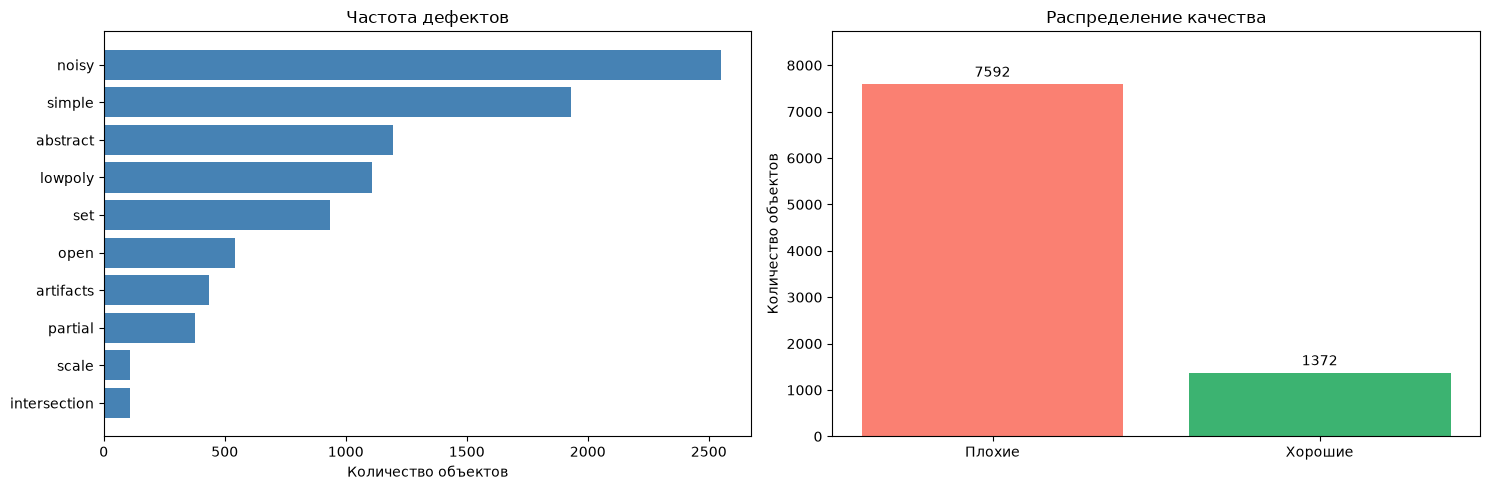

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сортируем для горизонтальной диаграммы:
# самый частый дефект окажется сверху.
plot_stats = label_stats.sort_values("Количество")

axes[0].barh(
    plot_stats.index,
    plot_stats["Количество"],
    color="steelblue",
)

axes[0].set_title("Частота дефектов")
axes[0].set_xlabel("Количество объектов")

quality_counts = (
    train_df[QUALITY_COLUMN]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

bars = axes[1].bar(
    ["Плохие", "Хорошие"],
    quality_counts.to_numpy(),
    color=["salmon", "mediumseagreen"],
)

axes[1].bar_label(bars, padding=3)
axes[1].set_title("Распределение качества")
axes[1].set_ylabel("Количество объектов")
axes[1].margins(y=0.15)

plt.tight_layout()
plt.show()

есть сильный дисбаланс классов объектов

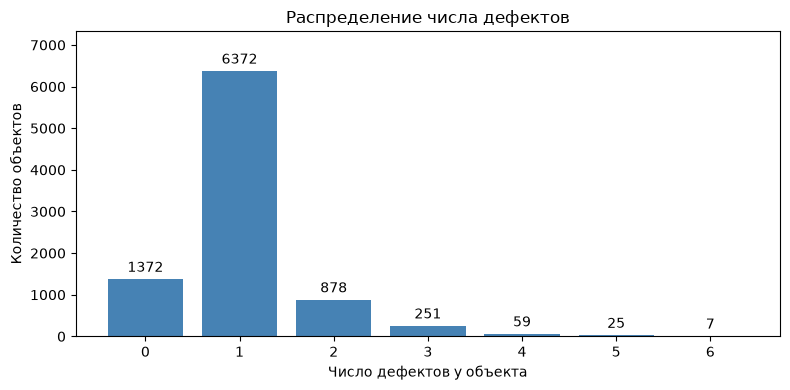


Среднее число дефектов: 1.04
Максимальное число дефектов: 6
Объектов с несколькими дефектами: 1220



In [10]:
count_distribution = (
    defect_count.value_counts().sort_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    count_distribution.index,
    count_distribution.values,
    color="steelblue",
)

ax.bar_label(bars, padding=3)
ax.set_xticks(count_distribution.index)
ax.set_xlabel("Число дефектов у объекта")
ax.set_ylabel("Количество объектов")
ax.set_title("Распределение числа дефектов")
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

print(f'''
Среднее число дефектов: {defect_count.mean():.2f}
Максимальное число дефектов: {defect_count.max()}
Объектов с несколькими дефектами: {(defect_count > 1).sum()}
''')

нужны отдельные бинарные выходы модели для дефектов т.к у некторых объектов их может быть несколько


Группа: Хороший объект
item_id: 532de29e-89a2-473e-ac82-2f2c868676f9
quality: 1
Дефекты по разметке: нет
Размер массива изображения: (1024, 1536, 3)



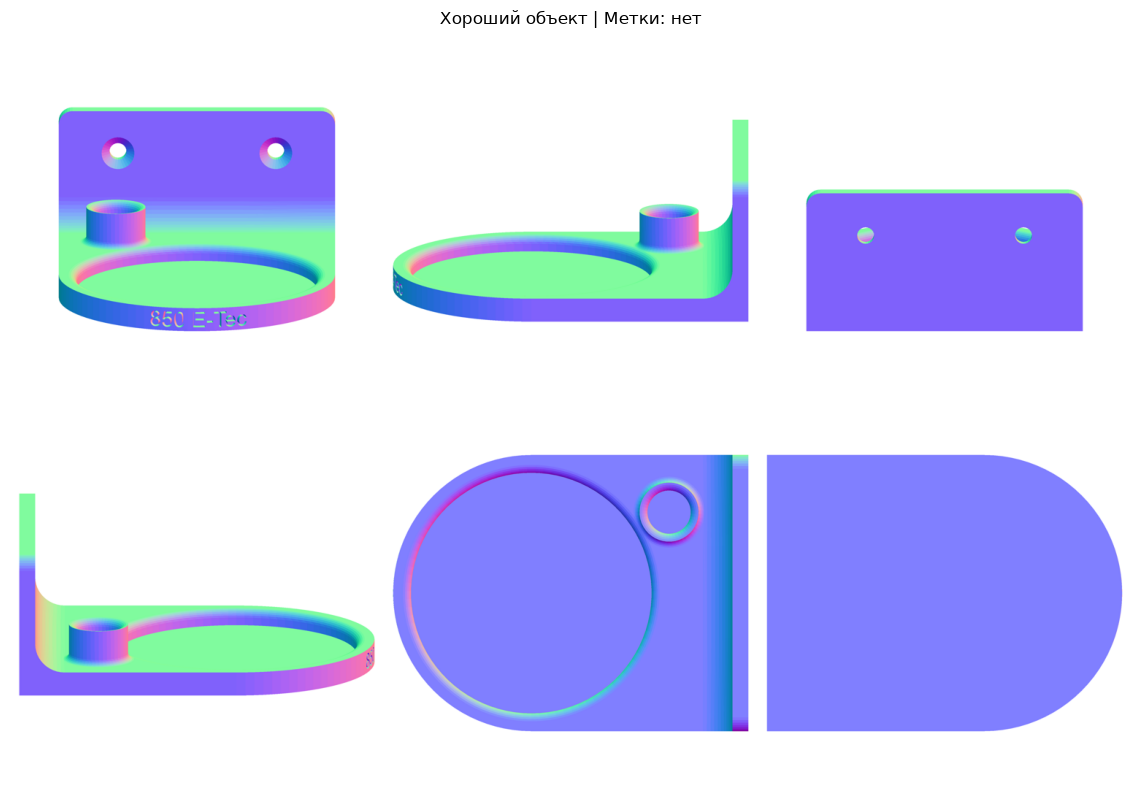


Группа: Объект с noisy
item_id: 06ae3eef-f187-43d1-bcd0-650f1247ef6e
quality: 0
Дефекты по разметке: noisy
Размер массива изображения: (1024, 1536, 3)



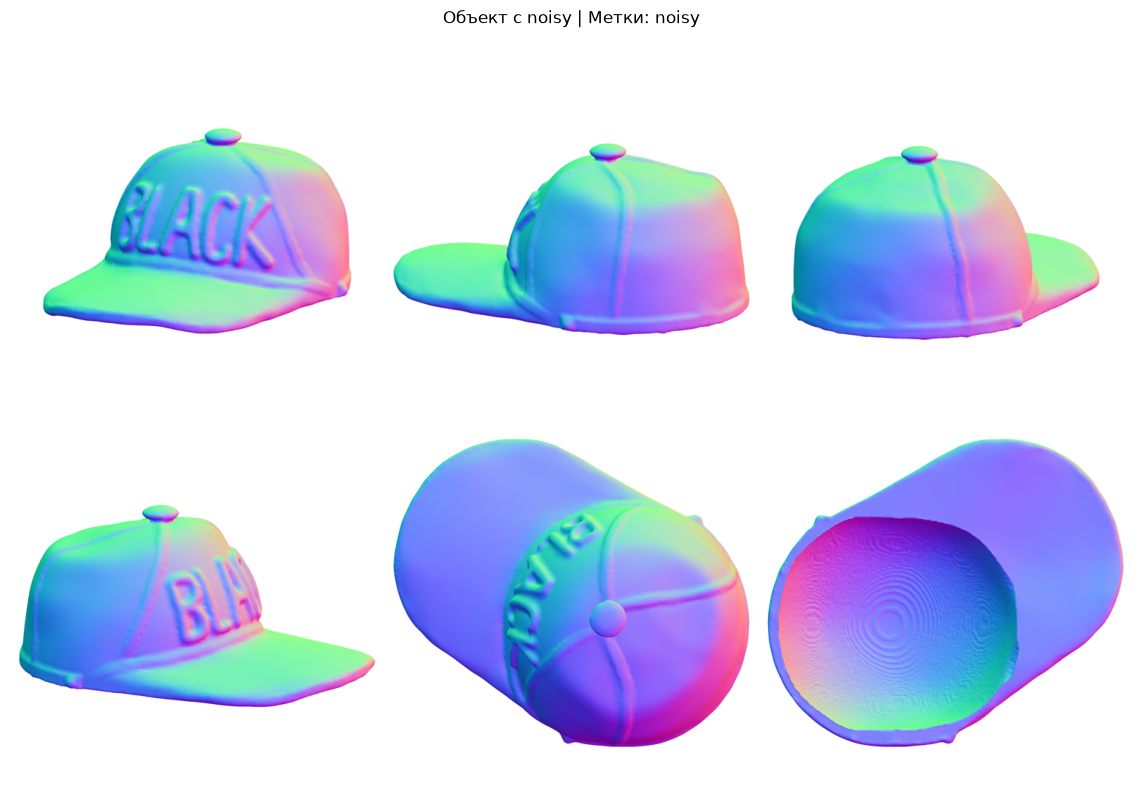


Группа: Объект с simple
item_id: 91c7d961-ea67-4c13-8105-4309c0c3ee72
quality: 0
Дефекты по разметке: simple
Размер массива изображения: (1024, 1536, 3)



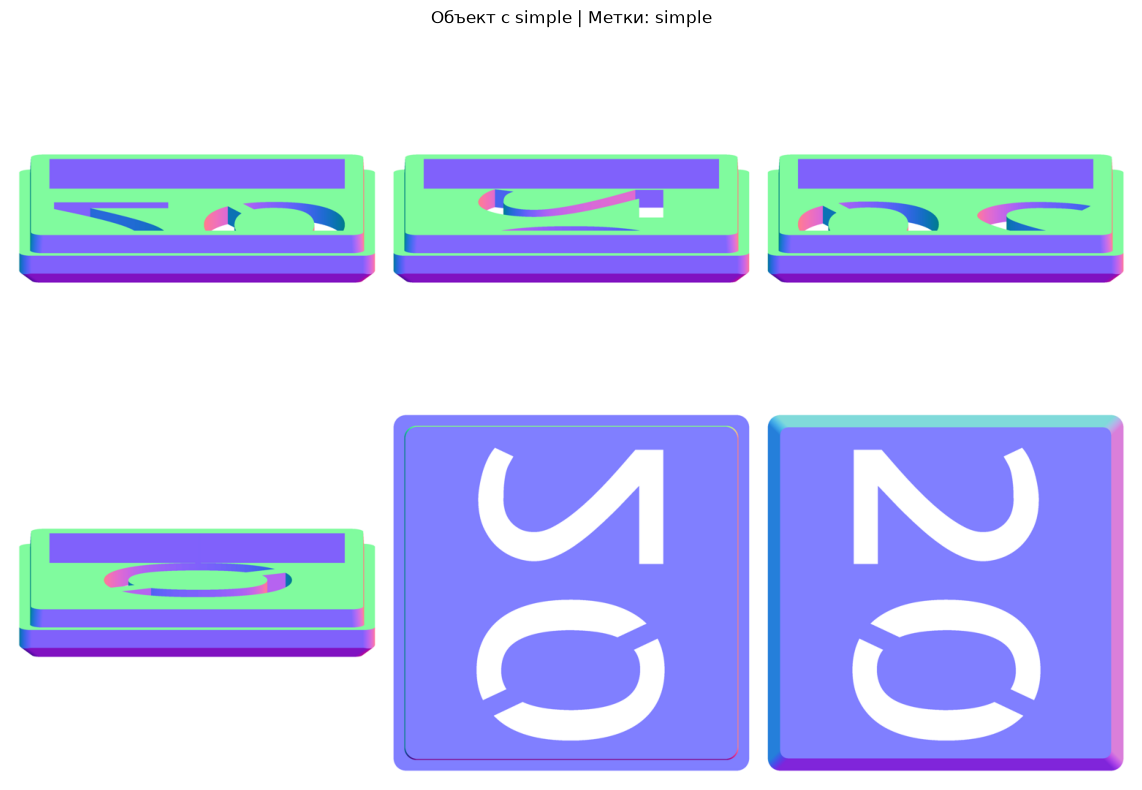

In [11]:
# Для каждого примера задаём условие отбора строк.
example_groups = [
    ("Хороший объект", train_df[QUALITY_COLUMN] == 1),
    ("Объект с noisy", train_df["noisy"] == 1),
    ("Объект с simple", train_df["simple"] == 1),
]

for group_name, mask in example_groups:
    # Фиксированный seed позволяет повторно выбрать тот же пример.
    row = train_df.loc[mask].sample(
        n=1,
        random_state=SEED,
    ).iloc[0]

    item_id = row["item_id"]

    present_defects = [
        label
        for label in DEFECT_COLUMNS
        if row[label] == 1
    ]

    defects_text = ", ".join(present_defects) or "нет"

    image_path = TRAIN_DIR / f"{item_id}.png"

    with Image.open(image_path) as image:
        image_array = np.array(image.convert("RGB"))

    print(f'''
Группа: {group_name}
item_id: {item_id}
quality: {row[QUALITY_COLUMN]}
Дефекты по разметке: {defects_text}
Размер массива изображения: {image_array.shape}
''')

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.imshow(image_array)
    ax.set_title(f"{group_name} | Метки: {defects_text}")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

## 5. Разбиение на обучение и валидацию

Поиск дубликатов и похожих объектов. Создание фиксированного разбиения с учётом нескольких меток и групп объектов: все ракурсы и производные одного объекта должны оставаться в одной части.

In [12]:
import hashlib
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

split_df = train_df.copy()

def calculate_file_hash(path):
    with open(path, 'rb') as file:
        return hashlib.file_digest(file, 'sha256').hexdigest()

image_hashes = []

for item_id in tqdm(
    split_df['item_id'],
    desc='Проверка точных дубликатов PNG'
):
    image_path = TRAIN_DIR / f'{item_id}.png'
    image_hashes.append(calculate_file_hash(image_path))

split_df['group_id'] = image_hashes
group_sizes = split_df.groupby('group_id').size()

duplicate_group_count = int(
    (group_sizes > 1).sum()
    )
objects_in_duplicate_groups = int(
    group_sizes[group_sizes > 1].sum()
)

print(f'''
Всего объектов: {len(split_df)}
Уникальных групп: {len(group_sizes)}

Групп с повторяющимися PNG: {duplicate_group_count}
Объектов в этих группах: {objects_in_duplicate_groups}
Максимальный размер группы: {group_sizes.max()}
''')

Проверка точных дубликатов PNG:   0%|          | 0/8964 [00:00<?, ?it/s]


Всего объектов: 8964
Уникальных групп: 8964

Групп с повторяющимися PNG: 0
Объектов в этих группах: 0
Максимальный размер группы: 1



### Создание разбиения

На этапе разработки оставляем `VAL_FOLD = 0`, чтобы сравнивать архитектуры и настройки на одинаковых данных. Это пока одно фиксированное разбиение, а не полная кросс-валидация.

In [13]:
N_FOLDS = 3
VAL_FOLD = 0

group_targets = (
    split_df.groupby('group_id', sort=True)[TARGET_COLUMNS].max()
)

if len(group_targets) < N_FOLDS:
    raise ValueError('Недостаточно групп для выбранного числа фоддов')

splitter = MultilabelStratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

"""
Сам алгоритм разбиения использует метки. 
Вместо входных признаков ему достаточно массива-заглушки.
"""

group_inputs = np.zeros((len(group_targets), 1))
group_labels = group_targets.to_numpy(dtype=np.int64)

group_folds = pd.Series(
    -1,
    index=group_targets.index,
    name="fold",
)

for fold, (_, val_group_indices) in enumerate(
    splitter.split(group_inputs, group_labels)
):
    group_folds.iloc[val_group_indices] = fold

# возвращаем номер фолда группы её объектам
split_df['fold'] = (
    split_df['group_id'].map(group_folds).astype(int)
)

fit_df = (
    split_df.loc[split_df['fold'] != VAL_FOLD].reset_index(drop=True)
)

valid_df = (
    split_df.loc[split_df['fold'] == VAL_FOLD].reset_index(drop=True)
)

print(f'''
Количество фолдов: {N_FOLDS}
Фолд для валидации: {VAL_FOLD}

Обучающих объектов: {len(fit_df)}
Валидационных объектов: {len(valid_df)}
''')


Количество фолдов: 3
Фолд для валидации: 0

Обучающих объектов: 5970
Валидационных объектов: 2994



In [14]:
fit_ids = set(fit_df["item_id"])
valid_ids = set(valid_df["item_id"])

fit_groups = set(fit_df["group_id"])
valid_groups = set(valid_df["group_id"])

assert not fit_df.empty
assert not valid_df.empty

assert not (fit_ids & valid_ids), "Объекты пересекаются."
assert not (fit_groups & valid_groups), "Группы пересекаются."

assert fit_ids | valid_ids == set(train_df["item_id"])
assert split_df["fold"].between(0, N_FOLDS - 1).all()

balance_table = pd.DataFrame({
    "Всего положительных": train_df[TARGET_COLUMNS].sum(),
    "В обучении": fit_df[TARGET_COLUMNS].sum(),
    "В валидации": valid_df[TARGET_COLUMNS].sum(),
    "Обучение, %": fit_df[TARGET_COLUMNS].mean() * 100,
    "Валидация, %": valid_df[TARGET_COLUMNS].mean() * 100,
})

display(balance_table.round(2))

fold_sizes = (
    split_df["fold"]
    .value_counts()
    .sort_index()
    .rename("Количество объектов")
)

display(fold_sizes.to_frame())

print('''
Проверка разбиения завершена:
— каждый объект входит в обучение или валидацию;
— пересечений объектов нет;
— точные копии PNG не разделены между частями.
''')

,Всего положительных,В обучении,В валидации,"Обучение, %","Валидация, %"
abstract,1194,796,398,13.33,13.29
artifacts,435,290,145,4.86,4.84
intersection,107,72,35,1.21,1.17
lowpoly,1107,738,369,12.36,12.32
noisy,2549,1700,849,28.48,28.36
open,544,363,181,6.08,6.05
partial,376,251,125,4.20,4.18
scale,107,72,35,1.21,1.17
set,936,624,312,10.45,10.42
simple,1929,1286,643,21.54,21.48


,Количество объектов
fold,
0,2994
1,2984
2,2986



Проверка разбиения завершена:
— каждый объект входит в обучение или валидацию;
— пересечений объектов нет;
— точные копии PNG не разделены между частями.



#### Сохранение разиения

In [15]:
split_path = OUTPUT_DIR / f"splits_seed_{SEED}.csv"

split_df[
    ["item_id", "group_id", "fold"]
].to_csv(
    split_path,
    index=False,
)

print(f'''
Разбиение сохранено:
{split_path}

Для текущего эксперимента:
fit_df — обучение;
valid_df — валидация.
''')


Разбиение сохранено:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/splits_seed_42.csv

Для текущего эксперимента:
fit_df — обучение;
valid_df — валидация.



## 6. Подготовка изображений

Разделение PNG-коллажа 1536×1024 на шесть ракурсов 512×512. Выберем размер входа и нормализацию, сохраним заполнение кадра для метки `scale`. Проверим допустимость аугментаций для искусственной окраски.

Сначала разделяем коллаж, затем уменьшаем каждый ракурс. Так изображения разных ракурсов не смешиваются при изменении размера.

In [16]:
def split_render_views(image_path):
    # convert("RGB") гарантирует три цветовых канала.
    with Image.open(image_path) as image:
        collage = image.convert("RGB")

    width, height = collage.size

    columns = 3
    rows = 2

    if width % columns != 0 or height % rows != 0:
        raise ValueError(
            f"Размер коллажа {collage.size} не делится на сетку 3 × 2."
        )

    view_width = width // columns
    view_height = height // rows

    if view_width != view_height:
        raise ValueError(
            f"Ожидались квадратные ракурсы, получено: "
            f"{view_width} × {view_height}."
        )

    views = []

    # Порядок: слева направо, сначала верхний ряд, затем нижний.
    for row in range(rows):
        for column in range(columns):
            left = column * view_width
            top = row * view_height

            right = left + view_width
            bottom = top + view_height

            view = collage.crop((left, top, right, bottom))
            views.append(view)

    return views

Выделили ячейки коллажа, сохраняя весь кадр внутри каждой, а затем
пронумировали ракурсы по положению.

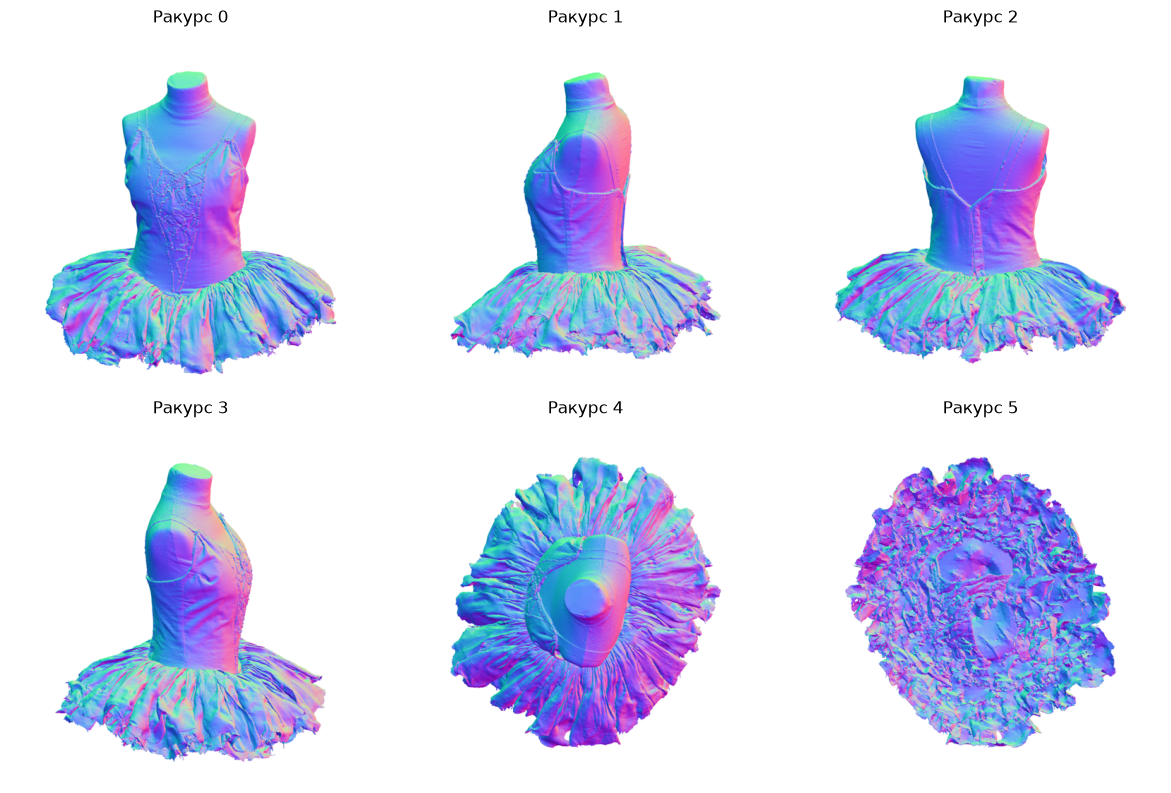


Объект: a08d7f69-b754-4ab9-a2e4-dcaef12a9686
Количество ракурсов: 6
Размер одного ракурса: (512, 512)



In [17]:
example_row = fit_df.sample(
    n=1,
    random_state=SEED,
).iloc[0]

example_id = example_row["item_id"]
example_path = TRAIN_DIR / f"{example_id}.png"

example_views = split_render_views(example_path)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for view_index, (ax, view) in enumerate(
    zip(axes.flat, example_views)
):
    ax.imshow(view)
    ax.set_title(f"Ракурс {view_index}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f'''
Объект: {example_id}
Количество ракурсов: {len(example_views)}
Размер одного ракурса: {example_views[0].size}
''')

### Преобразование

Три операции выполняются последовательно:
1. Resize уменьшает ракурс до выбранного разрешения.
2. ToTensor преобразует изображение в тензор [каналы, высота, ширина], переводя значения пикселей из диапазона 0…255 в 0…1.
3. Normalize преобразует каждый канал по формуле:
$$
x_{\text{normalized}}=\frac{x-\text{mean}}{\text{std}}.
$$

In [18]:
# Стандартная нормализация RGB для выбранного DINOv2.
# При подключении backbone сверим её с конфигурацией весов.
IMAGE_MEAN = (0.485, 0.456, 0.406)
IMAGE_STD = (0.229, 0.224, 0.225)

image_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
        antialias=True
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGE_MEAN,
        std=IMAGE_STD
    )
])

### Собираем ракурсы в тензор

In [19]:
example_tensor = torch.stack([
    image_transform(view) for view in example_views
])

expected_shape = (
    NUM_VIEWS,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert tuple(example_tensor.shape) == expected_shape
assert example_tensor.dtype == torch.float32
assert torch.isfinite(example_tensor).all().item()

print(f'''
Форма тензора: {tuple(example_tensor.shape)}
Тип данных: {example_tensor.dtype}
Устройство хранения: {example_tensor.device}

Минимальное значение: {example_tensor.min().item():.3f}
Максимальное значение: {example_tensor.max().item():.3f}

Подготовка одного объекта выполнена.
''')


Форма тензора: (6, 3, 224, 224)
Тип данных: torch.float32
Устройство хранения: cpu

Минимальное значение: -2.118
Максимальное значение: 2.640

Подготовка одного объекта выполнена.



Шесть отдельных тензоров `[3, 224, 224]` превращаются в один `[6, 3, 224, 224]`

## 7. Dataset и DataLoader

Опишем один элемент датасета: идентификатор, шесть изображений и, для размеченных объектов, целевые метки. Соберём batch и проверим размеры тензоров перед передачей в модель.

Здесь три основных метода:
- `__init__` сохраняет настройки и таблицу. Все изображения в память не загружаются.
- `__len__` возвращает количество объектов.
- `__getitem__` загружает объект по индексу: читает PNG, выделяет ракурсы и преобразует их в тензор.

Метки сразу переводим в `float32`, поскольку для будущей BCEWithLogitsLoss нужны вещественные значения 0.0 и 1.0.

In [20]:
class MeshRenderDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_dir,
        transform,
        target_columns=None,
    ):
        # Собственная копия таблицы с последовательными индексами строк.
        self.dataframe = dataframe.copy().reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

        self.target_columns = (
            list(target_columns)
            if target_columns is not None
            else None
        )

        # Метки небольшие, поэтому сразу преобразуем их в массив.
        if self.target_columns is not None:
            self.targets = self.dataframe[
                self.target_columns
            ].to_numpy(dtype=np.float32, copy=True)
        else:
            self.targets = None

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        item_id = self.dataframe.iloc[index]["item_id"]
        image_path = self.image_dir / f"{item_id}.png"

        views = split_render_views(image_path)

        images = torch.stack([
            self.transform(view)
            for view in views
        ])

        sample = {
            "item_id": item_id,
            "images": images,
        }

        if self.targets is not None:
            sample["targets"] = torch.from_numpy(
                self.targets[index].copy()
            )

        return sample

In [21]:
train_dataset = MeshRenderDataset(
    dataframe=fit_df,
    image_dir=TRAIN_DIR,
    transform=image_transform,
    target_columns=TARGET_COLUMNS,
)

valid_dataset = MeshRenderDataset(
    dataframe=valid_df,
    image_dir=TRAIN_DIR,
    transform=image_transform,
    target_columns=TARGET_COLUMNS,
)

test_dataset = MeshRenderDataset(
    dataframe=test_df,
    image_dir=TEST_DIR,
    transform=image_transform,
    target_columns=None,
)

print(f'''
Объектов для обучения: {len(train_dataset)}
Объектов для валидации: {len(valid_dataset)}
Тестовых объектов: {len(test_dataset)}
''')


Объектов для обучения: 5970
Объектов для валидации: 2994
Тестовых объектов: 669



### Проверка

In [22]:
sample = train_dataset[0]

assert tuple(sample["images"].shape) == (
    NUM_VIEWS,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

assert tuple(sample["targets"].shape) == (NUM_TARGETS,)
assert sample["targets"].dtype == torch.float32

display(pd.DataFrame({
    "Метка": TARGET_COLUMNS,
    "Значение": sample["targets"].numpy(),
}))

print(f'''
item_id: {sample["item_id"]}

Форма изображений: {tuple(sample["images"].shape)}
Форма меток: {tuple(sample["targets"].shape)}

Изображения находятся на: {sample["images"].device}
''')

,Метка,Значение
0,abstract,0.0
1,artifacts,1.0
2,intersection,0.0
3,lowpoly,0.0
4,noisy,0.0
5,open,0.0
6,partial,0.0
7,scale,0.0
8,set,0.0
9,simple,0.0



item_id: 0001be62-bf9c-4c15-8a09-dce209be9715

Форма изображений: (6, 3, 224, 224)
Форма меток: (11,)

Изображения находятся на: cpu



In [23]:
def seed_worker(worker_id):
    # PyTorch назначает каждому worker свой seed.
    # На его основе настраиваем NumPy и random внутри worker.
    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


train_generator = torch.Generator().manual_seed(SEED)

# Закреплённая память полезна для передачи данных на CUDA.
# Для MPS и CPU оставляем её выключенной.
pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED + 1),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED + 2),
)

print(f'''
Batch size: {BATCH_SIZE}
Количество процессов загрузки: {NUM_WORKERS}
Pin memory: {pin_memory}

Обучающих batch: {len(train_loader)}
Валидационных batch: {len(valid_loader)}
Тестовых batch: {len(test_loader)}
''')


Batch size: 4
Количество процессов загрузки: 0
Pin memory: False

Обучающих batch: 1493
Валидационных batch: 749
Тестовых batch: 168



In [24]:
# Используем отдельный загрузчик для проверки.
# Так не изменяем состояние генератора обучающего loader.
preview_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)

batch = next(iter(preview_loader))

images = batch["images"]
targets = batch["targets"]
item_ids = batch["item_id"]

actual_batch_size = len(item_ids)

assert tuple(images.shape) == (
    actual_batch_size,
    NUM_VIEWS,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

assert tuple(targets.shape) == (
    actual_batch_size,
    NUM_TARGETS,
)

assert torch.isfinite(images).all().item()
assert torch.isfinite(targets).all().item()
assert ((targets == 0) | (targets == 1)).all().item()

print(f'''
Объектов в проверочном batch: {actual_batch_size}

Форма изображений: {tuple(images.shape)}
Форма меток: {tuple(targets.shape)}

Тип изображений: {images.dtype}
Тип меток: {targets.dtype}

Первый item_id: {item_ids[0]}

Проверка batch завершена.
''')


Объектов в проверочном batch: 4

Форма изображений: (4, 6, 3, 224, 224)
Форма меток: (4, 11)

Тип изображений: torch.float32
Тип меток: torch.float32

Первый item_id: 0001be62-bf9c-4c15-8a09-dce209be9715

Проверка batch завершена.



## 8. Первая DL-модель по изображениям

Подключим общий для всех ракурсов предобученный DINOv2. Начнём с замороженного encoder, простой агрегации признаков и нейросетевой головы с десятью logits дефектов. Качество вычисляем из бинарных предсказаний дефектов после применения порогов.

In [25]:
MODEL_NAME = "vit_small_patch14_dinov2.lvd142m"

torch.manual_seed(SEED)

backbone = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=0,
    img_size=IMAGE_SIZE
)

# сверка нормализации с конфигурацией выбранных весов
data_config = timm.data.resolve_model_data_config(backbone)

assert np.allclose(IMAGE_MEAN, data_config["mean"])
assert np.allclose(IMAGE_STD, data_config["std"])

print(f'''
Модель: {MODEL_NAME}
Размер входного изображения: {IMAGE_SIZE} × {IMAGE_SIZE}
Количество признаков одного ракурса: {backbone.num_features}

Средние для нормализации: {data_config["mean"]}
Стандартные отклонения: {data_config["std"]}

Предобученный backbone загружен.
''')


Модель: vit_small_patch14_dinov2.lvd142m
Размер входного изображения: 224 × 224
Количество признаков одного ракурса: 384

Средние для нормализации: (0.485, 0.456, 0.406)
Стандартные отклонения: (0.229, 0.224, 0.225)

Предобученный backbone загружен.



`pretrained=True` загружает обученные веса. `num_classes=0` задаёт режим получения признаков без штатного классификатора. Для этой модели один ракурс превращается в вектор из 384 чисел.

### Создание модели

In [26]:
class MultiViewDINOClassifier(nn.Module):
    def __init__(
        self,
        backbone,
        num_defects,
        num_views=6,
        hidden_dim=256,
        dropout=0.2,
        freeze_backbone=True,
    ):
        super().__init__()

        self.backbone = backbone
        self.num_views = num_views
        self.freeze_backbone = freeze_backbone

        feature_dim = self.backbone.num_features

        if self.freeze_backbone:
            for parameter in self.backbone.parameters():
                parameter.requires_grad = False

            self.backbone.eval()

        # После объединения среднего и максимума
        # размерность признаков увеличивается вдвое.
        self.fusion = nn.Sequential(
            nn.LayerNorm(feature_dim * 2),
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.defect_head = nn.Linear(hidden_dim, num_defects)

    def train(self, mode=True):
        super().train(mode)

        # При обучении новых слоёв замороженный backbone
        # продолжает работать в режиме оценки.
        if self.freeze_backbone:
            self.backbone.eval()

        return self

    def forward(self, images):
        if images.ndim != 5:
            raise ValueError(
                "Ожидается тензор [batch, views, channels, height, width]."
            )

        batch_size, num_views, channels, height, width = images.shape

        if num_views != self.num_views:
            raise ValueError(
                f"Ожидалось {self.num_views} ракурсов, получено {num_views}."
            )

        # Backbone принимает обычный batch изображений.
        flat_images = images.reshape(
            batch_size * num_views,
            channels,
            height,
            width,
        )

        view_features = self.backbone(flat_images)

        # Возвращаем группировку ракурсов по объектам.
        view_features = view_features.reshape(
            batch_size,
            num_views,
            -1,
        )

        mean_features = view_features.mean(dim=1)
        max_features = view_features.amax(dim=1)

        object_features = torch.cat(
            [mean_features, max_features],
            dim=1,
        )

        fused_features = self.fusion(object_features)

        defect_logits = self.defect_head(fused_features)

        # Порядок выходов соответствует DEFECT_COLUMNS.
        return defect_logits

In [27]:
model = MultiViewDINOClassifier(
    backbone=backbone,
    num_defects=NUM_DEFECTS,
    num_views=NUM_VIEWS,
    hidden_dim=256,
    dropout=0.2,
    freeze_backbone=True,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f'''
Устройство модели: {DEVICE}

Всего параметров: {total_parameters:,}
Обучаемых параметров: {trainable_parameters:,}
Замороженных параметров: {total_parameters - trainable_parameters:,}

Выходов для дефектов: {NUM_DEFECTS}
Качество вычисляется из предсказаний дефектов.
''')


Устройство модели: mps

Всего параметров: 21,829,770
Обучаемых параметров: 200,970
Замороженных параметров: 21,628,800

Выходов для дефектов: 10
Качество вычисляется из предсказаний дефектов.



### Проверка прямого прохода

In [28]:
preview_batch = next(iter(preview_loader))
preview_images = preview_batch["images"].to(DEVICE)

model.eval()

with torch.no_grad():
    preview_logits = model(preview_images)
    preview_probabilities = torch.sigmoid(preview_logits)

assert tuple(preview_logits.shape) == (
    preview_images.shape[0],
    NUM_OUTPUTS,
)

assert torch.isfinite(preview_logits).all().item()

probability_table = pd.DataFrame(
    preview_probabilities.cpu().numpy(),
    columns=DEFECT_COLUMNS,
    index=preview_batch["item_id"],
)

probability_table.index.name = "item_id"

display(probability_table.round(3))

print(f'''
Форма входа: {tuple(preview_images.shape)}
Форма выхода: {tuple(preview_logits.shape)}
Устройство выхода: {preview_logits.device}

Прямой проход выполнен.
Классифицирующие слои ещё не обучены.
''')

,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple
item_id,,,,,,,,,,
0001be62-bf9c-4c15-8a09-dce209be9715,0.462,0.490,0.496,0.547,0.504,0.418,0.541,0.533,0.450,0.497
000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0.385,0.474,0.405,0.489,0.496,0.445,0.555,0.552,0.459,0.477
0012e069-5caf-44fd-85e4-9a38f6eefd2e,0.420,0.442,0.413,0.494,0.552,0.442,0.581,0.556,0.466,0.493
002b097b-4237-4610-952c-6095d48fb7a0,0.439,0.483,0.458,0.462,0.552,0.439,0.562,0.489,0.467,0.493



Форма входа: (4, 6, 3, 224, 224)
Форма выхода: (4, 10)
Устройство выхода: mps:0

Прямой проход выполнен.
Классифицирующие слои ещё не обучены.



## 9. Функция потерь и конкурсная метрика

Реализуем BCEWithLogits только для дефектов, затем проверим варианты обработки дисбаланса. Метрика: `10 × F1(quality) + 10 × F1(defects, average="weighted")`. Метки дефектов совместимы, поэтому используем sigmoid, а не softmax между классами.

- Loss используется для вычисления градиентов и обновления весов.
- F1 оценивает готовые бинарные предсказания.

Обычный F1 с пороговым преобразованием не подходит для стандартного обучения через backpropagation, поэтому обучать модель будем через BCEWithLogitsLoss.

### Loss function

`BCEWithLogitsLoss` усредняет потери по объектам и десяти дефектам:
$$
L = L_{\text{defects}}.
$$

В `targets` сохраняем все 11 меток, но в loss используем только первые десять.
Истинное качество нужно для конкурсной метрики. Предсказанное качество вычисляем
после применения порогов: `quality=1`, только если все предсказанные дефекты равны нулю.


In [29]:
bce_loss = nn.BCEWithLogitsLoss()

def compute_loss(logits, targets):
    # Модель возвращает десять logits; quality остаётся только в разметке.
    defect_targets = targets[:, :NUM_DEFECTS]
    return bce_loss(logits, defect_targets)


#### Проверка

In [30]:
preview_targets = preview_batch["targets"].to(DEVICE)

with torch.no_grad():
    total_loss = compute_loss(
        preview_logits,
        preview_targets,
    )

assert torch.isfinite(total_loss).item()

print(f'''
Потеря по дефектам: {total_loss.item():.4f}
''')



Потеря по дефектам: 0.6716



### Конкурсные метрики и weighted AP

Weighted AP — критерий выбора эпохи и конфигурации. F1 final — критерий настройки порогов и итоговая конкурсная оценка.


In [31]:
from sklearn.metrics import average_precision_score

SELECTION_METRIC = "weighted_ap"


def calculate_weighted_ap(targets, probabilities):
    targets = np.asarray(targets)
    probabilities = np.asarray(probabilities)
    if targets.ndim != 2 or targets.shape[1] < NUM_DEFECTS:
        raise ValueError("Некорректная форма меток для AP.")
    labels = targets[:, :NUM_DEFECTS]
    if len(labels) == 0 or probabilities.shape != labels.shape:
        raise ValueError("Пустая выборка или несовпадение форм для AP.")
    if not np.isfinite(probabilities).all():
        raise ValueError("Предсказания содержат NaN или бесконечность.")
    if not np.isin(labels, [0, 1]).all():
        raise ValueError("Метки должны быть бинарными.")
    positives = labels.sum(axis=0)
    missing = (positives == 0) | (positives == len(labels))
    if missing.any():
        names = np.asarray(DEFECT_COLUMNS)[missing].tolist()
        raise ValueError(f"В выборке отсутствует одно из значений классов: {names}")
    return float(average_precision_score(labels, probabilities, average="weighted"))


def calculate_metrics(
    targets,
    probabilities,
    thresholds=0.5,
    include_ranking=True,
):
    # Функция принимает массивы NumPy.
    targets = np.asarray(targets)
    probabilities = np.asarray(probabilities)
    thresholds = np.asarray(thresholds)

    if targets.ndim != 2 or targets.shape[1] != NUM_TARGETS:
        raise ValueError(
            f"Ожидаются метки формы [N, {NUM_TARGETS}]."
        )

    if probabilities.shape != (len(targets), NUM_OUTPUTS):
        raise ValueError(
            f"Ожидаются вероятности дефектов формы [N, {NUM_OUTPUTS}]."
        )

    if len(targets) == 0:
        raise ValueError("Нельзя оценить пустую выборку.")

    if not np.isfinite(probabilities).all():
        raise ValueError("Предсказания содержат NaN или бесконечность.")

    # Допускается один порог или отдельный порог на каждый дефект.
    if thresholds.ndim != 0 and thresholds.shape != (NUM_OUTPUTS,):
        raise ValueError(
            f"Нужен один порог или массив из {NUM_OUTPUTS} порогов."
        )

    defect_predictions = (
        probabilities >= thresholds
    ).astype(np.int64)

    # Хороший объект: ни один дефект не достиг своего порога.
    quality_predictions = (~defect_predictions.any(axis=1)).astype(np.int64)

    quality_f1 = f1_score(
        targets[:, NUM_DEFECTS],
        quality_predictions,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    defects_f1 = f1_score(
        targets[:, :NUM_DEFECTS],
        defect_predictions,
        average="weighted",
        zero_division=0,
    )

    final_f1 = 10 * quality_f1 + 10 * defects_f1

    metrics = {
        "f1_quality": float(quality_f1),
        "f1_defects_weighted": float(defects_f1),
        "f1_final": float(final_f1),
    }
    if include_ranking:
        metrics[SELECTION_METRIC] = calculate_weighted_ap(targets, probabilities)
    return metrics


### Пример

In [32]:
# Десять объектов: у каждого свой единственный дефект.
# Одиннадцатый объект хороший.
perfect_targets = np.zeros(
    (NUM_TARGETS, NUM_TARGETS),
    dtype=np.int64,
)

for defect_index in range(NUM_DEFECTS):
    perfect_targets[defect_index, defect_index] = 1

perfect_targets[-1, NUM_DEFECTS] = 1

# Правильной метке назначаем 0.9, отрицательной — 0.1.
perfect_probabilities = np.where(
    perfect_targets[:, :NUM_DEFECTS] == 1,
    0.9,
    0.1,
)

perfect_metrics = calculate_metrics(
    perfect_targets,
    perfect_probabilities,
)

assert np.isclose(perfect_metrics["f1_final"], 20.0)

print(f'''
Проверка на идеальных предсказаниях:

F1 качества: {perfect_metrics["f1_quality"]:.4f}
Взвешенный F1 дефектов: {perfect_metrics["f1_defects_weighted"]:.4f}
Итоговая метрика: {perfect_metrics["f1_final"]:.4f}

Ожидаемый итог: 20.0
''')


Проверка на идеальных предсказаниях:

F1 качества: 1.0000
Взвешенный F1 дефектов: 1.0000
Итоговая метрика: 20.0000

Ожидаемый итог: 20.0



## 10. Цикл обучения и сохранение модели

Напишем шаги обучения и валидации, настроим AdamW, накопление градиентов и логирование. Проверим обучение на небольшом подмножестве, затем запустим полный эксперимент. Сохраним лучшие веса и при необходимости дообучим последние блоки encoder.

In [33]:
from datetime import datetime
from time import perf_counter

NUM_EPOCHS = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2
ACCUMULATION_STEPS = 4

THRESHOLDS = np.full(NUM_DEFECTS, 0.5, dtype=np.float32) # пока ставим одинаковый порог для всех дефектов

# каждый запуск сохраняем отдельно
RUN_NAME = datetime.now().strftime("dinov2_weighted_ap_%Y%m%d_%H%M%S")
RUN_DIR = CHECKPOINT_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=False)

BEST_MODEL_PATH = RUN_DIR / "best_model.pt"
HISTORY_PATH = RUN_DIR / "history.csv"

optimizer = torch.optim.AdamW(
    [
        parameter for parameter in model.parameters() if parameter.requires_grad
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f'''
Эпох: {NUM_EPOCHS}
Learning rate: {LEARNING_RATE}
Weight decay: {WEIGHT_DECAY}

Batch size: {BATCH_SIZE}
Шагов накопления градиентов: {ACCUMULATION_STEPS}
Полный эффективный batch: {BATCH_SIZE * ACCUMULATION_STEPS} объектов

Папка эксперимента: {RUN_DIR}
''')


Эпох: 3
Learning rate: 0.001
Weight decay: 0.01

Batch size: 4
Шагов накопления градиентов: 4
Полный эффективный batch: 16 объектов

Папка эксперимента: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030



**Накопление градиентов** позволяет обновлять веса после нескольких маленьких batch. При наших настройках обрабатываем по четыре объекта, а обновляем веса после 16 объектов. Промежуточные вычисления всех 16 объектов одновременно хранить не нужно.

### Эпоха обучения

Здесь последовательность такая:
1. model(images) получает logits десяти дефектов.
2. compute_loss сравнивает их с разметкой.
3. backward() вычисляет и накапливает градиенты.
4. Перед обновлением усредняем градиенты и ограничиваем их общую норму.
5. optimizer.step() обновляет веса, затем очищаем градиенты.

Переопределённый метод model.train() оставляет замороженный DINOv2 в режиме eval(), но включает обучающий режим для новых слоёв, включая Dropout.

In [34]:
def train_one_epoch(
        model,
        loader,
        optimizer,
        device,
        accumulation_steps=4
):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    loss_sum = 0.0
    object_count = 0
    window_count = 0

    for step, batch in enumerate(
        tqdm(loader, desc='Обучение'),
        start=1
    ):
        images = batch['images'].to(device)
        targets = batch['targets'].to(device)

        batch_size = images.shape[0]

        logits = model(images)
        loss = compute_loss(logits, targets)

        if not torch.isfinite(loss).item():
            raise ValueError(
                'Loss обратился в NaN или бесконечность'
            )

        # накапливает градиенты
        (loss * batch_size).backward()

        window_count += batch_size
        loss_sum += loss.detach().item() * batch_size
        object_count += batch_size

        should_update = (
            step % accumulation_steps == 0 or step == len(loader)
        )

        if should_update:
            '''
            Усредняем по фактическом числу объектов
            (последняя группа batch может быть неполнй)
            '''

            for parameter in model.parameters():
                if parameter.grad is not None:
                    parameter.grad.div_(window_count)

            torch.nn.utils.clip_grad_norm_(
                [
                    parameter for parameter in model.parameters() if parameter.requires_grad
                ],
                max_norm=1.0,
                error_if_nonfinite=True
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            window_count = 0
    return loss_sum / object_count

### Эпоха валидации

In [35]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device,
    thresholds=0.5,
):
    model.eval()

    loss_sum = 0.0
    object_count = 0

    all_targets = []
    all_probabilities = []

    for batch in tqdm(loader, desc="Валидация"):
        images = batch["images"].to(device)
        targets = batch["targets"].to(device)

        logits = model(images)
        loss = compute_loss(logits, targets)

        if not torch.isfinite(loss).item():
            raise ValueError(
                "Validation loss стал NaN или бесконечностью."
            )

        batch_size = images.shape[0]

        loss_sum += loss.item() * batch_size
        object_count += batch_size

        all_targets.append(
            targets.cpu().numpy()
        )

        all_probabilities.append(
            torch.sigmoid(logits).cpu().numpy()
        )

    targets = np.concatenate(
        all_targets,
        axis=0,
    )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0,
    )

    metrics = calculate_metrics(
        targets,
        probabilities,
        thresholds,
    )

    return loss_sum / object_count, metrics

F1 считаем один раз по всей валидационной выборке. Усреднение F1 отдельных batch даст другую величину.

### Запуск обучения

In [36]:
history = []
best_score = -float("inf")
best_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    started_at = perf_counter()

    print(f'''Эпоха {epoch}/{NUM_EPOCHS}''')

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        accumulation_steps=ACCUMULATION_STEPS,
    )

    valid_loss, valid_metrics = validate_one_epoch(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        thresholds=THRESHOLDS,
    )

    elapsed_seconds = perf_counter() - started_at

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        **valid_metrics,
        "seconds": elapsed_seconds,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    history.append(epoch_result)

    # Сохраняем журнал после каждой эпохи.
    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False,
    )

    current_score = valid_metrics[SELECTION_METRIC]
    is_best = current_score > best_score

    if is_best:
        best_score = current_score
        best_epoch = epoch

        # CPU-тензоры удобно загружать на другом устройстве.
        cpu_state_dict = {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        }

        torch.save(
            {
                "model_state_dict": cpu_state_dict,
                "epoch": epoch,
                "metrics": valid_metrics,
                "config": {
                    "selection_metric": SELECTION_METRIC,
                    "model_name": MODEL_NAME,
                    "image_size": IMAGE_SIZE,
                    "image_mean": list(IMAGE_MEAN),
                    "image_std": list(IMAGE_STD),
                    "num_views": NUM_VIEWS,
                    "num_defects": NUM_DEFECTS,
                    "hidden_dim": 256,
                    "dropout": 0.2,
                    "freeze_backbone": True,
                    "defect_columns": list(DEFECT_COLUMNS),
                    "target_columns": list(TARGET_COLUMNS),
                    "thresholds": THRESHOLDS.tolist(),
                    "seed": SEED,
                    "val_fold": VAL_FOLD,
                    "n_folds": N_FOLDS,
                    "batch_size": BATCH_SIZE,
                    "accumulation_steps": ACCUMULATION_STEPS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                },
            },
            BEST_MODEL_PATH,
        )

    checkpoint_text = (
        "Сохранена новая лучшая модель."
        if is_best
        else "Лучшая модель остаётся прежней."
    )

    print(f'''
Train loss: {train_loss:.4f}
Valid loss: {valid_loss:.4f}

F1 качества: {valid_metrics["f1_quality"]:.4f}
Взвешенный F1 дефектов: {valid_metrics["f1_defects_weighted"]:.4f}
Конкурсная метрика: {valid_metrics["f1_final"]:.4f}
Weighted AP: {current_score:.6f}

Время обучения и валидации: {elapsed_seconds / 60:.2f} мин
{checkpoint_text}
''')

history_df = pd.DataFrame(history)
display(history_df)

print(f'''
Обучение завершено.

Лучшая эпоха: {best_epoch}
Лучший weighted AP: {best_score:.4f}

Веса: {BEST_MODEL_PATH}
Журнал: {HISTORY_PATH}
''')

Эпоха 1/3


Обучение:   0%|          | 0/1493 [00:00<?, ?it/s]

Валидация:   0%|          | 0/749 [00:00<?, ?it/s]


Train loss: 0.2100
Valid loss: 0.1864

F1 качества: 0.4829
Взвешенный F1 дефектов: 0.5554
Конкурсная метрика: 10.3823
Weighted AP: 0.652384

Время обучения и валидации: 4.77 мин
Сохранена новая лучшая модель.

Эпоха 2/3


Обучение:   0%|          | 0/1493 [00:00<?, ?it/s]

...

Обучение:   0%|          | 0/1493 [00:00<?, ?it/s]

Валидация:   0%|          | 0/749 [00:00<?, ?it/s]


Train loss: 0.1693
Valid loss: 0.1769

F1 качества: 0.4904
Взвешенный F1 дефектов: 0.5948
Конкурсная метрика: 10.8518
Weighted AP: 0.681777

Время обучения и валидации: 4.72 мин
Сохранена новая лучшая модель.



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,weighted_ap,seconds,learning_rate
0,1,0.209966,0.186410,0.482855,0.555379,10.382337,0.652384,286.028446,0.001
1,2,0.178764,0.183158,0.442222,0.531544,9.737663,0.669447,281.338346,0.001
2,3,0.169325,0.176925,0.490399,0.594786,10.851843,0.681777,283.312688,0.001



Обучение завершено.

Лучшая эпоха: 3
Лучший weighted AP: 0.6818

Веса: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/best_model.pt
Журнал: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/history.csv



### Проверка качества модели

#### Загружаем лучшие веса

In [37]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location='cpu',
    weights_only=True
)

saved_config = checkpoint['config']

# Проверяем порядок классов и выбранную валидационную часть.
assert saved_config["defect_columns"] == DEFECT_COLUMNS
assert saved_config["target_columns"] == TARGET_COLUMNS
assert saved_config["val_fold"] == VAL_FOLD
assert saved_config["seed"] == SEED
assert saved_config["image_size"] == IMAGE_SIZE
assert saved_config["num_views"] == NUM_VIEWS

model.load_state_dict(
    checkpoint['model_state_dict'],
    strict=True
)

model.to(DEVICE)
model.eval()

evaluation_thresholds = np.asarray(
    saved_config["thresholds"],
    dtype=np.float32
)

print(f'''
Загружена модель: {BEST_MODEL_PATH}
Лучшая эпоха: {checkpoint["epoch"]}
Сохранённая метрика: {checkpoint["metrics"]["f1_final"]:.6f}

Пороги дефектов:
{evaluation_thresholds}
''')


Загружена модель: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/best_model.pt
Лучшая эпоха: 3
Сохранённая метрика: 10.851843

Пороги дефектов:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]



#### Вероятности с валидации

In [38]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_item_ids = []
    all_targets = []
    all_probabilities = []

    for batch in tqdm(loader, desc="Сбор предсказаний"):
        images = batch["images"].to(device)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        if not torch.isfinite(probabilities).all().item():
            raise ValueError(
                "Вероятности содержат NaN или бесконечность."
            )

        all_item_ids.extend(batch["item_id"])
        all_targets.append(batch["targets"].cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    return (
        all_item_ids,
        np.concatenate(all_targets, axis=0),
        np.concatenate(all_probabilities, axis=0),
    )


valid_item_ids, valid_targets, valid_probabilities = (
    collect_predictions(
        model=model,
        loader=valid_loader,
        device=DEVICE,
    )
)

assert valid_targets.shape == (len(valid_item_ids), NUM_TARGETS)
assert valid_probabilities.shape == (len(valid_item_ids), NUM_DEFECTS)

evaluation_metrics = calculate_metrics(
    valid_targets,
    valid_probabilities,
    thresholds=evaluation_thresholds,
)

saved_score = checkpoint["metrics"]["f1_final"]
recomputed_score = evaluation_metrics["f1_final"]

print(f'''
Объектов на валидации: {len(valid_item_ids)}

Форма истинных меток: {valid_targets.shape}
Форма вероятностей: {valid_probabilities.shape}

F1 качества: {evaluation_metrics["f1_quality"]:.6f}
Взвешенный F1 дефектов: {evaluation_metrics["f1_defects_weighted"]:.6f}
Итоговая метрика: {recomputed_score:.6f}

Разница с сохранённой метрикой: {recomputed_score - saved_score:+.8f}
''')

Сбор предсказаний:   0%|          | 0/749 [00:00<?, ?it/s]


Объектов на валидации: 2994

Форма истинных меток: (2994, 11)
Форма вероятностей: (2994, 10)

F1 качества: 0.490399
Взвешенный F1 дефектов: 0.594786
Итоговая метрика: 10.851843

Разница с сохранённой метрикой: +0.00000000



### Метрики дефектов

In [39]:
from sklearn.metrics import precision_recall_fscore_support

true_defects = valid_targets[:, :NUM_DEFECTS].astype(np.int64)

predicted_defects = (valid_probabilities >= evaluation_thresholds).astype(np.int64)

precision, recall, class_f1, support = (
    precision_recall_fscore_support(
        true_defects,
        predicted_defects,
        average=None,
        zero_division=0,
    )
)

true_positive = ((true_defects == 1) & (predicted_defects == 1)).sum(axis=0)
false_positive = ((true_defects == 0) & (predicted_defects == 1)).sum(axis=0)
false_negative = ((true_defects == 1) & (predicted_defects == 0)).sum(axis=0)

defect_report = pd.DataFrame(
    {
        "precision": precision,
        "recall": recall,
        "f1": class_f1,
        "actual_positive": support.astype(np.int64),
        "predicted_positive": predicted_defects.sum(axis=0),
        "TP": true_positive,
        "FP": false_positive,
        "FN": false_negative,
        "threshold": evaluation_thresholds,
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
).sort_values("f1")

display(defect_report.round(3))

defect_report.to_csv(BEST_MODEL_PATH.parent / "validation_defect_report.csv")

print(f'''
Средний F1 по классам без весов: {class_f1.mean():.4f}
Взвешенный F1: {evaluation_metrics["f1_defects_weighted"]:.4f}

Отчёт сохранён в папке эксперимента.
''')

,precision,recall,f1,actual_positive,predicted_positive,TP,FP,FN,threshold
defect,,,,,,,,,
intersection,0.000,0.000,0.000,35,0,0,0,35,0.5
scale,0.000,0.000,0.000,35,0,0,0,35,0.5
artifacts,0.333,0.007,0.014,145,3,1,2,144,0.5
open,0.750,0.017,0.032,181,4,3,1,178,0.5
partial,0.618,0.440,0.514,125,89,55,34,70,0.5
lowpoly,0.580,0.493,0.533,369,314,182,132,187,0.5
set,0.706,0.455,0.554,312,201,142,59,170,0.5
simple,0.759,0.602,0.671,643,510,387,123,256,0.5
abstract,0.788,0.643,0.708,398,325,256,69,142,0.5



Средний F1 по классам без весов: 0.3832
Взвешенный F1: 0.5948

Отчёт сохранён в папке эксперимента.



#### Визуализация

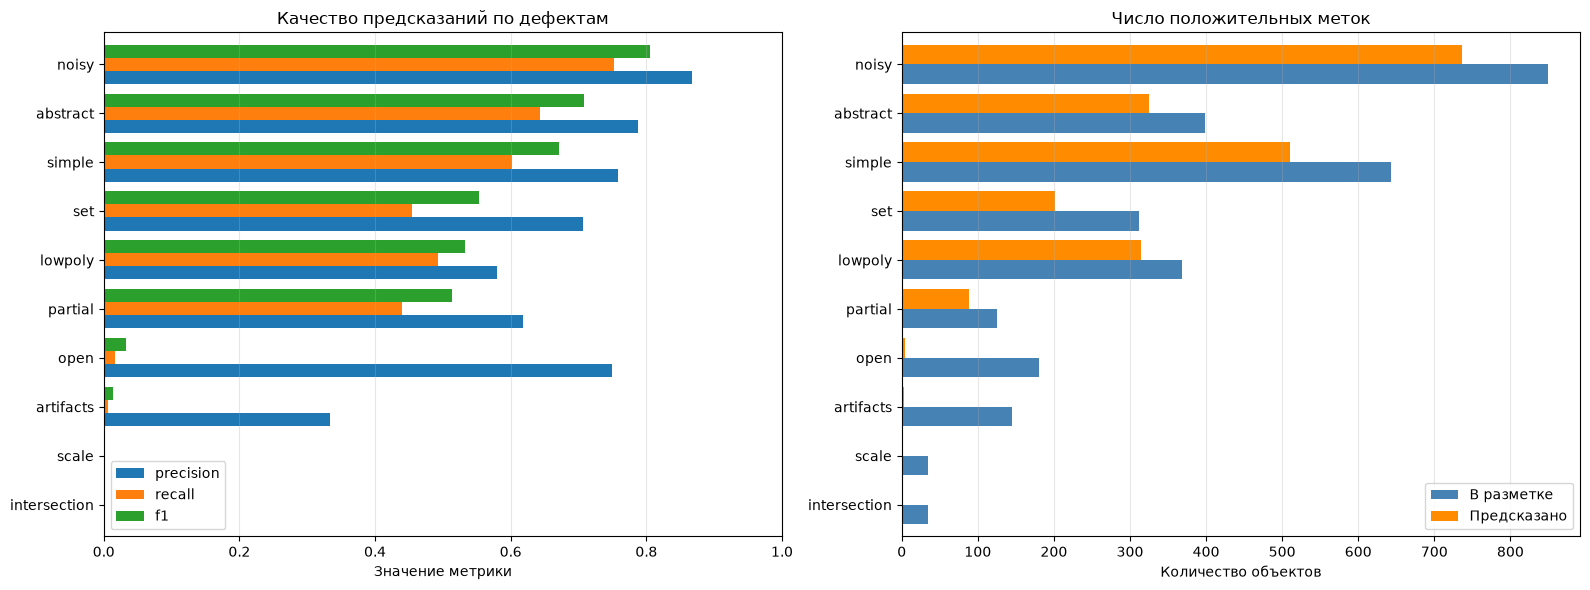

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

defect_report[["precision", "recall", "f1"]].plot.barh(
    ax=axes[0],
    width=0.8,
)

axes[0].set_title("Качество предсказаний по дефектам")
axes[0].set_xlabel("Значение метрики")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

defect_report[["actual_positive", "predicted_positive"]].plot.barh(
    ax=axes[1],
    width=0.8,
    color=["steelblue", "darkorange"],
)

axes[1].set_title("Число положительных меток")
axes[1].set_xlabel("Количество объектов")
axes[1].set_ylabel("")
axes[1].legend(["В разметке", "Предсказано"])
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#### Матрица ошибок качества

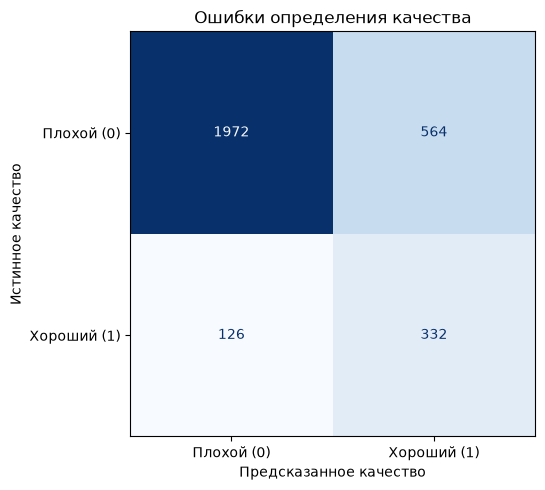


Правильно отклонено плохих объектов: 1972
Ошибочно принято плохих объектов: 564

Ошибочно отклонено хороших объектов: 126
Правильно принято хороших объектов: 332



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true_quality = valid_targets[:, NUM_DEFECTS].astype(np.int64)

predicted_quality = (
    ~predicted_defects.any(axis=1)
).astype(np.int64)

quality_matrix = confusion_matrix(
    true_quality,
    predicted_quality,
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=quality_matrix,
    display_labels=["Плохой (0)", "Хороший (1)"],
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title("Ошибки определения качества")
ax.set_xlabel("Предсказанное качество")
ax.set_ylabel("Истинное качество")

plt.tight_layout()
plt.show()

bad_as_bad, bad_as_good, good_as_bad, good_as_good = (
    quality_matrix.ravel()
)

print(f'''
Правильно отклонено плохих объектов: {bad_as_bad}
Ошибочно принято плохих объектов: {bad_as_good}

Ошибочно отклонено хороших объектов: {good_as_bad}
Правильно принято хороших объектов: {good_as_good}
''')

#### Average Presion для каждого из дефектов

In [42]:
from sklearn.metrics import average_precision_score

true_defects = valid_targets[:, :NUM_DEFECTS].astype(np.int64)

assert true_defects.shape == valid_probabilities.shape
assert np.isfinite(valid_probabilities).all()
assert ((valid_probabilities >= 0) & (valid_probabilities <= 1)).all()

ap_rows = []

for class_index, defect_name in enumerate(DEFECT_COLUMNS):
    labels = true_defects[:, class_index]
    probabilities = valid_probabilities[:, class_index]

    positive_count = int(labels.sum())
    prevalence = float(labels.mean())

    # AP не интерпретируем, если в выборке отсутствует один из классов.
    if 0 < positive_count < len(labels):
        ap = average_precision_score(labels, probabilities)
    else:
        ap = np.nan

    ap_rows.append({
        "defect": defect_name,
        "AP": ap,
        "positive_share": prevalence,
        "AP_minus_share": ap - prevalence,
        "actual_positive": positive_count,
    })

ap_report = (
    pd.DataFrame(ap_rows)
    .set_index("defect")
    .join(defect_report[["precision", "recall", "f1"]])
    .sort_values("AP")
)

display(ap_report.round(3))

ap_report.to_csv(
    BEST_MODEL_PATH.parent / "validation_ap_report.csv",
)

print(f'''
Weighted AP: {calculate_weighted_ap(valid_targets, valid_probabilities):.4f}

AP оценивает ранжирование без фиксированного порога.
F1 в таблице рассчитан при сохранённых порогах модели.
''')

,AP,positive_share,AP_minus_share,actual_positive,precision,recall,f1
defect,,,,,,,
intersection,0.100,0.012,0.089,35,0.000,0.000,0.000
scale,0.114,0.012,0.102,35,0.000,0.000,0.000
open,0.238,0.060,0.177,181,0.750,0.017,0.032
artifacts,0.268,0.048,0.219,145,0.333,0.007,0.014
partial,0.490,0.042,0.449,125,0.618,0.440,0.514
lowpoly,0.581,0.123,0.457,369,0.580,0.493,0.533
set,0.614,0.104,0.510,312,0.706,0.455,0.554
abstract,0.745,0.133,0.612,398,0.788,0.643,0.708
simple,0.771,0.215,0.557,643,0.759,0.602,0.671



Weighted AP: 0.6818

AP оценивает ранжирование без фиксированного порога.
F1 в таблице рассчитан при сохранённых порогах модели.



#### Распределение вероятностей

Для каждого дефекта сравним две группы: объекты, где он присутствует по разметке, и объекты, где отсутствует.

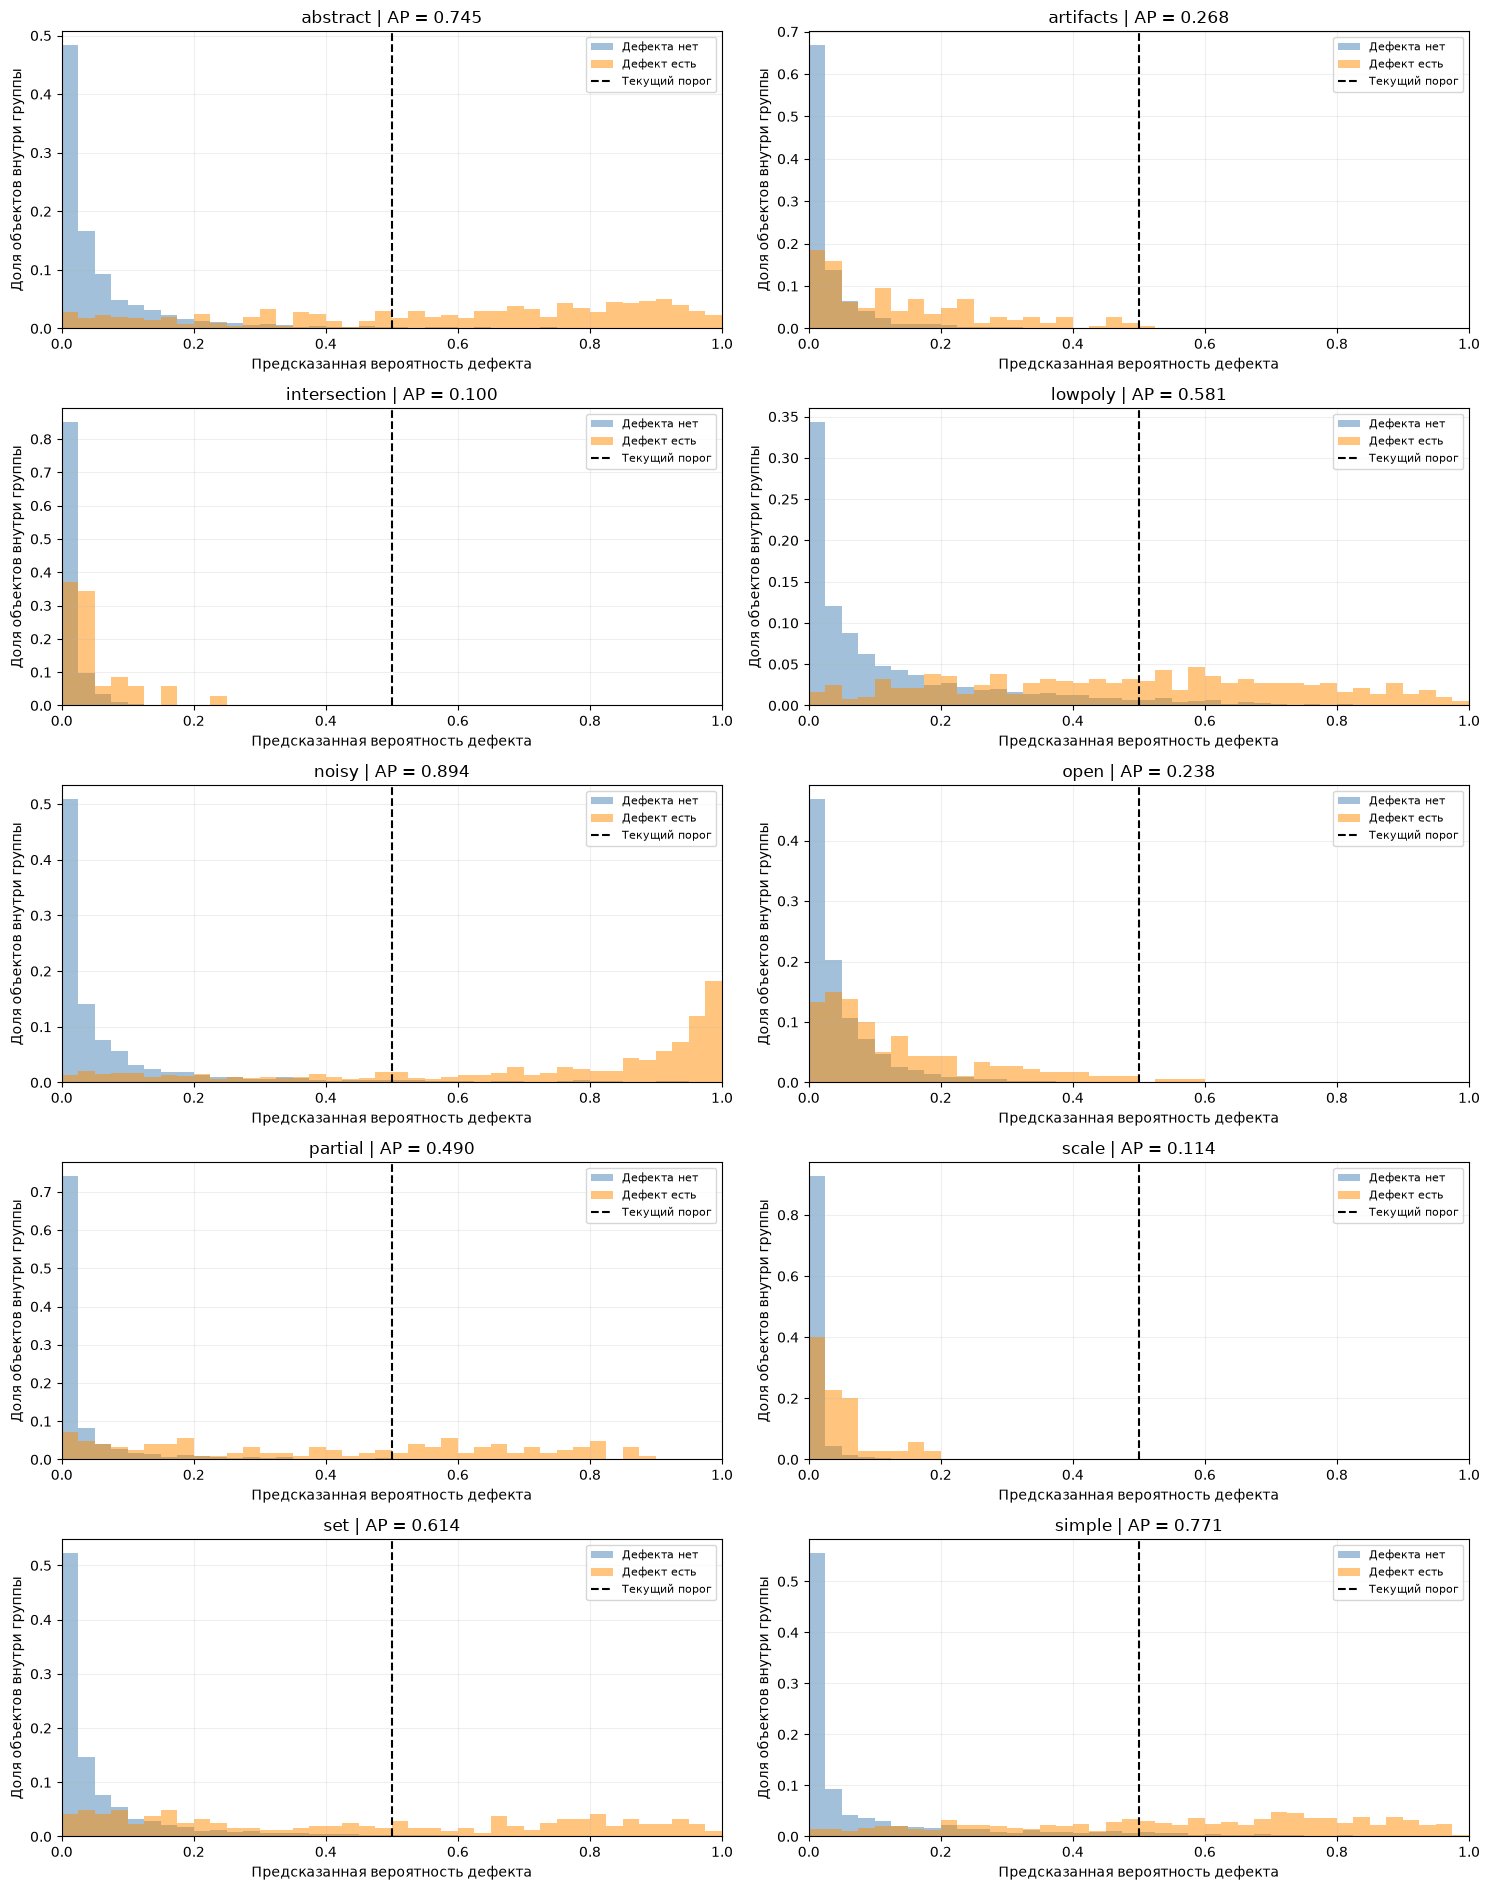

In [43]:
fig, axes = plt.subplots(5, 2, figsize=(15, 19),)

bins = np.linspace(0, 1, 41)

for class_index, ax in enumerate(axes.flat):
    defect_name = DEFECT_COLUMNS[class_index]

    labels = true_defects[:, class_index]
    probabilities = valid_probabilities[:, class_index]

    negative_scores = probabilities[labels == 0]
    positive_scores = probabilities[labels == 1]

    if len(negative_scores):
        ax.hist(
            negative_scores,
            bins=bins,
            weights=np.full(
                len(negative_scores),
                1.0 / len(negative_scores),
            ),
            alpha=0.5,
            color="steelblue",
            label="Дефекта нет",
        )

    if len(positive_scores):
        ax.hist(
            positive_scores,
            bins=bins,
            weights=np.full(
                len(positive_scores),
                1.0 / len(positive_scores),
            ),
            alpha=0.5,
            color="darkorange",
            label="Дефект есть",
        )

    ax.axvline(
        evaluation_thresholds[class_index],
        color="black",
        linestyle="--",
        label="Текущий порог",
    )

    class_ap = ap_report.loc[defect_name, "AP"]

    ax.set_title(f"{defect_name} | AP = {class_ap:.3f}")
    ax.set_xlabel("Предсказанная вероятность дефекта")
    ax.set_ylabel("Доля объектов внутри группы")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [44]:
quantile_rows = []

for class_index, defect_name in enumerate(DEFECT_COLUMNS):
    labels = true_defects[:, class_index]
    probabilities = valid_probabilities[:, class_index]

    for label_value, group_name in [
        (0, "Дефекта нет"),
        (1, "Дефект есть"),
    ]:
        scores = probabilities[labels == label_value]

        if len(scores) == 0:
            continue

        quantile_rows.append({
            "defect": defect_name,
            "group": group_name,
            "count": len(scores),
            "p10": np.quantile(scores, 0.10),
            "median": np.quantile(scores, 0.50),
            "p90": np.quantile(scores, 0.90),
            "max": scores.max(),
        })

probability_report = (
    pd.DataFrame(quantile_rows)
    .set_index(["defect", "group"])
)

display(probability_report.round(4))

count     p10  median     p90     max
defect       group                                             
abstract     Дефекта нет   2596  0.0019  0.0273  0.1981  0.9834
             Дефект есть    398  0.1205  0.6567  0.9209  0.9894
artifacts    Дефекта нет   2849  0.0008  0.0125  0.0885  0.5833
             Дефект есть    145  0.0154  0.1127  0.3465  0.5114
intersection Дефекта нет   2959  0.0004  0.0049  0.0340  0.2701
             Дефект есть     35  0.0138  0.0364  0.1078  0.2311
lowpoly      Дефекта нет   2625  0.0036  0.0598  0.3760  0.8836
             Дефект есть    369  0.1367  0.4985  0.8337  0.9836
noisy        Дефекта нет   2145  0.0026  0.0241  0.2597  0.9903
             Дефект есть    849  0.1605  0.8591  0.9866  0.9995
open         Дефекта нет   2813  0.0033  0.0282  0.1269  0.5336
             Дефект есть    181  0.0204  0.0927  0.3494  0.5758
partial      Дефекта нет   2869  0.0004  0.0054  0.1085  0.8998
             Дефект есть    125  0.0380  0.4093  0.7852  0.8808
scale        Дефекта нет   2959  0.0001  0.0017  0.0194  0.2684
             Дефект есть     35  0.0067  0.0334  0.1200  0.1919
set          Дефекта нет   2682  0.0012  0.0229  0.2013  0.9597
             Дефект есть    312  0.0553  0.4429  0.8843  0.9923
simple       Дефекта нет   2351  0.0005  0.0158  0.3624  0.9527
             Дефект есть    643  0.1551  0.5940  0.8877  0.9802

Модель улавливает сигнал во всех классах, но порог 0.5 почти полностью подавляет предсказания наиболее слабых дефектов. При этом их распознавание пока остаётся слабым — проблема не только в пороге.

### Эксперимент с подбором порогов классификации

Делим валидационную выборку на две части: `calibration` используем для подбора порога, `check` — для проверки выбранного значения

In [45]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Порядок строк должен совпадать с порядком собранных предсказаний.
validation_ids = pd.Index(valid_item_ids, name="item_id")

assert validation_ids.is_unique
assert valid_df["item_id"].is_unique
assert set(validation_ids) == set(valid_df["item_id"])

threshold_df = (valid_df.set_index("item_id").loc[validation_ids].copy())

assert np.array_equal(
    threshold_df[TARGET_COLUMNS].to_numpy(),
    valid_targets,
)

# Стратифицируем группы, а не отдельные объекты.
threshold_group_targets = (threshold_df.groupby("group_id", sort=True)[TARGET_COLUMNS].max())

threshold_splitter = MultilabelStratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=SEED,
)

calibration_group_indices, check_group_indices = next(
    threshold_splitter.split(
        np.zeros((len(threshold_group_targets), 1)),
        threshold_group_targets.to_numpy(),
    )
)

calibration_groups = threshold_group_targets.index[calibration_group_indices]
check_groups = threshold_group_targets.index[check_group_indices]

calibration_mask = threshold_df["group_id"].isin(calibration_groups).to_numpy()

check_mask = threshold_df["group_id"].isin(check_groups).to_numpy()

assert set(calibration_groups).isdisjoint(set(check_groups))
assert not (calibration_mask & check_mask).any()
assert (calibration_mask | check_mask).all()
assert calibration_mask.any() and check_mask.any()

calibration_targets = valid_targets[calibration_mask]
calibration_probabilities = valid_probabilities[calibration_mask]

check_targets = valid_targets[check_mask]
check_probabilities = valid_probabilities[check_mask]

split_report = pd.DataFrame(
    {
        "calibration_positive": calibration_targets.sum(axis=0),
        "check_positive": check_targets.sum(axis=0),
    },
    index=TARGET_COLUMNS,
).astype(int)

display(split_report)

print(f'''
Объектов для настройки: {calibration_mask.sum()}
Объектов для проверки: {check_mask.sum()}

Группы дубликатов между частями не пересекаются.
''')

,calibration_positive,check_positive
abstract,199,199
artifacts,73,72
intersection,17,18
lowpoly,184,185
noisy,425,424
open,90,91
partial,63,62
scale,18,17
set,156,156
simple,321,322



Объектов для настройки: 1496
Объектов для проверки: 1498

Группы дубликатов между частями не пересекаются.



Сделаем покоординатный поиск; оптимизировать F1 каждого дефекта независимо недостаточно т.к пороги совместно определяют `quality`. Поэтому будем менять по одному порогу, выбирая значение с наибольшим полным `f1_final` на calibration

In [46]:
def tune_class_thresholds(
    targets,
    probabilities,
    initial_thresholds,
    max_passes=5,
):
    thresholds = np.asarray(initial_thresholds, dtype=np.float64).copy()

    assert thresholds.shape == (NUM_DEFECTS,)
    assert probabilities.shape == (len(targets), NUM_DEFECTS)

    # Более плотная сетка в области малых вероятностей.
    threshold_grid = np.unique(
        np.concatenate([
            np.geomspace(0.001, 0.1, 25),
            np.arange(1, 100) / 100,
            thresholds,
        ])
    )

    current_metrics = calculate_metrics(
        targets,
        probabilities,
        thresholds=thresholds,
        include_ranking=False,
    )
    current_score = current_metrics["f1_final"]

    search_history = [{
        "pass": 0,
        "defect": "initial",
        "old_threshold": np.nan,
        "new_threshold": np.nan,
        "gain": 0.0,
        **current_metrics,
    }]

    for pass_index in range(1, max_passes + 1):
        improved = False

        for class_index, defect_name in enumerate(
            tqdm(DEFECT_COLUMNS, desc=f"Проход {pass_index}")
        ):
            old_threshold = float(thresholds[class_index])

            best_threshold = old_threshold
            best_score = current_score
            best_metrics = current_metrics

            for candidate in threshold_grid:
                candidate_thresholds = thresholds.copy()
                candidate_thresholds[class_index] = candidate

                candidate_metrics = calculate_metrics(
                    targets,
                    probabilities,
                    thresholds=candidate_thresholds,
                    include_ranking=False,
                )

                candidate_score = candidate_metrics["f1_final"]

                # При равенстве сохраняем прежний вариант.
                if candidate_score > best_score + 1e-12:
                    best_threshold = float(candidate)
                    best_score = candidate_score
                    best_metrics = candidate_metrics

            gain = best_score - current_score

            if gain > 1e-12:
                thresholds[class_index] = best_threshold
                current_score = best_score
                current_metrics = best_metrics
                improved = True

            search_history.append({
                "pass": pass_index,
                "defect": defect_name,
                "old_threshold": old_threshold,
                "new_threshold": float(thresholds[class_index]),
                "gain": gain,
                **current_metrics,
            })

        print(f'''
Проход: {pass_index}
Метрика на calibration: {current_score:.6f}
''')

        if not improved:
            break

    return thresholds, pd.DataFrame(search_history)

In [47]:
initial_thresholds = np.asarray(evaluation_thresholds, dtype=np.float64).copy()

tuned_thresholds, threshold_search_history = (
    tune_class_thresholds(
        targets=calibration_targets,
        probabilities=calibration_probabilities,
        initial_thresholds=initial_thresholds,
        max_passes=5,
    )
)

threshold_table = pd.DataFrame(
    {
        "initial_threshold": initial_thresholds,
        "tuned_threshold": tuned_thresholds,
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

display(threshold_table.round(4))

display(
    threshold_search_history.loc[
        threshold_search_history["gain"] > 0,
        [
            "pass",
            "defect",
            "old_threshold",
            "new_threshold",
            "gain",
            "f1_final",
        ],
    ].round(4)
)

Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 12.783727



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 12.784398



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 3
Метрика на calibration: 12.784398



,initial_threshold,tuned_threshold
defect,,
abstract,0.5,0.2100
artifacts,0.5,0.0800
intersection,0.5,0.0562
lowpoly,0.5,0.5600
noisy,0.5,0.3600
open,0.5,0.1300
partial,0.5,0.2700
scale,0.5,0.0147
set,0.5,0.4200


,pass,defect,old_threshold,new_threshold,gain,f1_final
1,1,abstract,0.5,0.2000,0.4242,11.2816
2,1,artifacts,0.5,0.0800,0.3344,11.6160
3,1,intersection,0.5,0.0562,0.0513,11.6673
4,1,lowpoly,0.5,0.5600,0.1867,11.8540
5,1,noisy,0.5,0.3600,0.1431,11.9971
6,1,open,0.5,0.1300,0.5040,12.5011
7,1,partial,0.5,0.2700,0.0589,12.5600
8,1,scale,0.5,0.0147,0.0341,12.5940
9,1,set,0.5,0.4200,0.1354,12.7295
10,1,simple,0.5,0.4500,0.0543,12.7837


Теперь ипользуем `check` для проверки результатов

In [48]:
comparison_rows = []

for split_name, targets, probabilities in [
    (
        "calibration",
        calibration_targets,
        calibration_probabilities,
    ),
    (
        "check",
        check_targets,
        check_probabilities,
    ),
]:
    for variant, thresholds in [
        ("initial", initial_thresholds),
        ("per_class", tuned_thresholds),
    ]:
        metrics = calculate_metrics(
            targets,
            probabilities,
            thresholds=thresholds,
        )

        comparison_rows.append({
            "split": split_name,
            "variant": variant,
            **metrics,
        })

threshold_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index(["split", "variant"])
)

display(threshold_comparison.round(4))

check_gain = (
    threshold_comparison.loc[("check", "per_class"), "f1_final"]
    - threshold_comparison.loc[("check", "initial"), "f1_final"]
)

print(f'''
Изменение итоговой метрики на check: {check_gain:+.4f}
''')

f1_quality  f1_defects_weighted  f1_final  weighted_ap
split       variant                                                          
calibration initial        0.4814               0.6043   10.8574       0.6879
            per_class      0.6358               0.6427   12.7844       0.6879
check       initial        0.4993               0.5850   10.8431       0.6776
            per_class      0.5660               0.6175   11.8350       0.6776


Изменение итоговой метрики на check: +0.9919



In [49]:
quality_error_rows = []

true_check_quality = check_targets[:, NUM_DEFECTS].astype(int)

for variant, thresholds in [
    ("initial", initial_thresholds),
    ("per_class", tuned_thresholds),
]:
    predicted_defects = check_probabilities >= thresholds
    predicted_quality = (~predicted_defects.any(axis=1)).astype(int)

    quality_error_rows.append({
        "variant": variant,
        "bad_as_bad": int((
            (true_check_quality == 0)
            & (predicted_quality == 0)
        ).sum()),
        "bad_as_good": int((
            (true_check_quality == 0)
            & (predicted_quality == 1)
        ).sum()),
        "good_as_bad": int((
            (true_check_quality == 1)
            & (predicted_quality == 0)
        ).sum()),
        "good_as_good": int((
            (true_check_quality == 1)
            & (predicted_quality == 1)
        ).sum()),
    })

quality_threshold_report = (
    pd.DataFrame(quality_error_rows)
    .set_index("variant")
)

display(quality_threshold_report)

,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
initial,987,282,59,170
per_class,1156,113,94,135


### До-После сравнение

In [50]:
from sklearn.metrics import precision_recall_fscore_support

true_check_defects = check_targets[:, :NUM_DEFECTS].astype(np.int64)

class_comparison_rows = []

for variant, thresholds in [
    ("initial", initial_thresholds),
    ("per_class", tuned_thresholds),
]:
    predictions = (
        check_probabilities >= thresholds
    ).astype(np.int64)

    precision, recall, class_f1, support = (
        precision_recall_fscore_support(
            true_check_defects,
            predictions,
            average=None,
            zero_division=0,
        )
    )

    tp = ((true_check_defects == 1) & (predictions == 1)).sum(axis=0)
    fp = ((true_check_defects == 0) & (predictions == 1)).sum(axis=0)
    fn = ((true_check_defects == 1) & (predictions == 0)).sum(axis=0)

    for class_index, defect_name in enumerate(DEFECT_COLUMNS):
        class_comparison_rows.append({
            "defect": defect_name,
            "variant": variant,
            "threshold": float(thresholds[class_index]),
            "precision": precision[class_index],
            "recall": recall[class_index],
            "f1": class_f1[class_index],
            "support": int(support[class_index]),
            "predicted_positive": int(
                predictions[:, class_index].sum()
            ),
            "TP": int(tp[class_index]),
            "FP": int(fp[class_index]),
            "FN": int(fn[class_index]),
        })

check_class_report = (
    pd.DataFrame(class_comparison_rows)
    .set_index(["defect", "variant"])
)

display(check_class_report.round(4))

,,threshold,precision,recall,f1,support,predicted_positive,TP,FP,FN
defect,variant,,,,,,,,,
abstract,initial,0.5000,0.8012,0.6884,0.7405,199,171,137,34,62
artifacts,initial,0.5000,0.0000,0.0000,0.0000,72,1,0,1,72
intersection,initial,0.5000,0.0000,0.0000,0.0000,18,0,0,0,18
lowpoly,initial,0.5000,0.5779,0.4811,0.5251,185,154,89,65,96
noisy,initial,0.5000,0.8482,0.7382,0.7894,424,369,313,56,111
open,initial,0.5000,0.0000,0.0000,0.0000,91,0,0,0,91
partial,initial,0.5000,0.6667,0.4194,0.5149,62,39,26,13,36
scale,initial,0.5000,0.0000,0.0000,0.0000,17,0,0,0,17
set,initial,0.5000,0.7000,0.4487,0.5469,156,100,70,30,86


In [51]:
before_report = (
    check_class_report
    .xs("initial", level="variant")
    .reindex(DEFECT_COLUMNS)
)

after_report = (
    check_class_report
    .xs("per_class", level="variant")
    .reindex(DEFECT_COLUMNS)
)

class_changes = pd.DataFrame(
    {
        "support": before_report["support"],
        "threshold_before": before_report["threshold"],
        "threshold_after": after_report["threshold"],
        "precision_before": before_report["precision"],
        "precision_after": after_report["precision"],
        "recall_before": before_report["recall"],
        "recall_after": after_report["recall"],
        "f1_before": before_report["f1"],
        "f1_after": after_report["f1"],
        "delta_f1": (
            after_report["f1"] - before_report["f1"]
        ),
        "delta_TP": (
            after_report["TP"] - before_report["TP"]
        ),
        "delta_FP": (
            after_report["FP"] - before_report["FP"]
        ),
        "delta_FN": (
            after_report["FN"] - before_report["FN"]
        ),
    }
)

# Вклад класса в изменение дефектной части конкурсного балла.
class_weights = (
    class_changes["support"]
    / class_changes["support"].sum()
)

class_changes["defect_score_gain"] = (
    10 * class_weights * class_changes["delta_f1"]
)

class_changes = class_changes.sort_values(
    "defect_score_gain",
    ascending=False,
)

display(class_changes.round(4))

,support,threshold_before,threshold_after,precision_before,precision_after,recall_before,recall_after,f1_before,f1_after,delta_f1,delta_TP,delta_FP,delta_FN,defect_score_gain
defect,,,,,,,,,,,,,,
open,91,0.5,0.1300,0.0000,0.2069,0.0000,0.3956,0.0000,0.2717,0.2717,36,138,-36,0.1599
artifacts,72,0.5,0.0800,0.0000,0.2234,0.0000,0.6111,0.0000,0.3271,0.3271,44,152,-44,0.1524
noisy,424,0.5,0.3600,0.8482,0.8033,0.7382,0.8090,0.7894,0.8061,0.0167,30,28,-30,0.0458
simple,322,0.5,0.4500,0.7231,0.6923,0.5839,0.6429,0.6460,0.6667,0.0206,19,20,-19,0.0429
set,156,0.5,0.4200,0.7000,0.6250,0.4487,0.5128,0.5469,0.5634,0.0165,10,18,-10,0.0167
intersection,18,0.5,0.0562,0.0000,0.0667,0.0000,0.2778,0.0000,0.1075,0.1075,5,70,-5,0.0125
scale,17,0.5,0.0147,0.0000,0.0563,0.0000,0.7059,0.0000,0.1043,0.1043,12,201,-12,0.0115
partial,62,0.5,0.2700,0.6667,0.4227,0.4194,0.6613,0.5149,0.5157,0.0009,15,43,-15,0.0003
lowpoly,185,0.5,0.5600,0.5779,0.6316,0.4811,0.3892,0.5251,0.4816,-0.0435,-17,-23,17,-0.0520


In [52]:
initial_check_metrics = calculate_metrics(
    check_targets,
    check_probabilities,
    thresholds=initial_thresholds,
)

tuned_check_metrics = calculate_metrics(
    check_targets,
    check_probabilities,
    thresholds=tuned_thresholds,
)

defect_score_gain = class_changes["defect_score_gain"].sum()

quality_score_gain = 10 * (
    tuned_check_metrics["f1_quality"]
    - initial_check_metrics["f1_quality"]
)

total_score_gain = (
    tuned_check_metrics["f1_final"]
    - initial_check_metrics["f1_final"]
)

assert np.isclose(
    defect_score_gain,
    10 * (
        tuned_check_metrics["f1_defects_weighted"]
        - initial_check_metrics["f1_defects_weighted"]
    ),
)

assert np.isclose(
    total_score_gain,
    defect_score_gain + quality_score_gain,
)

print(f'''
Прирост за счёт F1 дефектов: {defect_score_gain:+.4f}
Прирост за счёт F1 качества: {quality_score_gain:+.4f}

Общий прирост: {total_score_gain:+.4f}
''')


Прирост за счёт F1 дефектов: +0.3242
Прирост за счёт F1 качества: +0.6677

Общий прирост: +0.9919



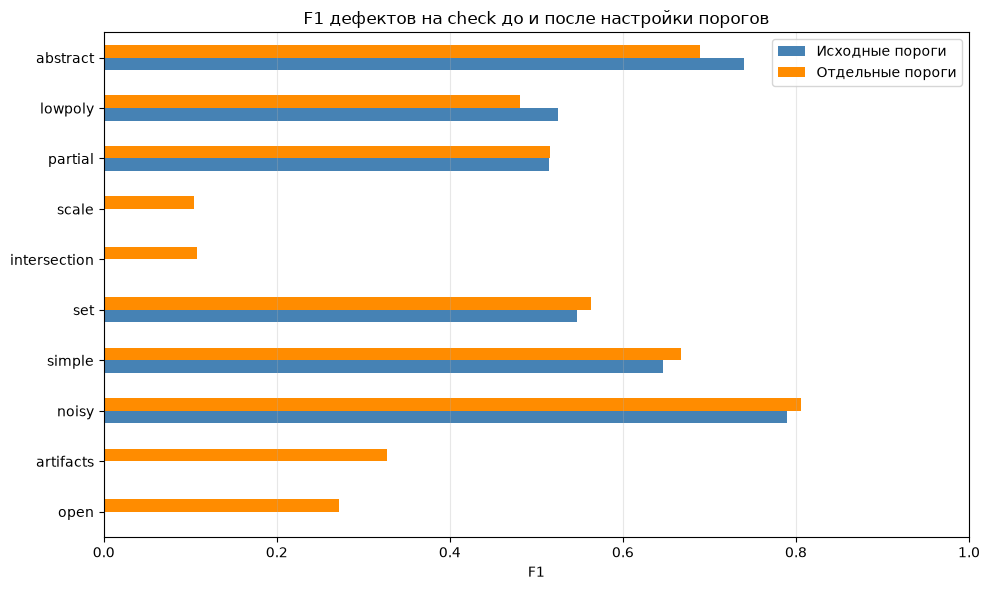


Отчёты сохранены: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/per_class_threshold_analysis



In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

class_changes[["f1_before", "f1_after"]].plot.barh(
    ax=ax,
    color=["steelblue", "darkorange"],
)

ax.set_title("F1 дефектов на check до и после настройки порогов")
ax.set_xlabel("F1")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(["Исходные пороги", "Отдельные пороги"])
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

analysis_dir = (
    BEST_MODEL_PATH.parent / "per_class_threshold_analysis"
)
analysis_dir.mkdir(parents=True, exist_ok=True)

check_class_report.to_csv(
    analysis_dir / "check_class_report.csv",
)

class_changes.to_csv(
    analysis_dir / "check_class_changes.csv",
)

print(f'''
Отчёты сохранены: {analysis_dir}
''')

### Кэширование для оптимизации обучения и подбора парвметров

#### Загрузка лулчших весов и описание кэша

In [54]:
import hashlib

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)

model.to(DEVICE)
model.eval()

assert model.freeze_backbone
assert all(
    not parameter.requires_grad
    for parameter in model.backbone.parameters()
)

saved_config = checkpoint["config"]

assert saved_config["defect_columns"] == DEFECT_COLUMNS
assert saved_config["target_columns"] == TARGET_COLUMNS
assert saved_config["image_size"] == IMAGE_SIZE
assert saved_config["num_views"] == NUM_VIEWS

with open(BEST_MODEL_PATH, "rb") as file:
    checkpoint_hash = hashlib.file_digest(
        file,
        "sha256",
    ).hexdigest()

CACHE_DIR = BEST_MODEL_PATH.parent / "feature_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

cache_metadata = {
    "checkpoint_sha256": checkpoint_hash,
    "model_name": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "num_views": NUM_VIEWS,
    "feature_dim": model.backbone.num_features,
    "transform": repr(image_transform),
    "target_columns": list(TARGET_COLUMNS),
    "seed": SEED,
    "val_fold": VAL_FOLD,
    "dtype": "float32",
    "device": str(DEVICE),
    "torch_version": str(torch.__version__),
    "timm_version": version("timm"),
}

print(f'''
Папка кэша: {CACHE_DIR}
Признаков на ракурс: {model.backbone.num_features}
Ракурсов на объект: {NUM_VIEWS}
Формат сохранения: float32

Backbone заморожен и переведён в eval.
''')


Папка кэша: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/feature_cache
Признаков на ракурс: 384
Ракурсов на объект: 6
Формат сохранения: float32

Backbone заморожен и переведён в eval.



#### Доп загрузчики для работы с хэшем

In [55]:
cache_loaders = {}

for split_name, dataset in [
    ("train", train_dataset),
    ("valid", valid_dataset),
]:
    cache_loaders[split_name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(SEED),
    )

#### Извлечение и сохранение признаков

In [56]:
@torch.no_grad()
def save_feature_cache(
    model,
    loader,
    device,
    path,
    metadata,
):
    model.eval()

    if any(
        parameter.requires_grad
        for parameter in model.backbone.parameters()
    ):
        raise ValueError(
            "Кэш предназначен для замороженного backbone."
        )

    all_features = []
    all_ids = []
    all_targets = []

    for batch in tqdm(loader, desc=f"Кэш: {path.stem}"):
        images = batch["images"].to(device)

        batch_size, num_views, channels, height, width = (
            images.shape
        )

        flat_images = images.reshape(
            batch_size * num_views,
            channels,
            height,
            width,
        )

        features = model.backbone(flat_images)

        features = features.reshape(
            batch_size,
            num_views,
            -1,
        )

        if not torch.isfinite(features).all().item():
            raise ValueError(
                "Признаки содержат NaN или бесконечность."
            )

        all_features.append(
            features.detach().cpu().float()
        )
        all_ids.extend(batch["item_id"])
        all_targets.append(
            batch["targets"].cpu().float()
        )

    payload = {
        "features": torch.cat(all_features, dim=0),
        "item_ids": all_ids,
        "targets": torch.cat(all_targets, dim=0),
        "metadata": metadata,
    }

    assert len(set(all_ids)) == len(all_ids)

    assert payload["features"].shape == (
        len(all_ids),
        metadata["num_views"],
        metadata["feature_dim"],
    )

    assert payload["targets"].shape == (
        len(all_ids),
        len(metadata["target_columns"]),
    )

    torch.save(payload, path)

    return tuple(payload["features"].shape)

In [57]:
for split_name, loader in cache_loaders.items():
    cache_path = CACHE_DIR / f"{split_name}.pt"

    feature_shape = save_feature_cache(
        model=model,
        loader=loader,
        device=DEVICE,
        path=cache_path,
        metadata=cache_metadata,
    )

    file_size_mb = cache_path.stat().st_size / (1024 ** 2)

    print(f'''
Выборка: {split_name}
Форма признаков: {feature_shape}
Размер файла: {file_size_mb:.2f} MiB
Файл: {cache_path}
''')

Кэш: train:   0%|          | 0/1493 [00:00<?, ?it/s]


Выборка: train
Форма признаков: (5970, 6, 384)
Размер файла: 52.98 MiB
Файл: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/feature_cache/train.pt



Кэш: valid:   0%|          | 0/749 [00:00<?, ?it/s]


Выборка: valid
Форма признаков: (2994, 6, 384)
Размер файла: 26.57 MiB
Файл: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/feature_cache/valid.pt



#### Загружаем кэш и проверяем порядок объектов

In [58]:
train_cache = torch.load(
    CACHE_DIR / "train.pt",
    map_location="cpu",
    weights_only=True,
)

valid_cache = torch.load(
    CACHE_DIR / "valid.pt",
    map_location="cpu",
    weights_only=True,
)

for cache, dataset in [
    (train_cache, train_dataset),
    (valid_cache, valid_dataset),
]:
    assert cache["metadata"] == cache_metadata

    assert cache["item_ids"] == (
        dataset.dataframe["item_id"].tolist()
    )

    assert np.array_equal(
        cache["targets"].numpy(),
        dataset.targets,
    )

    assert cache["features"].dtype == torch.float32
    assert torch.isfinite(cache["features"]).all().item()

print(f'''
Обучающий кэш: {tuple(train_cache["features"].shape)}
Валидационный кэш: {tuple(valid_cache["features"].shape)}

Идентификаторы, метки и описание кэша проверены.
''')


Обучающий кэш: (5970, 6, 384)
Валидационный кэш: (2994, 6, 384)

Идентификаторы, метки и описание кэша проверены.



#### Прямой проход из признаков

In [59]:
def logits_from_features(model, features):
    mean_features = features.mean(dim=1)
    max_features = features.amax(dim=1)

    object_features = torch.cat(
        [mean_features, max_features],
        dim=1,
    )

    fused_features = model.fusion(object_features)

    return model.defect_head(fused_features)

In [60]:
model.eval()

direct_probability_batches = []
cached_probability_batches = []

offset = 0
max_logit_difference = 0.0

with torch.no_grad():
    for batch in tqdm(
        cache_loaders["valid"],
        desc="Проверка эквивалентности",
    ):
        batch_size = len(batch["item_id"])
        end = offset + batch_size

        assert batch["item_id"] == (
            valid_cache["item_ids"][offset:end]
        )

        images = batch["images"].to(DEVICE)
        features = valid_cache["features"][offset:end].to(DEVICE)

        direct_logits = model(images)
        cached_logits = logits_from_features(model, features)

        difference = (
            direct_logits - cached_logits
        ).abs().max().item()

        max_logit_difference = max(
            max_logit_difference,
            difference,
        )

        torch.testing.assert_close(
            cached_logits,
            direct_logits,
            rtol=1e-4,
            atol=1e-5,
        )

        direct_probability_batches.append(
            torch.sigmoid(direct_logits).cpu().numpy()
        )

        cached_probability_batches.append(
            torch.sigmoid(cached_logits).cpu().numpy()
        )

        offset = end

assert offset == len(valid_cache["item_ids"])

direct_probabilities = np.concatenate(
    direct_probability_batches,
    axis=0,
)

cached_probabilities = np.concatenate(
    cached_probability_batches,
    axis=0,
)

print(f'''
Максимальное абсолютное отличие logits: {max_logit_difference:.8f}

Logits совпадают в пределах заданного допуска.
''')

Проверка эквивалентности:   0%|          | 0/749 [00:00<?, ?it/s]


Максимальное абсолютное отличие logits: 0.00000000

Logits совпадают в пределах заданного допуска.



#### Проверка предсказаний и конкурсной метрики

In [61]:
cache_targets = valid_cache["targets"].numpy()

verification_rows = []

for variant, thresholds in [
    (
        "checkpoint",
        np.asarray(
            checkpoint["config"]["thresholds"],
            dtype=np.float64,
        ),
    ),
    ("tuned", tuned_thresholds),
]:
    direct_predictions = direct_probabilities >= thresholds
    cached_predictions = cached_probabilities >= thresholds

    defect_mismatches = int(
        (direct_predictions != cached_predictions).sum()
    )

    direct_quality = ~direct_predictions.any(axis=1)
    cached_quality = ~cached_predictions.any(axis=1)

    quality_mismatches = int(
        (direct_quality != cached_quality).sum()
    )

    direct_metrics = calculate_metrics(
        cache_targets,
        direct_probabilities,
        thresholds=thresholds,
    )

    cached_metrics = calculate_metrics(
        cache_targets,
        cached_probabilities,
        thresholds=thresholds,
    )

    verification_rows.append({
        "thresholds": variant,
        "defect_mismatches": defect_mismatches,
        "quality_mismatches": quality_mismatches,
        "direct_f1_final": direct_metrics["f1_final"],
        "cached_f1_final": cached_metrics["f1_final"],
    })

cache_verification = pd.DataFrame(verification_rows)

display(cache_verification.round(6))

cache_verification.to_csv(
    CACHE_DIR / "verification.csv",
    index=False,
)

assert (
    cache_verification["defect_mismatches"] == 0
).all(), "Есть различия решений по дефектам — нужно проверить их."

assert (
    cache_verification["quality_mismatches"] == 0
).all(), "Есть различия решений по качеству — нужно проверить их."

print('''
Проверка завершена:
— logits совпадают в пределах допуска;
— бинарные предсказания дефектов совпадают;
— предсказания качества совпадают.
''')

,thresholds,defect_mismatches,quality_mismatches,direct_f1_final,cached_f1_final
0,checkpoint,0,0,10.851843,10.851843
1,tuned,0,0,12.307792,12.307792



Проверка завершена:
— logits совпадают в пределах допуска;
— бинарные предсказания дефектов совпадают;
— предсказания качества совпадают.



### Подготовка к Optuna

In [62]:
class CachedMultiViewHead(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_defects,
        num_views=6,
        hidden_dim=256,
        dropout=0.2,
    ):
        super().__init__()

        self.num_views = num_views
        self.feature_dim = feature_dim

        self.fusion = nn.Sequential(
            nn.LayerNorm(feature_dim * 2),
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.defect_head = nn.Linear(
            hidden_dim,
            num_defects,
        )

    def forward(self, features):
        if (
            features.ndim != 3
            or tuple(features.shape[1:])
            != (self.num_views, self.feature_dim)
        ):
            raise ValueError(
                "Ожидается [batch, num_views, feature_dim]."
            )

        pooled_features = torch.cat(
            [
                features.mean(dim=1),
                features.amax(dim=1),
            ],
            dim=1,
        )

        return self.defect_head(
            self.fusion(pooled_features)
        )

#### Перенос весов и проверка

Для проверки копируем обученные слои из текущей модели. `load_state_dict` переносит значения весов в отдельные слои: обучение новой головы не изменит исходную модель.

In [63]:
feature_dim = train_cache["features"].shape[2]

cached_head = CachedMultiViewHead(
    feature_dim=feature_dim,
    num_defects=NUM_DEFECTS,
    num_views=NUM_VIEWS,
    hidden_dim=model.fusion[1].out_features,
    dropout=model.fusion[3].p,
).to(DEVICE)

cached_head.fusion.load_state_dict(
    model.fusion.state_dict()
)

cached_head.defect_head.load_state_dict(
    model.defect_head.state_dict()
)

model.eval()
cached_head.eval()

max_head_difference = 0.0

with torch.no_grad():
    for start in range(
        0,
        len(valid_cache["features"]),
        128,
    ):
        features = valid_cache["features"][
            start:start + 128
        ].to(DEVICE)

        reference_logits = logits_from_features(
            model,
            features,
        )

        head_logits = cached_head(features)

        torch.testing.assert_close(
            head_logits,
            reference_logits,
            rtol=1e-4,
            atol=1e-5,
        )

        difference = (
            head_logits - reference_logits
        ).abs().max().item()

        max_head_difference = max(
            max_head_difference,
            difference,
        )

print(f'''
Максимальное отличие после переноса головы: {max_head_difference:.8f}

Параметров в отдельной голове:
{sum(parameter.numel() for parameter in cached_head.parameters()):,}
''')


Максимальное отличие после переноса головы: 0.00000000

Параметров в отдельной голове:
200,970



#### Внутреннее разбиение для Optuna

Разделим только `train_cache` примерно в отношении 80/20. Внешнюю валидацию здесь не используем.

In [64]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

assert fit_df["item_id"].is_unique
assert len(set(train_cache["item_ids"])) == len(
    train_cache["item_ids"]
)
assert set(train_cache["item_ids"]) == set(fit_df["item_id"])

search_df = (
    fit_df
    .set_index("item_id")
    .loc[train_cache["item_ids"]]
    .copy()
)

assert np.array_equal(
    search_df[TARGET_COLUMNS].to_numpy(),
    train_cache["targets"].numpy(),
)

search_group_targets = (
    search_df
    .groupby("group_id", sort=True)[TARGET_COLUMNS]
    .max()
)

inner_splitter = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

inner_train_group_indices, inner_valid_group_indices = next(
    inner_splitter.split(
        np.zeros((len(search_group_targets), 1)),
        search_group_targets.to_numpy(),
    )
)

inner_train_groups = search_group_targets.index[
    inner_train_group_indices
]

inner_valid_groups = search_group_targets.index[
    inner_valid_group_indices
]

inner_train_mask = search_df["group_id"].isin(
    inner_train_groups
).to_numpy()

inner_valid_mask = search_df["group_id"].isin(
    inner_valid_groups
).to_numpy()

assert not (inner_train_mask & inner_valid_mask).any()
assert (inner_train_mask | inner_valid_mask).all()
assert set(inner_train_groups).isdisjoint(
    set(inner_valid_groups)
)

inner_train_indices = np.flatnonzero(inner_train_mask)
inner_valid_indices = np.flatnonzero(inner_valid_mask)

search_df["search_part"] = np.where(
    inner_train_mask,
    "inner_train",
    "inner_valid",
)

search_df[["group_id", "search_part"]].to_csv(
    CACHE_DIR / "optuna_inner_split.csv",
)

display(
    search_df
    .groupby("search_part")[TARGET_COLUMNS]
    .sum()
    .T
)

print(f'''
Объектов для обучения внутри поиска: {len(inner_train_indices)}
Объектов для оценки внутри поиска: {len(inner_valid_indices)}

Группы дубликатов не пересекаются.
Разбиение сохранено.
''')

search_part,inner_train,inner_valid
abstract,637,159
artifacts,232,58
intersection,58,14
lowpoly,590,148
noisy,1360,340
open,290,73
partial,201,50
scale,58,14
set,499,125
simple,1029,257



Объектов для обучения внутри поиска: 4775
Объектов для оценки внутри поиска: 1195

Группы дубликатов не пересекаются.
Разбиение сохранено.



#### Dataset для кэша

Признаки хранятся в оперативной памяти. Dataset выбирает нужные строки, не создавая отдельную копию всего кэша.

In [65]:
class CachedFeatureDataset(Dataset):
    def __init__(self, cache, indices):
        self.cache = cache
        self.indices = [
            int(index)
            for index in indices
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        row = self.indices[index]

        return {
            "features": self.cache["features"][row],
            "targets": self.cache["targets"][row],
            "item_id": self.cache["item_ids"][row],
        }


inner_train_dataset = CachedFeatureDataset(
    train_cache,
    inner_train_indices,
)

inner_valid_dataset = CachedFeatureDataset(
    train_cache,
    inner_valid_indices,
)

# Ранее эффективный batch был 4 × 4 = 16.
# Для маленькой головы помещаем все 16 объектов в один batch.
CACHE_BATCH_SIZE = 16

inner_train_loader = DataLoader(
    inner_train_dataset,
    batch_size=CACHE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(SEED),
)

inner_valid_loader = DataLoader(
    inner_valid_dataset,
    batch_size=CACHE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(SEED + 1),
)

#### Обучение одной эпохи на признаках

In [66]:
def train_cached_epoch(
    head,
    loader,
    optimizer,
    device,
):
    head.train()

    loss_sum = 0.0
    object_count = 0

    for batch in loader:
        features = batch["features"].to(device)
        targets = batch["targets"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = head(features)
        loss = compute_loss(logits, targets)

        if not torch.isfinite(loss).item():
            raise ValueError(
                "Loss стал NaN или бесконечностью."
            )

        loss.backward()

        nn.utils.clip_grad_norm_(
            head.parameters(),
            max_norm=1.0,
            error_if_nonfinite=True,
        )

        optimizer.step()

        batch_size = features.shape[0]

        loss_sum += loss.detach().item() * batch_size
        object_count += batch_size

    return loss_sum / object_count

#### Валидация: loss и weighted AP


In [67]:
from sklearn.metrics import average_precision_score

@torch.no_grad()
def evaluate_cached_head(
    head,
    loader,
    device,
):
    head.eval()

    loss_sum = 0.0
    object_count = 0

    target_batches = []
    probability_batches = []

    for batch in loader:
        features = batch["features"].to(device)
        targets = batch["targets"].to(device)

        logits = head(features)
        loss = compute_loss(logits, targets)

        if not torch.isfinite(loss).item():
            raise ValueError(
                "Validation loss стал NaN или бесконечностью."
            )

        batch_size = features.shape[0]

        loss_sum += loss.item() * batch_size
        object_count += batch_size

        target_batches.append(
            targets[:, :NUM_DEFECTS].cpu().numpy()
        )

        probability_batches.append(
            torch.sigmoid(logits).cpu().numpy()
        )

    targets = np.concatenate(target_batches, axis=0)
    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    return {
        "loss": loss_sum / object_count,
        SELECTION_METRIC: calculate_weighted_ap(targets, probabilities),
    }


#### Пробная эпоха и измерение времени

In [68]:
from time import perf_counter

torch.manual_seed(SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(SEED)

smoke_head = CachedMultiViewHead(
    feature_dim=feature_dim,
    num_defects=NUM_DEFECTS,
    num_views=NUM_VIEWS,
    hidden_dim=256,
    dropout=0.2,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    smoke_head.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

before_training = evaluate_cached_head(
    smoke_head,
    inner_valid_loader,
    DEVICE,
)

# Повторный запуск ячейки использует тот же порядок объектов.
inner_train_loader.generator.manual_seed(SEED)

def synchronize_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


synchronize_device(DEVICE)
started_at = perf_counter()

smoke_train_loss = train_cached_epoch(
    smoke_head,
    inner_train_loader,
    smoke_optimizer,
    DEVICE,
)

synchronize_device(DEVICE)
training_seconds = perf_counter() - started_at

started_at = perf_counter()

after_training = evaluate_cached_head(
    smoke_head,
    inner_valid_loader,
    DEVICE,
)

synchronize_device(DEVICE)
validation_seconds = perf_counter() - started_at

print(f'''
Обучающих объектов: {len(inner_train_dataset)}
Проверочных объектов: {len(inner_valid_dataset)}

Train loss: {smoke_train_loss:.4f}

Validation loss до: {before_training["loss"]:.4f}
Validation loss после: {after_training["loss"]:.4f}

Weighted AP до: {before_training["weighted_ap"]:.4f}
Weighted AP после: {after_training["weighted_ap"]:.4f}

Время обучения: {training_seconds:.2f} с
Время валидации: {validation_seconds:.2f} с
''')


Обучающих объектов: 4775
Проверочных объектов: 1195

Train loss: 0.2174

Validation loss до: 0.6948
Validation loss после: 0.1886

Weighted AP до: 0.1826
Weighted AP после: 0.6523

Время обучения: 0.61 с
Время валидации: 0.08 с



## Optuna

### Настройки и фиксация условий эксперимента

In [69]:
import gc
import json
import random
import hashlib
import optuna

N_TRIALS = 40
MAX_EPOCHS = 40

OPTUNA_DIR = CACHE_DIR.parent / "optuna_head_weighted_ap_v1"
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

# Фиксируем, на каком кэше и разбиении выполняется поиск.
with open(CACHE_DIR / "train.pt", "rb") as file:
    train_cache_hash = hashlib.file_digest(
        file,
        "sha256",
    ).hexdigest()

experiment_config = {
    "version": 1,
    "seed": SEED,
    "max_epochs": MAX_EPOCHS,
    "batch_size": CACHE_BATCH_SIZE,
    "objective": "best_inner_valid_weighted_ap",
    "train_cache_sha256": train_cache_hash,
    "inner_train_indices": inner_train_indices.tolist(),
    "inner_valid_indices": inner_valid_indices.tolist(),
    "search_space": {
        "learning_rate": [1e-4, 3e-3],
        "weight_decay": [1e-6, 1e-2],
        "hidden_dim": [128, 256, 512],
        "dropout": [0.0, 0.5],
    },
}

config_text = json.dumps(
    experiment_config,
    ensure_ascii=False,
    sort_keys=True,
    indent=2,
)

experiment_hash = hashlib.sha256(
    config_text.encode("utf-8")
).hexdigest()

config_path = OPTUNA_DIR / "experiment_config.json"

if config_path.exists():
    previous_config = json.loads(
        config_path.read_text(encoding="utf-8")
    )

    if previous_config != experiment_config:
        raise ValueError(
            "Условия поиска изменились. "
            "Задайте новую папку OPTUNA_DIR для нового эксперимента."
        )
else:
    config_path.write_text(
        config_text,
        encoding="utf-8",
    )

print(f'''
Версия Optuna: {optuna.__version__}

Всего экспериментов: {N_TRIALS}
Максимум эпох: {MAX_EPOCHS}
Batch size: {CACHE_BATCH_SIZE}

Цель: максимальный weighted AP на inner_valid
Папка результатов: {OPTUNA_DIR}
''')


Версия Optuna: 5.0.0

Всего экспериментов: 40
Максимум эпох: 40
Batch size: 16

Цель: максимальный weighted AP на inner_valid
Папка результатов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1



### Создание trial

- suggest_* выбирает гиперпараметры
- report() получает результат очередной эпохи
- should_prune() решает, стоит ли продолжать этот trial
- возвращаемое best_ap определяет результат завершённого trial

`log=True` - поиск по логарифмической шкале

In [70]:
def objective(trial):
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        3e-3,
        log=True,
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-2,
        log=True,
    )

    hidden_dim = trial.suggest_categorical(
        "hidden_dim",
        [128, 256, 512],
    )

    dropout = trial.suggest_float(
        "dropout",
        0.0,
        0.5,
    )

    # Одинаковый seed и порядок объектов для сравнения конфигураций.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(SEED)
    elif DEVICE.type == "mps":
        torch.mps.manual_seed(SEED)

    trial_train_loader = DataLoader(
        inner_train_dataset,
        batch_size=CACHE_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=DEVICE.type == "cuda",
        generator=torch.Generator().manual_seed(SEED),
    )

    head = CachedMultiViewHead(
        feature_dim=feature_dim,
        num_defects=NUM_DEFECTS,
        num_views=NUM_VIEWS,
        hidden_dim=hidden_dim,
        dropout=dropout,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    trial_dir = OPTUNA_DIR / f"trial_{trial.number:03d}"
    trial_dir.mkdir(parents=True, exist_ok=True)

    best_path = trial_dir / "best_head.pt"

    best_ap = -float("inf")
    history = []

    try:
        for epoch in range(1, MAX_EPOCHS + 1):
            train_loss = train_cached_epoch(
                head,
                trial_train_loader,
                optimizer,
                DEVICE,
            )

            valid_metrics = evaluate_cached_head(
                head,
                inner_valid_loader,
                DEVICE,
            )

            current_ap = valid_metrics["weighted_ap"]

            if not np.isfinite(current_ap):
                raise ValueError(
                    "Weighted AP содержит NaN или бесконечность."
                )

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_metrics["loss"],
                "weighted_ap": current_ap,
            })

            pd.DataFrame(history).to_csv(
                trial_dir / "history.csv",
                index=False,
            )

            if current_ap > best_ap:
                best_ap = current_ap

                torch.save(
                    {
                        "selection_metric": SELECTION_METRIC,
                "head_state_dict": {
                            name: tensor.detach().cpu()
                            for name, tensor in head.state_dict().items()
                        },
                        "epoch": epoch,
                        "weighted_ap": best_ap,
                        "params": dict(trial.params),
                        "feature_dim": feature_dim,
                        "num_views": NUM_VIEWS,
                        "defect_columns": list(DEFECT_COLUMNS),
                        "seed": SEED,
                        "experiment_hash": experiment_hash,
                    },
                    best_path,
                )

                trial.set_user_attr(
                    "best_epoch",
                    epoch,
                )

                trial.set_user_attr(
                    "checkpoint",
                    str(best_path.resolve()),
                )

            # Передаём Optuna промежуточный результат.
            trial.report(
                current_ap,
                step=epoch,
            )

            # Последнюю эпоху уже нет смысла прерывать.
            if (
                epoch < MAX_EPOCHS
                and trial.should_prune()
            ):
                raise optuna.TrialPruned()

        return best_ap

    finally:
        del optimizer, head
        gc.collect()

### Создание исследования

In [71]:
sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=5,
)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=6,
    interval_steps=1,
)

database_path = (OPTUNA_DIR / "study.sqlite3").resolve()

study = optuna.create_study(
    study_name="cached_head_weighted_ap_v1",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{database_path}",
    load_if_exists=True,
)

# Добавляем текущую базовую конфигурацию первой.
if len(study.trials) == 0:
    study.enqueue_trial({
        "learning_rate": 1e-3,
        "weight_decay": 1e-2,
        "hidden_dim": 256,
        "dropout": 0.2,
    })

print(f'''
Исследование: {study.study_name}
База результатов: {database_path}

Sampler: TPE
Pruner: MedianPruner

Базовая конфигурация включена в поиск.
''')

[I 2026-09-17 11:52:40,825] A new study created in RDB with name: cached_head_weighted_ap_v1



Исследование: cached_head_weighted_ap_v1
База результатов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1/study.sqlite3

Sampler: TPE
Pruner: MedianPruner

Базовая конфигурация включена в поиск.



In [72]:
from optuna.trial import TrialState
from time import perf_counter

finished_trials = sum(
    trial.state in {
        TrialState.COMPLETE,
        TrialState.PRUNED,
        TrialState.FAIL,
    }
    for trial in study.trials
)

remaining_trials = max(
    0,
    N_TRIALS - finished_trials,
)

started_at = perf_counter()

if remaining_trials > 0:
    study.optimize(
        objective,
        n_trials=remaining_trials,
        n_jobs=1,
        show_progress_bar=True,
    )

elapsed_minutes = (
    perf_counter() - started_at
) / 60

trials_table = study.trials_dataframe()

trials_table.to_csv(
    OPTUNA_DIR / "trials.csv",
    index=False,
)

print(f'''
Поиск завершён.
Время текущего запуска: {elapsed_minutes:.2f} мин

Состояния экспериментов:
{trials_table["state"].value_counts().to_string()}
''')

  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-17 11:53:10,136] Trial 0 finished with value: 0.6937038428053411 and parameters: {'learning_rate': 0.001, 'weight_decay': 0.01, 'hidden_dim': 256, 'dropout': 0.2}. Best is trial 0 with value: 0.6937038428053411.
[I 2026-09-17 11:53:38,397] Trial 1 finished with value: 0.6925868298433067 and parameters: {'learning_rate': 0.00035747129226002455, 'weight_decay': 0.006351221010640699, 'hidden_dim': 128, 'dropout': 0.07799726016810132}. Best is trial 0 with value: 0.6937038428053411.
[I 2026-09-17 11:54:05,087] Trial 2 finished with value: 0.6974137945514419 and parameters: {'learning_rate': 0.00012184186502221769, 'weight_decay': 0.0029154431891537554, 'hidden_dim': 256, 'dropout': 0.48495492608099716}. Best is trial 2 with value: 0.6974137945514419.
[I 2026-09-17 11:54:35,606] Trial 3 finished with value: 0.6803868106616493 and parameters: {'learning_rate': 0.0016967533607196547, 'weight_decay': 7.068974950624607e-06, 'hidden_dim': 512, 'dropout': 0.2623782158161189}. Best is t

### Поиск лучшего конфига

In [73]:
completed_trials = [
    trial
    for trial in study.trials
    if trial.state == TrialState.COMPLETE
]

if not completed_trials:
    raise RuntimeError(
        "Нет ни одного успешно завершённого эксперимента."
    )

best_trial = study.best_trial

print(f'''
Лучший trial: {best_trial.number}
Лучший weighted AP: {best_trial.value:.6f}
Лучшая эпоха: {best_trial.user_attrs["best_epoch"]}

Гиперпараметры:
{json.dumps(best_trial.params, indent=2)}

Checkpoint:
{best_trial.user_attrs["checkpoint"]}
''')

result_columns = [
    "number",
    "value",
    "params_learning_rate",
    "params_weight_decay",
    "params_hidden_dim",
    "params_dropout",
    "user_attrs_best_epoch",
]

top_trials = (
    trials_table
    .loc[trials_table["state"] == "COMPLETE", result_columns]
    .sort_values("value", ascending=False)
)

display(top_trials.head(10).round(6))


Лучший trial: 35
Лучший weighted AP: 0.698911
Лучшая эпоха: 8

Гиперпараметры:
{
  "learning_rate": 0.0009417625081447376,
  "weight_decay": 0.009643538765440902,
  "hidden_dim": 256,
  "dropout": 0.46938031212655074
}

Checkpoint:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1/trial_035/best_head.pt



,number,value,params_learning_rate,params_weight_decay,params_hidden_dim,params_dropout,user_attrs_best_epoch
35,35,0.698911,0.000942,0.009644,256,0.469380,8
11,11,0.698371,0.000492,0.000702,256,0.434835,8
39,39,0.697446,0.000579,0.001028,256,0.459274,8
2,2,0.697414,0.000122,0.002915,256,0.484955,28
31,31,0.697407,0.000553,0.003449,256,0.437485,8
6,6,0.696835,0.000775,0.000171,256,0.447218,8
22,22,0.696284,0.000558,0.000300,256,0.496252,8
32,32,0.696214,0.000541,0.006839,256,0.394067,8
13,13,0.695841,0.000576,0.000328,256,0.291898,8
37,37,0.695778,0.000876,0.007087,256,0.469417,8


In [74]:
best_head_checkpoint = torch.load(
    best_trial.user_attrs["checkpoint"],
    map_location="cpu",
    weights_only=True,
)

assert (
    best_head_checkpoint["experiment_hash"]
    == experiment_hash
)
assert (
    best_head_checkpoint["defect_columns"]
    == DEFECT_COLUMNS
)

best_params = best_head_checkpoint["params"]

best_search_head = CachedMultiViewHead(
    feature_dim=best_head_checkpoint["feature_dim"],
    num_defects=NUM_DEFECTS,
    num_views=best_head_checkpoint["num_views"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
).to(DEVICE)

best_search_head.load_state_dict(
    best_head_checkpoint["head_state_dict"],
    strict=True,
)

restored_metrics = evaluate_cached_head(
    best_search_head,
    inner_valid_loader,
    DEVICE,
)

assert np.isclose(
    restored_metrics["weighted_ap"],
    best_trial.value,
    rtol=1e-5,
    atol=1e-6,
)

print(f'''
Weighted AP в Optuna: {best_trial.value:.6f}
Weighted AP после загрузки: {restored_metrics["weighted_ap"]:.6f}

Лучший checkpoint воспроизводит сохранённый результат.
''')


Weighted AP в Optuna: 0.698911
Weighted AP после загрузки: 0.698911

Лучший checkpoint воспроизводит сохранённый результат.



## Тест устойчивости конфигурации

In [75]:
from datetime import datetime
from time import perf_counter

STABILITY_SEEDS = [17, 123, 2026]
STABILITY_EPOCHS = 40

ranked_trials = sorted(
    [trial for trial in study.trials
     if trial.state == optuna.trial.TrialState.COMPLETE],
    key=lambda trial: (-trial.value, trial.number),
)
if len(ranked_trials) < 2:
    raise ValueError("Нужны два завершённых trial нового weighted AP study.")

stability_source_trials = {
    "optuna_top1": ranked_trials[0].number,
    "optuna_top2": ranked_trials[1].number,
}
stability_configs = {
    "baseline": {
        "learning_rate": 1e-3, "weight_decay": 1e-2,
        "hidden_dim": 256, "dropout": 0.2,
    },
    "optuna_top1": dict(ranked_trials[0].params),
    "optuna_top2": dict(ranked_trials[1].params),
}

# Каждый полный запуск проверки сохраняем отдельно.
stability_run_name = datetime.now().strftime(
    "stability_%Y%m%d_%H%M%S_%f"
)

STABILITY_DIR = OPTUNA_DIR / stability_run_name
STABILITY_DIR.mkdir(parents=True, exist_ok=False)

stability_config = {
    "source_study": study.study_name,
    "selection_metric": SELECTION_METRIC,
    "source_trials": stability_source_trials,
    "source_experiment_hash": experiment_hash,
    "seeds": STABILITY_SEEDS,
    "epochs": STABILITY_EPOCHS,
    "batch_size": CACHE_BATCH_SIZE,
    "configs": stability_configs,
}

(STABILITY_DIR / "config.json").write_text(
    json.dumps(
        stability_config,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

display(
    pd.DataFrame(stability_configs).T
)

print(f'''
Конфигураций: {len(stability_configs)}
Seed: {STABILITY_SEEDS}
Эпох на запуск: {STABILITY_EPOCHS}

Всего запусков: {len(stability_configs) * len(STABILITY_SEEDS)}
Папка результатов: {STABILITY_DIR}
''')

,learning_rate,weight_decay,hidden_dim,dropout
baseline,0.001000,0.010000,256.0,0.200000
optuna_top1,0.000942,0.009644,256.0,0.469380
optuna_top2,0.000492,0.000702,256.0,0.434835



Конфигураций: 3
Seed: [17, 123, 2026]
Эпох на запуск: 40

Всего запусков: 9
Папка результатов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1/stability_20260917_120201_101959



In [76]:
def run_stability_experiment(
    config_name,
    params,
    seed,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    elif DEVICE.type == "mps":
        torch.mps.manual_seed(seed)

    train_loader = DataLoader(
        inner_train_dataset,
        batch_size=CACHE_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=DEVICE.type == "cuda",
        generator=torch.Generator().manual_seed(seed),
    )

    valid_loader = DataLoader(
        inner_valid_dataset,
        batch_size=CACHE_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=DEVICE.type == "cuda",
        generator=torch.Generator().manual_seed(seed + 1),
    )

    head = CachedMultiViewHead(
        feature_dim=feature_dim,
        num_defects=NUM_DEFECTS,
        num_views=NUM_VIEWS,
        hidden_dim=params["hidden_dim"],
        dropout=params["dropout"],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )

    run_dir = (
        STABILITY_DIR
        / config_name
        / f"seed_{seed}"
    )
    run_dir.mkdir(parents=True, exist_ok=False)

    best_path = run_dir / "best_head.pt"

    history = []
    best_ap = -float("inf")
    best_epoch = None

    started_at = perf_counter()

    try:
        for epoch in range(1, STABILITY_EPOCHS + 1):
            train_loss = train_cached_epoch(
                head,
                train_loader,
                optimizer,
                DEVICE,
            )

            metrics = evaluate_cached_head(
                head,
                valid_loader,
                DEVICE,
            )

            if not np.isfinite(metrics["weighted_ap"]):
                raise ValueError(
                    "Weighted AP содержит NaN или бесконечность."
                )

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": metrics["loss"],
                "weighted_ap": metrics["weighted_ap"],
            })

            pd.DataFrame(history).to_csv(
                run_dir / "history.csv",
                index=False,
            )

            if metrics["weighted_ap"] > best_ap:
                best_ap = metrics["weighted_ap"]
                best_epoch = epoch

                torch.save(
                    {
                        "selection_metric": SELECTION_METRIC,
                "head_state_dict": {
                            name: tensor.detach().cpu()
                            for name, tensor in head.state_dict().items()
                        },
                        "config_name": config_name,
                        "params": dict(params),
                        "seed": seed,
                        "epoch": best_epoch,
                        "weighted_ap": float(best_ap),
                        "feature_dim": feature_dim,
                        "num_views": NUM_VIEWS,
                        "defect_columns": list(DEFECT_COLUMNS),
                        "source_experiment_hash": experiment_hash,
                    },
                    best_path,
                )

        return {
            "config": config_name,
            "seed": seed,
            "best_weighted_ap": float(best_ap),
            "best_epoch": best_epoch,
            "last_weighted_ap": metrics["weighted_ap"],
            "seconds": perf_counter() - started_at,
            "checkpoint": str(best_path.resolve()),
        }

    finally:
        del head, optimizer
        gc.collect()

#### Запуск экспериментов

In [77]:
stability_results = []

for config_name, params in stability_configs.items():
    for seed in STABILITY_SEEDS:
        print(f'''
Запуск: {config_name}
Seed: {seed}
''')

        result = run_stability_experiment(
            config_name=config_name,
            params=params,
            seed=seed,
        )

        stability_results.append(result)

        # Сохраняем результаты после каждого завершённого запуска.
        pd.DataFrame(stability_results).to_csv(
            STABILITY_DIR / "results.csv",
            index=False,
        )

        print(f'''
Лучший weighted AP: {result["best_weighted_ap"]:.6f}
Лучшая эпоха: {result["best_epoch"]}
Weighted AP последней эпохи: {result["last_weighted_ap"]:.6f}
Время: {result["seconds"]:.2f} с
''')

stability_results_df = pd.DataFrame(stability_results)

display(
    stability_results_df[
        [
            "config",
            "seed",
            "best_weighted_ap",
            "best_epoch",
            "last_weighted_ap",
            "seconds",
        ]
    ].round(6)
)


Запуск: baseline
Seed: 17


Лучший weighted AP: 0.693854
Лучшая эпоха: 6
Weighted AP последней эпохи: 0.648997
Время: 26.36 с


Запуск: baseline
Seed: 123


Лучший weighted AP: 0.691057
Лучшая эпоха: 7
Weighted AP последней эпохи: 0.644589
Время: 26.29 с


Запуск: baseline
Seed: 2026


Лучший weighted AP: 0.693371
Лучшая эпоха: 5
Weighted AP последней эпохи: 0.649379
Время: 26.22 с


Запуск: optuna_top1
Seed: 17


Лучший weighted AP: 0.695025
Лучшая эпоха: 6
Weighted AP последней эпохи: 0.669620
Время: 25.30 с


Запуск: optuna_top1
Seed: 123


Лучший weighted AP: 0.693566
Лучшая эпоха: 7
Weighted AP последней эпохи: 0.660391
Время: 23.89 с


Запуск: optuna_top1
Seed: 2026


Лучший weighted AP: 0.694141
Лучшая эпоха: 7
Weighted AP последней эпохи: 0.669870
Время: 23.83 с


Запуск: optuna_top2
Seed: 17


Лучший weighted AP: 0.697043
Лучшая эпоха: 12
Weighted AP последней эпохи: 0.670252
Время: 23.91 с


Запуск: optuna_top2
Seed: 123


Лучший weighted AP: 0.693411
Лучшая эпоха: 12
Weight

,config,seed,best_weighted_ap,best_epoch,last_weighted_ap,seconds
0,baseline,17,0.693854,6,0.648997,26.355124
1,baseline,123,0.691057,7,0.644589,26.293612
2,baseline,2026,0.693371,5,0.649379,26.218414
3,optuna_top1,17,0.695025,6,0.669620,25.300566
4,optuna_top1,123,0.693566,7,0.660391,23.894129
5,optuna_top1,2026,0.694141,7,0.669870,23.833851
6,optuna_top2,17,0.697043,12,0.670252,23.905785
7,optuna_top2,123,0.693411,12,0.668943,24.350764
8,optuna_top2,2026,0.697998,12,0.669034,24.105416


### Среднее качество и разброс

In [78]:
stability_summary = (
    stability_results_df
    .groupby("config")
    .agg(
        mean_best_ap=("best_weighted_ap", "mean"),
        std_best_ap=("best_weighted_ap", "std"),
        min_best_ap=("best_weighted_ap", "min"),
        max_best_ap=("best_weighted_ap", "max"),
        median_best_epoch=("best_epoch", "median"),
        mean_last_ap=("last_weighted_ap", "mean"),
        mean_seconds=("seconds", "mean"),
    )
    .sort_values("mean_best_ap", ascending=False)
)

display(stability_summary.round(6))

stability_summary.to_csv(
    STABILITY_DIR / "summary.csv",
)

,mean_best_ap,std_best_ap,min_best_ap,max_best_ap,median_best_epoch,mean_last_ap,mean_seconds
config,,,,,,,
optuna_top2,0.696150,0.002420,0.693411,0.697998,12.0,0.669410,24.120655
optuna_top1,0.694244,0.000735,0.693566,0.695025,7.0,0.666627,24.342849
baseline,0.692761,0.001495,0.691057,0.693854,6.0,0.647655,26.289050


### Сравнение при одинаковых seed

In [79]:
paired_results = stability_results_df.pivot(
    index="seed",
    columns="config",
    values="best_weighted_ap",
).reindex(STABILITY_SEEDS)

paired_results["optuna_top1_minus_baseline"] = (
    paired_results["optuna_top1"]
    - paired_results["baseline"]
)

paired_results["optuna_top2_minus_baseline"] = (
    paired_results["optuna_top2"]
    - paired_results["baseline"]
)

paired_results["optuna_top2_minus_optuna_top1"] = (
    paired_results["optuna_top2"]
    - paired_results["optuna_top1"]
)

display(paired_results.round(6))

paired_results.to_csv(
    STABILITY_DIR / "paired_comparison.csv",
)

print(f'''
Результаты сохранены: {STABILITY_DIR}

Внешние calibration и check в эксперименте не использовались.
''')

config,baseline,optuna_top1,optuna_top2,optuna_top1_minus_baseline,optuna_top2_minus_baseline,optuna_top2_minus_optuna_top1
seed,,,,,,
17,0.693854,0.695025,0.697043,0.001171,0.003189,0.002017
123,0.691057,0.693566,0.693411,0.002509,0.002354,-0.000155
2026,0.693371,0.694141,0.697998,0.000770,0.004627,0.003857



Результаты сохранены: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1/stability_20260917_120201_101959

Внешние calibration и check в эксперименте не использовались.



In [80]:
history_parts = []

for row in stability_results_df.itertuples(index=False):
    history_path = (
        Path(row.checkpoint).parent / "history.csv"
    )

    run_history = pd.read_csv(history_path)

    required_columns = {
        "epoch",
        "train_loss",
        "valid_loss",
        "weighted_ap",
    }

    assert required_columns.issubset(run_history.columns)
    assert not run_history["epoch"].duplicated().any()

    run_history["config"] = row.config
    run_history["seed"] = row.seed

    history_parts.append(run_history)

learning_history = (
    pd.concat(history_parts, ignore_index=True)
    .sort_values(["config", "seed", "epoch"])
)

display(
    learning_history
    .groupby(["config", "seed"])
    .agg(
        epochs=("epoch", "count"),
        best_ap=("weighted_ap", "max"),
    )
)

print(f'''
Загружено запусков:
{learning_history.groupby(["config", "seed"]).ngroups}

Всего записей по эпохам: {len(learning_history)}
''')

epochs   best_ap
config      seed                  
baseline    17        40  0.693854
            123       40  0.691057
            2026      40  0.693371
optuna_top1 17        40  0.695025
            123       40  0.693566
            2026      40  0.694141
optuna_top2 17        40  0.697043
            123       40  0.693411
            2026      40  0.697998


Загружено запусков:
9

Всего записей по эпохам: 360



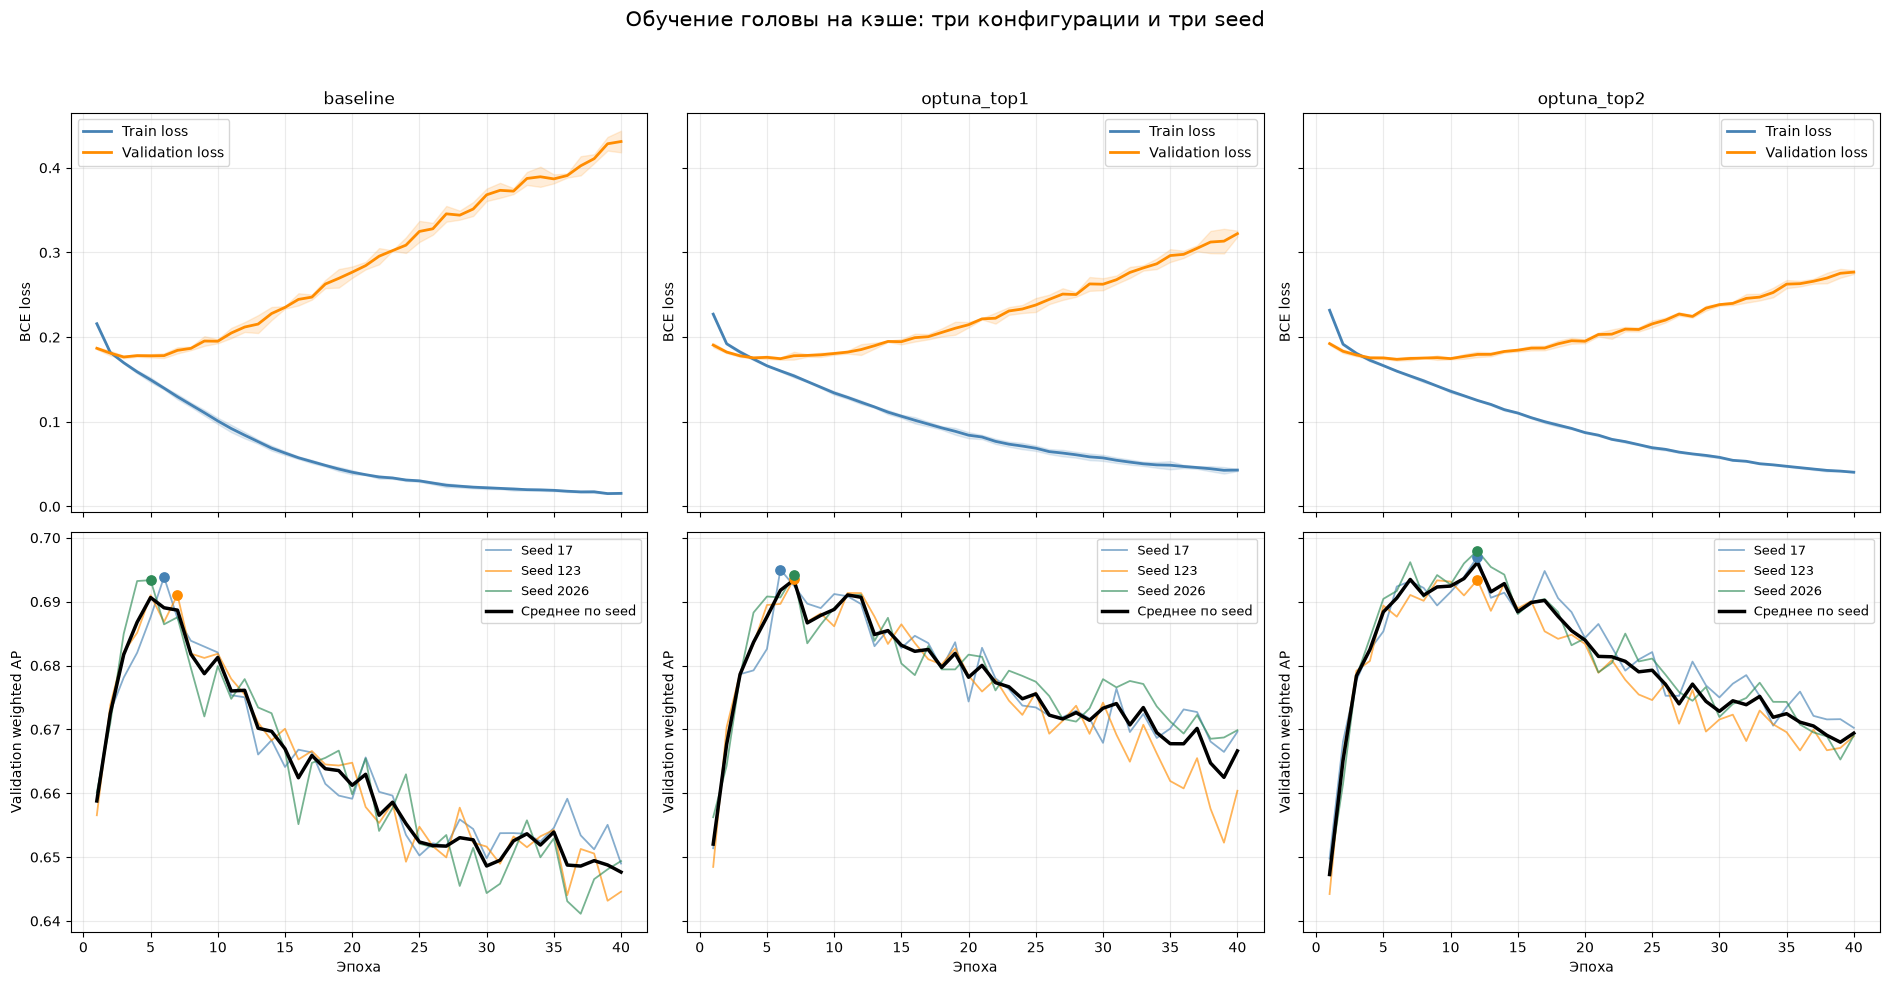


Графики сохранены: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/optuna_head_weighted_ap_v1/stability_20260917_120201_101959/learning_curves.png



In [81]:
config_order = [
    "baseline",
    "optuna_top1",
    "optuna_top2",
]

seed_colors = {
    17: "steelblue",
    123: "darkorange",
    2026: "seagreen",
}

fig, axes = plt.subplots(
    2,
    len(config_order),
    figsize=(19, 10),
    sharex=True,
    sharey="row",
)

for column, config_name in enumerate(config_order):
    config_history = learning_history.loc[
        learning_history["config"] == config_name
    ]

    epoch_stats = (
        config_history
        .groupby("epoch")[
            ["train_loss", "valid_loss", "weighted_ap"]
        ]
        .agg(["mean", "std"])
        .sort_index()
    )

    epochs = epoch_stats.index.to_numpy()

    # Верхний ряд: loss.
    loss_ax = axes[0, column]

    for metric, label, color in [
        ("train_loss", "Train loss", "steelblue"),
        ("valid_loss", "Validation loss", "darkorange"),
    ]:
        mean_values = epoch_stats[(metric, "mean")].to_numpy()
        std_values = (
            epoch_stats[(metric, "std")]
            .fillna(0)
            .to_numpy()
        )

        loss_ax.plot(
            epochs,
            mean_values,
            color=color,
            linewidth=2,
            label=label,
        )

        loss_ax.fill_between(
            epochs,
            mean_values - std_values,
            mean_values + std_values,
            color=color,
            alpha=0.15,
        )

    loss_ax.set_title(config_name)
    loss_ax.set_ylabel("BCE loss")
    loss_ax.grid(alpha=0.25)
    loss_ax.legend()

    # Нижний ряд: weighted AP отдельных запусков.
    ap_ax = axes[1, column]

    for seed, seed_history in config_history.groupby("seed"):
        seed_history = seed_history.sort_values("epoch")
        color = seed_colors[int(seed)]

        ap_ax.plot(
            seed_history["epoch"],
            seed_history["weighted_ap"],
            color=color,
            alpha=0.65,
            linewidth=1.3,
            label=f"Seed {seed}",
        )

        best_row = seed_history.loc[
            seed_history["weighted_ap"].idxmax()
        ]

        ap_ax.scatter(
            best_row["epoch"],
            best_row["weighted_ap"],
            color=color,
            s=45,
            zorder=5,
        )

    ap_ax.plot(
        epochs,
        epoch_stats[("weighted_ap", "mean")].to_numpy(),
        color="black",
        linewidth=2.5,
        label="Среднее по seed",
    )

    ap_ax.set_xlabel("Эпоха")
    ap_ax.set_ylabel("Validation weighted AP")
    ap_ax.grid(alpha=0.25)
    ap_ax.legend(fontsize=9)

fig.suptitle(
    "Обучение головы на кэше: три конфигурации и три seed",
    fontsize=15,
)

plt.tight_layout(rect=(0, 0, 1, 0.95))

figure_path = STABILITY_DIR / "learning_curves.png"

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(f'''
Графики сохранены: {figure_path}
''')

In [82]:
mean_ap_curves = (
    learning_history
    .groupby(["config", "epoch"], as_index=False)["weighted_ap"]
    .mean()
)

best_mean_indices = (
    mean_ap_curves
    .groupby("config")["weighted_ap"]
    .idxmax()
)

best_mean_epochs = (
    mean_ap_curves
    .loc[best_mean_indices]
    .rename(columns={
        "epoch": "best_epoch_of_mean_curve",
        "weighted_ap": "mean_ap_at_that_epoch",
    })
    .set_index("config")
    .reindex(config_order)
)

display(best_mean_epochs.round(6))

,best_epoch_of_mean_curve,mean_ap_at_that_epoch
config,,
baseline,5,0.690650
optuna_top1,7,0.693409
optuna_top2,12,0.696150


Обучаем trial 13 с нуля на всех 5970 объектах, ровно 13 эпох, seed 42. Затем заново настраиваем пороги и сравниваем с baseline на прежнем check.

In [83]:
from datetime import datetime

selected_config_name = (
    best_mean_epochs.reset_index()
    .sort_values(["mean_ap_at_that_epoch", "config"], ascending=[False, True])
    .iloc[0]["config"]
)
FINAL_EPOCHS = int(
    best_mean_epochs.loc[selected_config_name, "best_epoch_of_mean_curve"]
)
FINAL_SEED = 42
FINAL_BATCH_SIZE = 16

final_params = dict(stability_configs[selected_config_name])

# Сохраняем отдельно пороги прежней baseline-модели.
baseline_thresholds = np.asarray(
    tuned_thresholds,
    dtype=np.float64,
).copy()

FINAL_DIR = CACHE_DIR.parent / datetime.now().strftime(
    "selected_head_weighted_ap_%Y%m%d_%H%M%S_%f"
)
FINAL_DIR.mkdir(parents=True, exist_ok=False)

random.seed(FINAL_SEED)
np.random.seed(FINAL_SEED)
torch.manual_seed(FINAL_SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(FINAL_SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(FINAL_SEED)

full_train_dataset = CachedFeatureDataset(
    train_cache,
    np.arange(len(train_cache["item_ids"])),
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(FINAL_SEED),
)

final_head = CachedMultiViewHead(
    feature_dim=feature_dim,
    num_defects=NUM_DEFECTS,
    num_views=NUM_VIEWS,
    hidden_dim=final_params["hidden_dim"],
    dropout=final_params["dropout"],
).to(DEVICE)

final_optimizer = torch.optim.AdamW(
    final_head.parameters(),
    lr=final_params["learning_rate"],
    weight_decay=final_params["weight_decay"],
)

print(f'''
Обучающих объектов: {len(full_train_dataset)}
Эпох: {FINAL_EPOCHS}
Seed: {FINAL_SEED}
Batch size: {FINAL_BATCH_SIZE}

Параметры:
{json.dumps(final_params, indent=2)}

Папка результатов: {FINAL_DIR}
''')


Обучающих объектов: 5970
Эпох: 12
Seed: 42
Batch size: 16

Параметры:
{
  "learning_rate": 0.0004918226353573444,
  "weight_decay": 0.0007023866368536486,
  "hidden_dim": 256,
  "dropout": 0.4348349614821148
}

Папка результатов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/selected_head_weighted_ap_20260917_122047_310175



In [84]:
final_history = []

started_at = perf_counter()

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss = train_cached_epoch(
        final_head,
        full_train_loader,
        final_optimizer,
        DEVICE,
    )

    final_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
    })

    pd.DataFrame(final_history).to_csv(
        FINAL_DIR / "train_history.csv",
        index=False,
    )

    print(f'''
Эпоха {epoch}/{FINAL_EPOCHS}
Train loss: {train_loss:.6f}
''')

final_head.eval()

# Сохраняем голову до настройки порогов.
torch.save(
    {
        "head_state_dict": {
            name: tensor.detach().cpu()
            for name, tensor in final_head.state_dict().items()
        },
        "selection_metric": SELECTION_METRIC,
        "selected_config": selected_config_name,
        "params": final_params,
        "epoch": FINAL_EPOCHS,
        "seed": FINAL_SEED,
        "feature_dim": feature_dim,
        "num_views": NUM_VIEWS,
        "defect_columns": list(DEFECT_COLUMNS),
        "cache_metadata": train_cache["metadata"],
    },
    FINAL_DIR / "head.pt",
)

print(f'''
Обучение завершено за {perf_counter() - started_at:.2f} с.
Сохранены веса после {FINAL_EPOCHS}-й эпохи.
''')


Эпоха 1/12
Train loss: 0.225509


Эпоха 2/12
Train loss: 0.187882


Эпоха 3/12
Train loss: 0.178839


Эпоха 4/12
Train loss: 0.170267


Эпоха 5/12
Train loss: 0.164358


Эпоха 6/12
Train loss: 0.158873


Эпоха 7/12
Train loss: 0.154600


Эпоха 8/12
Train loss: 0.148421


Эпоха 9/12
Train loss: 0.142112


Эпоха 10/12
Train loss: 0.137191


Эпоха 11/12
Train loss: 0.131811


Эпоха 12/12
Train loss: 0.126483


Обучение завершено за 8.52 с.
Сохранены веса после 12-й эпохи.



In [85]:
with open(BEST_MODEL_PATH, "rb") as file:
    source_checkpoint_hash = hashlib.file_digest(
        file,
        "sha256",
    ).hexdigest()

assert (
    source_checkpoint_hash
    == train_cache["metadata"]["checkpoint_sha256"]
)
assert (
    source_checkpoint_hash
    == valid_cache["metadata"]["checkpoint_sha256"]
)

source_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

model.load_state_dict(
    source_checkpoint["model_state_dict"],
    strict=True,
)
model.eval()
final_head.eval()

baseline_probability_batches = []
final_probability_batches = []

with torch.no_grad():
    for start in range(
        0,
        len(valid_cache["item_ids"]),
        FINAL_BATCH_SIZE,
    ):
        features = valid_cache["features"][
            start:start + FINAL_BATCH_SIZE
        ].to(DEVICE)

        baseline_logits = logits_from_features(
            model,
            features,
        )
        final_logits = final_head(features)

        baseline_probability_batches.append(
            torch.sigmoid(baseline_logits).cpu().numpy()
        )
        final_probability_batches.append(
            torch.sigmoid(final_logits).cpu().numpy()
        )

baseline_full_probabilities = np.concatenate(
    baseline_probability_batches,
    axis=0,
)

final_full_probabilities = np.concatenate(
    final_probability_batches,
    axis=0,
)

assert np.isfinite(baseline_full_probabilities).all()
assert np.isfinite(final_full_probabilities).all()

In [86]:
cached_valid_ids = pd.Index(
    valid_cache["item_ids"],
    name="item_id",
)

assert cached_valid_ids.is_unique
assert threshold_df.index.is_unique
assert set(cached_valid_ids) == set(threshold_df.index)

aligned_validation = threshold_df.loc[cached_valid_ids]

final_valid_targets = valid_cache["targets"].numpy()

assert np.array_equal(
    aligned_validation[TARGET_COLUMNS].to_numpy(),
    final_valid_targets,
)

final_calibration_mask = (
    aligned_validation["group_id"]
    .isin(calibration_groups)
    .to_numpy()
)

final_check_mask = (
    aligned_validation["group_id"]
    .isin(check_groups)
    .to_numpy()
)

assert not (final_calibration_mask & final_check_mask).any()
assert (final_calibration_mask | final_check_mask).all()

print(f'''
Объектов calibration: {final_calibration_mask.sum()}
Объектов check: {final_check_mask.sum()}

Используем прежнее разбиение.
''')


Объектов calibration: 1496
Объектов check: 1498

Используем прежнее разбиение.



### Подбор новых порогов

In [87]:
final_thresholds, final_threshold_history = (
    tune_class_thresholds(
        targets=final_valid_targets[final_calibration_mask],
        probabilities=final_full_probabilities[
            final_calibration_mask
        ],
        initial_thresholds=np.full(NUM_DEFECTS, 0.5),
        max_passes=5,
    )
)

final_threshold_table = pd.DataFrame(
    {
        "baseline_threshold": baseline_thresholds,
        "selected_head_threshold": final_thresholds,
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

display(final_threshold_table.round(4))

final_threshold_table.to_csv(
    FINAL_DIR / "thresholds.csv",
)

final_threshold_history.to_csv(
    FINAL_DIR / "threshold_search.csv",
    index=False,
)

Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 12.841286



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 13.042277



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 3
Метрика на calibration: 13.042277



,baseline_threshold,selected_head_threshold
defect,,
abstract,0.2100,0.1000
artifacts,0.0800,0.1500
intersection,0.0562,0.0681
lowpoly,0.5600,0.2900
noisy,0.3600,0.5400
open,0.1300,0.1400
partial,0.2700,0.4700
scale,0.0147,0.1200
set,0.4200,0.1800


### Проверка

In [88]:
comparison_variants = [
    (
        "baseline_0.5",
        baseline_full_probabilities,
        np.full(NUM_DEFECTS, 0.5),
    ),
    (
        "baseline_tuned",
        baseline_full_probabilities,
        baseline_thresholds,
    ),
    (
        "selected_head_0.5",
        final_full_probabilities,
        np.full(NUM_DEFECTS, 0.5),
    ),
    (
        "selected_head_tuned",
        final_full_probabilities,
        final_thresholds,
    ),
]

final_comparison_rows = []
final_quality_rows = []

check_labels = final_valid_targets[final_check_mask]
true_quality = check_labels[:, NUM_DEFECTS].astype(int)

for variant, probabilities, thresholds in comparison_variants:
    check_probabilities_for_model = probabilities[final_check_mask]

    metrics = calculate_metrics(
        check_labels,
        check_probabilities_for_model,
        thresholds=thresholds,
    )

    final_comparison_rows.append({
        "variant": variant,
        **metrics,
    })

    predicted_defects = (
        check_probabilities_for_model >= thresholds
    )
    predicted_quality = ~predicted_defects.any(axis=1)

    final_quality_rows.append({
        "variant": variant,
        "bad_as_bad": int((
            (true_quality == 0) & ~predicted_quality
        ).sum()),
        "bad_as_good": int((
            (true_quality == 0) & predicted_quality
        ).sum()),
        "good_as_bad": int((
            (true_quality == 1) & ~predicted_quality
        ).sum()),
        "good_as_good": int((
            (true_quality == 1) & predicted_quality
        ).sum()),
    })

final_comparison = (
    pd.DataFrame(final_comparison_rows)
    .set_index("variant")
)

final_quality_report = (
    pd.DataFrame(final_quality_rows)
    .set_index("variant")
)

display(final_comparison.round(6))
display(final_quality_report)

final_gain = (
    final_comparison.loc["selected_head_tuned", "f1_final"]
    - final_comparison.loc["baseline_tuned", "f1_final"]
)

print(f'''
Изменение конкурсной метрики относительно baseline:
{final_gain:+.6f}
''')

,f1_quality,f1_defects_weighted,f1_final,weighted_ap
variant,,,,
baseline_0.5,0.499266,0.585042,10.843083,0.677597
baseline_tuned,0.566038,0.617459,11.834962,0.677597
selected_head_0.5,0.512091,0.586085,10.981763,0.679660
selected_head_tuned,0.572034,0.621235,11.932692,0.679660


,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
baseline_0.5,987,282,59,170
baseline_tuned,1156,113,94,135
selected_head_0.5,975,294,49,180
selected_head_tuned,1161,108,94,135



Изменение конкурсной метрики относительно baseline:
+0.097729



### Сохраняем полный checkpoint новой модели

In [89]:
full_model_state = {
    name: tensor
    for name, tensor in source_checkpoint["model_state_dict"].items()
    if name.startswith("backbone.")
}

full_model_state.update({
    name: tensor.detach().cpu()
    for name, tensor in final_head.state_dict().items()
})

final_model_config = {
    **source_checkpoint["config"],
    **final_params,
    "seed": FINAL_SEED,
    "epochs": FINAL_EPOCHS,
    "batch_size": FINAL_BATCH_SIZE,
    "accumulation_steps": 1,
    "thresholds": final_thresholds.tolist(),
    "freeze_backbone": True,
}

torch.save(
    {
        "model_state_dict": full_model_state,
        "config": final_model_config,
        "epoch": FINAL_EPOCHS,
        "metrics": final_comparison.loc[
            "selected_head_tuned"
        ].to_dict(),
        "evaluation_split": "check",
        "source_checkpoint_sha256": source_checkpoint_hash,
    },
    FINAL_DIR / "model.pt",
)

final_comparison.to_csv(
    FINAL_DIR / "check_metrics.csv",
)

final_quality_report.to_csv(
    FINAL_DIR / "check_quality_errors.csv",
)

validation_export = aligned_validation[["group_id"]].copy()
validation_export["part"] = np.where(
    final_calibration_mask,
    "calibration",
    "check",
)
validation_export.to_csv(
    FINAL_DIR / "validation_split.csv",
)

np.savez_compressed(
    FINAL_DIR / "validation_predictions.npz",
    item_ids=np.asarray(valid_cache["item_ids"], dtype=str),
    targets=final_valid_targets,
    probabilities=final_full_probabilities,
    thresholds=final_thresholds,
)

print(f'''
Полная модель сохранена:
{FINAL_DIR / "model.pt"}

Метрики, пороги и предсказания сохранены в той же папке.
''')


Полная модель сохранена:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/selected_head_weighted_ap_20260917_122047_310175/model.pt

Метрики, пороги и предсказания сохранены в той же папке.



## 11. Агрегация по классам через attention

Заменим простую агрегацию обучаемыми запросами классов, которые выбирают полезные признаки ракурсов. Сравним модель с предыдущим вариантом на том же разбиении и при сопоставимом обучении.

Добавим голову с отдельным attention-запросом для каждого дефекта. Используем прежний кэш и внутреннее разбиение.

В этой модели:
- шесть векторов DINOv2 преобразуются в шесть векторов размерности 128;
- каждый дефект получает свой обучаемый запрос;
- запрос выбирает информацию из ракурсов через attention;
- из полученных признаков вычисляются десять logits.

Позиционные векторы обозначают порядок ракурсов в коллаже, а не точные параметры камер.

In [90]:
class ClassQueryAttentionHead(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_defects,
        num_views=6,
        embed_dim=128,
        num_heads=4,
        dropout=0.2,
    ):
        super().__init__()

        if embed_dim % num_heads != 0:
            raise ValueError(
                "embed_dim должен делиться на num_heads."
            )

        self.feature_dim = feature_dim
        self.num_views = num_views

        self.input_projection = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, embed_dim),
        )

        self.view_embeddings = nn.Parameter(
            torch.empty(1, num_views, embed_dim)
        )

        self.class_queries = nn.Parameter(
            torch.empty(1, num_defects, embed_dim)
        )

        nn.init.normal_(self.view_embeddings, std=0.02)
        nn.init.normal_(self.class_queries, std=0.02)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.attention_norm = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )

        self.output_norm = nn.LayerNorm(embed_dim)
        self.residual_dropout = nn.Dropout(dropout)

        # Один общий классификатор применяется
        # к отдельному вектору каждого дефекта.
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, features, return_attention=False):
        if (
            features.ndim != 3
            or tuple(features.shape[1:])
            != (self.num_views, self.feature_dim)
        ):
            raise ValueError(
                "Ожидается [batch, num_views, feature_dim]."
            )

        tokens = (
            self.input_projection(features)
            + self.view_embeddings
        )

        queries = self.class_queries.expand(
            features.shape[0],
            -1,
            -1,
        )

        attended, weights = self.attention(
            query=queries,
            key=tokens,
            value=tokens,
            need_weights=return_attention,
            average_attn_weights=True,
        )

        class_features = self.attention_norm(
            queries + self.residual_dropout(attended)
        )

        class_features = self.output_norm(
            class_features
            + self.residual_dropout(
                self.ffn(class_features)
            )
        )

        logits = self.classifier(
            class_features
        ).squeeze(-1)

        if return_attention:
            return logits, weights

        return logits

#### Инициализация и проверка

In [91]:
ATTENTION_SEED = 42
ATTENTION_EPOCHS = 40

attention_config = {
    "feature_dim": feature_dim,
    "num_defects": NUM_DEFECTS,
    "num_views": NUM_VIEWS,
    "embed_dim": 128,
    "num_heads": 4,
    "dropout": 0.2,
}

random.seed(ATTENTION_SEED)
np.random.seed(ATTENTION_SEED)
torch.manual_seed(ATTENTION_SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(ATTENTION_SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(ATTENTION_SEED)

attention_head = ClassQueryAttentionHead(
    **attention_config
).to(DEVICE)

attention_head.eval()

example_features = train_cache["features"][:4].to(DEVICE)

with torch.no_grad():
    example_logits, example_attention = attention_head(
        example_features,
        return_attention=True,
    )

assert example_logits.shape == (4, NUM_DEFECTS)
assert example_attention.shape == (4, NUM_DEFECTS, NUM_VIEWS)
assert torch.isfinite(example_logits).all().item()

# В eval веса attention по ракурсам суммируются в единицу.
torch.testing.assert_close(
    example_attention.sum(dim=-1),
    torch.ones_like(example_attention.sum(dim=-1)),
    rtol=1e-4,
    atol=1e-5,
)

print(f'''
Форма logits: {tuple(example_logits.shape)}
Форма attention: {tuple(example_attention.shape)}

Обучаемых параметров:
{sum(p.numel() for p in attention_head.parameters()):,}
''')


Форма logits: (4, 10)
Форма attention: (4, 10, 6)

Обучаемых параметров:
184,705



#### Обучение на внутреннем разбиении

In [92]:
ATTENTION_DIR = CACHE_DIR.parent / datetime.now().strftime(
    "class_attention_weighted_ap_%Y%m%d_%H%M%S_%f"
)
ATTENTION_DIR.mkdir(parents=True, exist_ok=False)

attention_train_loader = DataLoader(
    inner_train_dataset,
    batch_size=CACHE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(ATTENTION_SEED),
)

attention_optimizer = torch.optim.AdamW(
    attention_head.parameters(),
    lr=5e-4,
    weight_decay=1e-2,
)

attention_history = []
best_attention_ap = -float("inf")
best_attention_epoch = None

started_at = perf_counter()

for epoch in range(1, ATTENTION_EPOCHS + 1):
    train_loss = train_cached_epoch(
        attention_head,
        attention_train_loader,
        attention_optimizer,
        DEVICE,
    )

    valid_metrics = evaluate_cached_head(
        attention_head,
        inner_valid_loader,
        DEVICE,
    )

    current_ap = valid_metrics["weighted_ap"]

    if not np.isfinite(current_ap):
        raise ValueError(
            "Weighted AP содержит NaN или бесконечность."
        )

    attention_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_metrics["loss"],
        "weighted_ap": current_ap,
    })

    pd.DataFrame(attention_history).to_csv(
        ATTENTION_DIR / "history.csv",
        index=False,
    )

    if current_ap > best_attention_ap:
        best_attention_ap = current_ap
        best_attention_epoch = epoch

        torch.save(
            {
                "architecture": "class_query_attention_v1",
                "selection_metric": SELECTION_METRIC,
                "head_state_dict": {
                    name: tensor.detach().cpu()
                    for name, tensor in attention_head.state_dict().items()
                },
                "head_config": attention_config,
                "epoch": epoch,
                "weighted_ap": current_ap,
                "seed": ATTENTION_SEED,
                "learning_rate": 5e-4,
                "weight_decay": 1e-2,
                "batch_size": CACHE_BATCH_SIZE,
                "defect_columns": list(DEFECT_COLUMNS),
                "cache_metadata": train_cache["metadata"],
                "inner_train_indices": inner_train_indices.tolist(),
                "inner_valid_indices": inner_valid_indices.tolist(),
            },
            ATTENTION_DIR / "best_head.pt",
        )

    if epoch == 1 or epoch % 5 == 0:
        print(f'''
Эпоха: {epoch}/{ATTENTION_EPOCHS}
Train loss: {train_loss:.4f}
Validation loss: {valid_metrics["loss"]:.4f}
Weighted AP: {current_ap:.6f}
''')

print(f'''
Обучение завершено за {perf_counter() - started_at:.2f} с.

Лучший weighted AP: {best_attention_ap:.6f}
Лучшая эпоха: {best_attention_epoch}

Результаты: {ATTENTION_DIR}
''')


Эпоха: 1/40
Train loss: 0.2988
Validation loss: 0.2573
Weighted AP: 0.404613


Эпоха: 5/40
Train loss: 0.1993
Validation loss: 0.2029
Weighted AP: 0.595375


Эпоха: 10/40
Train loss: 0.1665
Validation loss: 0.1958
Weighted AP: 0.639094


Эпоха: 15/40
Train loss: 0.1444
Validation loss: 0.2038
Weighted AP: 0.643362


Эпоха: 20/40
Train loss: 0.1272
Validation loss: 0.2155
Weighted AP: 0.637329


Эпоха: 25/40
Train loss: 0.1131
Validation loss: 0.2411
Weighted AP: 0.633388


Эпоха: 30/40
Train loss: 0.1025
Validation loss: 0.2368
Weighted AP: 0.628056


Эпоха: 35/40
Train loss: 0.0919
Validation loss: 0.2588
Weighted AP: 0.620946


Эпоха: 40/40
Train loss: 0.0861
Validation loss: 0.2579
Weighted AP: 0.625557


Обучение завершено за 59.17 с.

Лучший weighted AP: 0.656618
Лучшая эпоха: 17

Результаты: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/class_attention_weighted_ap_20260917_122101_655186



#### Кривые нового эксперимента

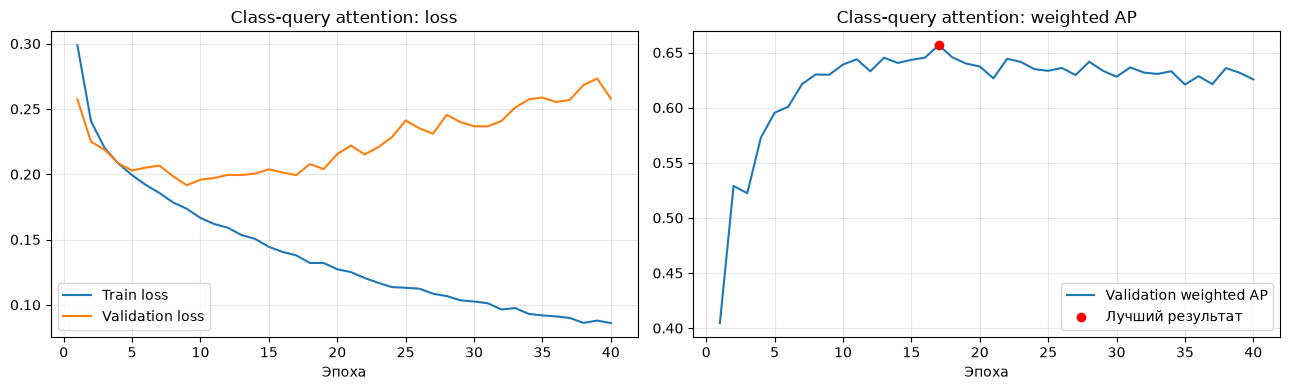

In [93]:
attention_history_df = pd.DataFrame(attention_history)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4),
)

axes[0].plot(
    attention_history_df["epoch"],
    attention_history_df["train_loss"],
    label="Train loss",
)

axes[0].plot(
    attention_history_df["epoch"],
    attention_history_df["valid_loss"],
    label="Validation loss",
)

axes[0].set_title("Class-query attention: loss")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    attention_history_df["epoch"],
    attention_history_df["weighted_ap"],
    label="Validation weighted AP",
)

axes[1].scatter(
    best_attention_epoch,
    best_attention_ap,
    color="red",
    zorder=5,
    label="Лучший результат",
)

axes[1].set_title("Class-query attention: weighted AP")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    ATTENTION_DIR / "learning_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

,true_label,probability
abstract,0.0,0.178
artifacts,0.0,0.001
intersection,0.0,0.002
lowpoly,0.0,0.082
noisy,0.0,0.007
open,0.0,0.002
partial,0.0,0.003
scale,0.0,0.001
set,1.0,0.890
simple,0.0,0.011


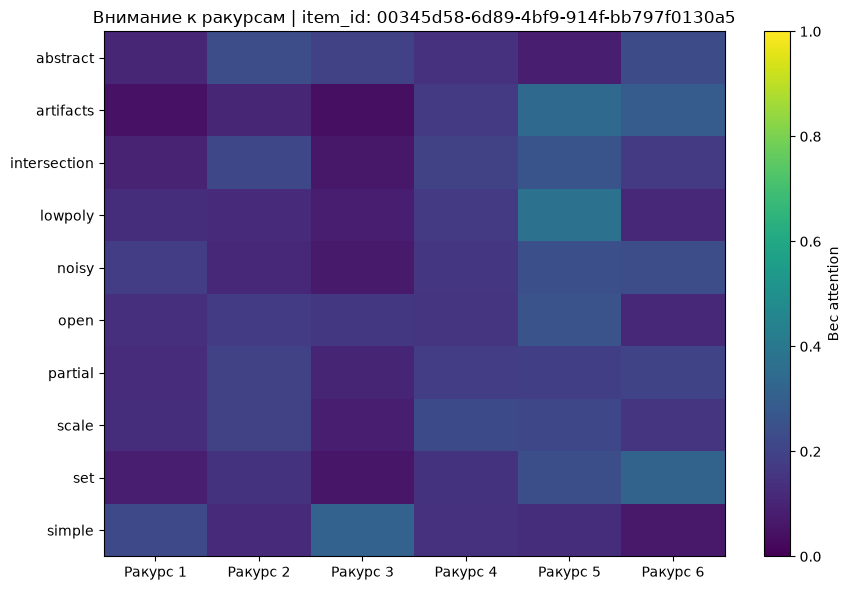

In [94]:
attention_checkpoint = torch.load(
    ATTENTION_DIR / "best_head.pt",
    map_location="cpu",
    weights_only=True,
)

attention_head.load_state_dict(
    attention_checkpoint["head_state_dict"],
    strict=True,
)
attention_head.eval()

example = inner_valid_dataset[0]

with torch.no_grad():
    logits, attention_weights = attention_head(
        example["features"].unsqueeze(0).to(DEVICE),
        return_attention=True,
    )

probabilities = torch.sigmoid(logits)[0].cpu().numpy()
attention_map = attention_weights[0].cpu().numpy()

display(
    pd.DataFrame(
        {
            "true_label": example["targets"][:NUM_DEFECTS].numpy(),
            "probability": probabilities,
        },
        index=DEFECT_COLUMNS,
    ).round(3)
)

fig, ax = plt.subplots(figsize=(9, 6))

image = ax.imshow(
    attention_map,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(NUM_VIEWS))
ax.set_xticklabels([
    f"Ракурс {index + 1}"
    for index in range(NUM_VIEWS)
])

ax.set_yticks(range(NUM_DEFECTS))
ax.set_yticklabels(DEFECT_COLUMNS)

ax.set_title(
    f"Внимание к ракурсам | item_id: {example['item_id']}"
)

fig.colorbar(
    image,
    ax=ax,
    label="Вес attention",
)

plt.tight_layout()
plt.show()

**Исторический результат до перехода на weighted AP; не результат нового запуска.**

Текущая attention-голова заметно уступила mean/max pooling. Лучший macro AP — 0.4415, тогда как предыдущие головы на том же внутреннем разбиении показывали результаты около 0.48–0.49. Пока сохраняем прежний baseline, но попробуем использовать этот подход как его поправку

## Эксперимент с Attention подходом

- добавить attention как небольшую поправку к уже работающему baseline

```
Признаки ракурсов
    |-- mean/max -> обученная голова -> baseline_logits
    |-- attention -> дополнительные logits
                                      |
                                      |
                 итог = baseline_logits + поправка
```

In [95]:
class ResidualAttentionHead(nn.Module):
    def __init__(self, baseline, correction):
        super().__init__()

        self.baseline = baseline
        self.correction = correction

        self.baseline.requires_grad_(False)
        self.baseline.eval()

        nn.init.zeros_(
            self.correction.classifier.weight
        )
        nn.init.zeros_(
            self.correction.classifier.bias
        )

    def train(self, mode=True):
        super().train(mode)

        # Dropout в замороженном baseline всегда выключен.
        self.baseline.eval()

        return self

    def forward(self, features, return_attention=False):
        baseline_logits = self.baseline(features)

        if return_attention:
            correction_logits, weights = self.correction(
                features,
                return_attention=True,
            )

            return (
                baseline_logits + correction_logits,
                weights,
            )

        correction_logits = self.correction(features)

        return baseline_logits + correction_logits

Складываем logits, затем существующие функции применяют sigmoid. Поправка может как повысить, так и понизить вероятность дефекта.


На первом шаге градиент обучает обнулённый выходной слой. После изменения его весов градиенты начинают проходить и в предшествующие слои новой ветви.

In [96]:
RESIDUAL_SEED = 42
RESIDUAL_EPOCHS = 40
RESIDUAL_LR = 1e-4
RESIDUAL_WEIGHT_DECAY = 1e-2

residual_base_path = (
    OPTUNA_DIR / "trial_000" / "best_head.pt"
)

residual_base_checkpoint = torch.load(
    residual_base_path,
    map_location="cpu",
    weights_only=True,
)

assert (
    residual_base_checkpoint["experiment_hash"]
    == experiment_hash
)
assert (
    residual_base_checkpoint["defect_columns"]
    == DEFECT_COLUMNS
)
assert (
    residual_base_checkpoint["feature_dim"]
    == feature_dim
)

random.seed(RESIDUAL_SEED)
np.random.seed(RESIDUAL_SEED)
torch.manual_seed(RESIDUAL_SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(RESIDUAL_SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(RESIDUAL_SEED)

residual_base_config = {
    "feature_dim": residual_base_checkpoint["feature_dim"],
    "num_defects": NUM_DEFECTS,
    "num_views": residual_base_checkpoint["num_views"],
    "hidden_dim": residual_base_checkpoint["params"]["hidden_dim"],
    "dropout": residual_base_checkpoint["params"]["dropout"],
}

residual_baseline = CachedMultiViewHead(
    **residual_base_config
)

residual_baseline.load_state_dict(
    residual_base_checkpoint["head_state_dict"],
    strict=True,
)

correction_config = {
    "feature_dim": feature_dim,
    "num_defects": NUM_DEFECTS,
    "num_views": NUM_VIEWS,
    "embed_dim": 128,
    "num_heads": 4,
    "dropout": 0.2,
}

attention_correction = ClassQueryAttentionHead(
    **correction_config
)

residual_head = ResidualAttentionHead(
    baseline=residual_baseline,
    correction=attention_correction,
).to(DEVICE)

In [97]:
residual_head.eval()

probe_features = (
    train_cache["features"][:4].to(DEVICE)
)

with torch.no_grad():
    baseline_logits = residual_head.baseline(
        probe_features
    )
    residual_logits = residual_head(
        probe_features
    )

torch.testing.assert_close(
    residual_logits,
    baseline_logits,
    rtol=0,
    atol=0,
)

initial_residual_metrics = evaluate_cached_head(
    residual_head,
    inner_valid_loader,
    DEVICE,
)

assert np.isclose(
    initial_residual_metrics["weighted_ap"],
    residual_base_checkpoint["weighted_ap"],
    rtol=1e-5,
    atol=1e-6,
)

print(f'''
Начальные logits точно совпадают с baseline.

Weighted AP baseline:
{residual_base_checkpoint["weighted_ap"]:.6f}

Weighted AP модели с нулевой поправкой:
{initial_residual_metrics["weighted_ap"]:.6f}

Обучаемых параметров:
{sum(p.numel() for p in residual_head.parameters() if p.requires_grad):,}
''')


Начальные logits точно совпадают с baseline.

Weighted AP baseline:
0.693704

Weighted AP модели с нулевой поправкой:
0.693704

Обучаемых параметров:
184,705



### ПОдготовка обучения и сохранение

In [98]:
RESIDUAL_DIR = CACHE_DIR.parent / datetime.now().strftime(
    "residual_attention_weighted_ap_%Y%m%d_%H%M%S_%f"
)
RESIDUAL_DIR.mkdir(parents=True, exist_ok=False)

residual_train_loader = DataLoader(
    inner_train_dataset,
    batch_size=CACHE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(RESIDUAL_SEED),
)

residual_optimizer = torch.optim.AdamW(
    [
        parameter
        for parameter in residual_head.parameters()
        if parameter.requires_grad
    ],
    lr=RESIDUAL_LR,
    weight_decay=RESIDUAL_WEIGHT_DECAY,
)


def save_residual_checkpoint(epoch, metrics):
    torch.save(
        {
            "architecture": "residual_attention_v1",
            "selection_metric": SELECTION_METRIC,
                "head_state_dict": {
                name: tensor.detach().cpu()
                for name, tensor in residual_head.state_dict().items()
            },
            "baseline_config": residual_base_config,
            "correction_config": correction_config,
            "baseline_checkpoint": str(residual_base_path.resolve()),
            "source_experiment_hash": experiment_hash,
            "epoch": epoch,
            "metrics": dict(metrics),
            "seed": RESIDUAL_SEED,
            "learning_rate": RESIDUAL_LR,
            "weight_decay": RESIDUAL_WEIGHT_DECAY,
            "batch_size": CACHE_BATCH_SIZE,
            "defect_columns": list(DEFECT_COLUMNS),
            "cache_metadata": train_cache["metadata"],
            "inner_train_indices": inner_train_indices.tolist(),
            "inner_valid_indices": inner_valid_indices.tolist(),
        },
        RESIDUAL_DIR / "best_head.pt",
    )


save_residual_checkpoint(
    epoch=0,
    metrics=initial_residual_metrics,
)

### Обучение поправки

In [99]:
residual_history = [{
    "epoch": 0,
    "train_loss": np.nan,
    "valid_loss": initial_residual_metrics["loss"],
    "weighted_ap": initial_residual_metrics["weighted_ap"],
}]

best_residual_ap = initial_residual_metrics["weighted_ap"]
best_residual_epoch = 0

started_at = perf_counter()

for epoch in range(1, RESIDUAL_EPOCHS + 1):
    train_loss = train_cached_epoch(
        residual_head,
        residual_train_loader,
        residual_optimizer,
        DEVICE,
    )

    metrics = evaluate_cached_head(
        residual_head,
        inner_valid_loader,
        DEVICE,
    )

    if not np.isfinite(metrics["weighted_ap"]):
        raise ValueError(
            "Weighted AP содержит NaN или бесконечность."
        )

    residual_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": metrics["loss"],
        "weighted_ap": metrics["weighted_ap"],
    })

    pd.DataFrame(residual_history).to_csv(
        RESIDUAL_DIR / "history.csv",
        index=False,
    )

    if metrics["weighted_ap"] > best_residual_ap:
        best_residual_ap = metrics["weighted_ap"]
        best_residual_epoch = epoch

        save_residual_checkpoint(
            epoch=epoch,
            metrics=metrics,
        )

    if epoch == 1 or epoch % 5 == 0:
        print(f'''
Эпоха: {epoch}/{RESIDUAL_EPOCHS}
Train loss: {train_loss:.4f}
Validation loss: {metrics["loss"]:.4f}
Weighted AP: {metrics["weighted_ap"]:.6f}
''')

print(f'''
Обучение завершено за {perf_counter() - started_at:.2f} с.

Исходный weighted AP: {initial_residual_metrics["weighted_ap"]:.6f}
Лучший weighted AP: {best_residual_ap:.6f}
Изменение: {best_residual_ap - initial_residual_metrics["weighted_ap"]:+.6f}

Лучшая эпоха поправки: {best_residual_epoch}
Результаты: {RESIDUAL_DIR}
''')


Эпоха: 1/40
Train loss: 0.1318
Validation loss: 0.1788
Weighted AP: 0.693278


Эпоха: 5/40
Train loss: 0.1259
Validation loss: 0.1733
Weighted AP: 0.693416


Эпоха: 10/40
Train loss: 0.1239
Validation loss: 0.1735
Weighted AP: 0.693709


Эпоха: 15/40
Train loss: 0.1218
Validation loss: 0.1746
Weighted AP: 0.689236


Эпоха: 20/40
Train loss: 0.1184
Validation loss: 0.1782
Weighted AP: 0.680723


Эпоха: 25/40
Train loss: 0.1148
Validation loss: 0.1836
Weighted AP: 0.671763


Эпоха: 30/40
Train loss: 0.1117
Validation loss: 0.1828
Weighted AP: 0.673916


Эпоха: 35/40
Train loss: 0.1082
Validation loss: 0.1855
Weighted AP: 0.667698


Эпоха: 40/40
Train loss: 0.1054
Validation loss: 0.1912
Weighted AP: 0.656787


Обучение завершено за 55.96 с.

Исходный weighted AP: 0.693704
Лучший weighted AP: 0.694628
Изменение: +0.000924

Лучшая эпоха поправки: 3
Результаты: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/dinov2_weighted_ap_20260917_113030/residual_attenti

### Кривые обучения

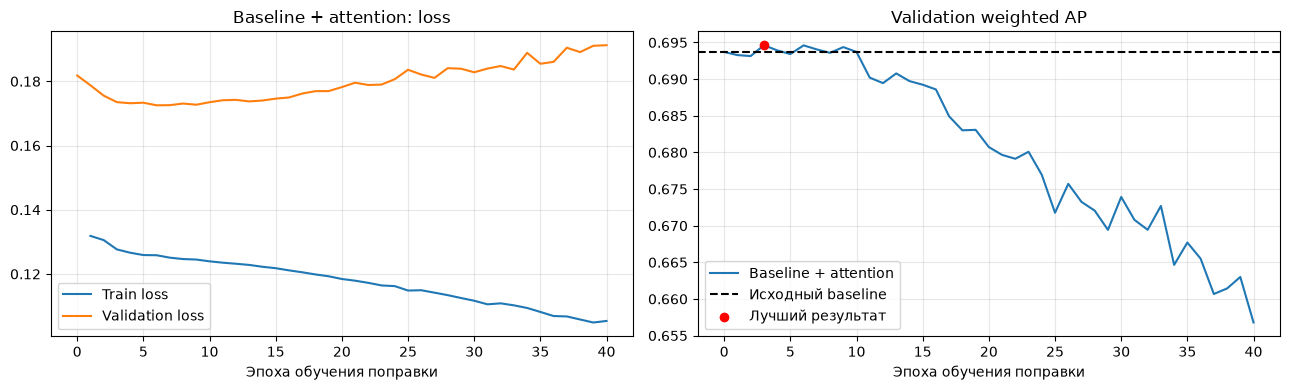

ResidualAttentionHead(
  (baseline): CachedMultiViewHead(
    (fusion): Sequential(
      (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (1): Linear(in_features=768, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
    (defect_head): Linear(in_features=256, out_features=10, bias=True)
  )
  (correction): ClassQueryAttentionHead(
    (input_projection): Sequential(
      (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (1): Linear(in_features=384, out_features=128, bias=True)
    )
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (attention_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (ffn): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
     

In [100]:
residual_history_df = pd.DataFrame(residual_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    residual_history_df["epoch"],
    residual_history_df["train_loss"],
    label="Train loss",
)

axes[0].plot(
    residual_history_df["epoch"],
    residual_history_df["valid_loss"],
    label="Validation loss",
)

axes[0].set_title("Baseline + attention: loss")
axes[0].set_xlabel("Эпоха обучения поправки")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    residual_history_df["epoch"],
    residual_history_df["weighted_ap"],
    label="Baseline + attention",
)

axes[1].axhline(
    initial_residual_metrics["weighted_ap"],
    color="black",
    linestyle="--",
    label="Исходный baseline",
)

axes[1].scatter(
    best_residual_epoch,
    best_residual_ap,
    color="red",
    zorder=5,
    label="Лучший результат",
)

axes[1].set_title("Validation weighted AP")
axes[1].set_xlabel("Эпоха обучения поправки")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    RESIDUAL_DIR / "learning_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

best_residual_checkpoint = torch.load(
    RESIDUAL_DIR / "best_head.pt",
    map_location="cpu",
    weights_only=True,
)

residual_head.load_state_dict(
    best_residual_checkpoint["head_state_dict"],
    strict=True,
)
residual_head.eval()

Attention-поправка не дала убедительного улучшения. Прирост составил лишь 0.000890 macro AP, причём это лучший результат среди 40 эпох одного запуска.

## 12. Подготовка геометрии мешей

Загрузим вершины и грани NPZ, проверим корректность и нормализуем координаты копии меша. Детерминированно выберем точки поверхности и нормали, сохранив связь с исходными гранями. Не будем сглаживать или исправлять целевые дефекты; учтём ограничения памяти для крупных мешей.

Для 3D-ветви будем получать:
- points: координаты 4096 точек поверхности
- normals: нормали соответствующих треугольников
- face_ids: индексы исходных граней для последующей визуализации

Треугольники выбираем пропорционально площади, чтобы плотность точек не зависела от плотности триангуляции. Внутри выбранного треугольника точку выбираем равномерно.

In [101]:
import hashlib

NUM_POINTS = 8192
FACE_CHUNK_SIZE = 100_000


def item_sampling_seed(item_id, seed):
    digest = hashlib.sha256(
        f"{seed}:{item_id}".encode("utf-8")
    ).digest()

    return int.from_bytes(
        digest[:8],
        byteorder="little",
    )

### Чтение блока треугольников и вычисление площадей

In [102]:
def read_triangles(vertices, face_block):
    if (
        face_block.min() < 0
        or face_block.max() >= len(vertices)
    ):
        raise ValueError(
            "Грань ссылается на несуществующую вершину."
        )

    triangles = np.asarray(
        vertices[face_block],
        dtype=np.float64,
    )

    if not np.isfinite(triangles).all():
        raise ValueError(
            "Координаты используемых вершин содержат NaN/inf."
        )

    edge_1 = triangles[:, 1] - triangles[:, 0]
    edge_2 = triangles[:, 2] - triangles[:, 0]

    cross_products = np.cross(edge_1, edge_2)

    areas = 0.5 * np.linalg.norm(
        cross_products,
        axis=1,
    )

    if not np.isfinite(areas).all():
        raise ValueError(
            "Не удалось вычислить конечные площади граней."
        )

    return triangles, areas

Площадь треугольника — половина длины векторного произведения двух его сторон.

### Семплирование поверхности

In [103]:
def sample_mesh_surface(
    npz_path,
    item_id,
    num_points=8192,
    seed=42,
    face_chunk_size=100_000,
):
    if num_points <= 0 or face_chunk_size <= 0:
        raise ValueError(
            "Число точек и размер блока должны быть положительными."
        )

    with np.load(npz_path, allow_pickle=False) as data:
        vertices = data["vertices"]
        faces = data["faces"]

    if (
        vertices.ndim != 2
        or vertices.shape[1] != 3
        or len(vertices) == 0
    ):
        raise ValueError(
            "Ожидаются непустые vertices формы [N, 3]."
        )

    if (
        faces.ndim != 2
        or faces.shape[1] != 3
        or len(faces) == 0
    ):
        raise ValueError(
            "Ожидаются непустые треугольные faces формы [M, 3]."
        )

    if not np.issubdtype(faces.dtype, np.integer):
        raise ValueError(
            "Индексы граней должны быть целыми числами."
        )

    chunk_starts = list(
        range(0, len(faces), face_chunk_size)
    )

    chunk_areas = []

    lower = np.full(3, np.inf)
    upper = np.full(3, -np.inf)

    zero_area_faces = 0

    # Первый проход: площади и границы геометрии.
    for start in chunk_starts:
        triangles, areas = read_triangles(
            vertices,
            faces[start:start + face_chunk_size],
        )

        lower = np.minimum(
            lower,
            triangles.min(axis=(0, 1)),
        )
        upper = np.maximum(
            upper,
            triangles.max(axis=(0, 1)),
        )

        chunk_areas.append(areas.sum())
        zero_area_faces += int((areas == 0).sum())

    chunk_areas = np.asarray(
        chunk_areas,
        dtype=np.float64,
    )

    total_area = chunk_areas.sum()

    if not np.isfinite(total_area) or total_area <= 0:
        raise ValueError(
            "Нет поверхности с конечной положительной площадью."
        )

    # Нормализация с сохранением пропорций.
    # Учитываем вершины, на которые ссылаются грани.
    center = lower / 2 + upper / 2
    scale = float((upper - lower).max())

    if not np.isfinite(scale) or scale <= 0:
        raise ValueError(
            "Некорректный размер меша."
        )

    rng = np.random.default_rng(
        item_sampling_seed(item_id, seed)
    )

    chosen_chunks = rng.choice(
        len(chunk_starts),
        size=num_points,
        p=chunk_areas / total_area,
    )

    face_ids = np.empty(
        num_points,
        dtype=np.int64,
    )

    # Второй проход: выбираем грани внутри нужных блоков.
    for chunk_index in np.unique(chosen_chunks):
        positions = np.flatnonzero(
            chosen_chunks == chunk_index
        )

        start = chunk_starts[chunk_index]

        _, areas = read_triangles(
            vertices,
            faces[start:start + face_chunk_size],
        )

        local_ids = rng.choice(
            len(areas),
            size=len(positions),
            p=areas / areas.sum(),
        )

        face_ids[positions] = start + local_ids

    selected_triangles = (
        np.asarray(
            vertices[faces[face_ids]],
            dtype=np.float64,
        )
        - center
    ) / scale

    # Равномерные точки внутри треугольников.
    random_values = rng.random((num_points, 2))

    root_u = np.sqrt(random_values[:, 0])
    v = random_values[:, 1]

    points = (
        (1 - root_u)[:, None] * selected_triangles[:, 0]
        + (root_u * (1 - v))[:, None] * selected_triangles[:, 1]
        + (root_u * v)[:, None] * selected_triangles[:, 2]
    )

    # Нормаль исходной грани — без сглаживания.
    normals = np.cross(
        selected_triangles[:, 1] - selected_triangles[:, 0],
        selected_triangles[:, 2] - selected_triangles[:, 0],
    )

    normals /= np.linalg.norm(
        normals,
        axis=1,
        keepdims=True,
    )

    points = points.astype(np.float32)
    normals = normals.astype(np.float32)

    if (
        not np.isfinite(points).all()
        or not np.isfinite(normals).all()
    ):
        raise ValueError(
            "Получены некорректные точки или нормали."
        )

    return {
        "points": points,
        "normals": normals,
        "face_ids": face_ids,
        "center": center,
        "scale": scale,
        "num_vertices": len(vertices),
        "num_faces": len(faces),
        "zero_area_faces": zero_area_faces,
        "surface_area": float(total_area),
        "seed": seed,
        "face_chunk_size": face_chunk_size,
        "item_id": str(item_id),
    }

Важные свойства подготовки:
- Пропорции и взаимное расположение частей сохраняются.
- Самопересечения, отверстия и несвязанные части не исправляются.
- Нормали сохраняют ориентацию, заданную порядком вершин грани. Их направление не обязательно согласовано во всём меше.
- Грани нулевой площади не могут участвовать в семплировании поверхности. Их количество сохраняем отдельно.
- Исходный NPZ не изменяется.

### Проверка объекта

In [104]:
geometry_item_id = fit_df.iloc[0]["item_id"]
geometry_path = TRAIN_DIR / f"{geometry_item_id}.npz"

surface_sample = sample_mesh_surface(
    npz_path=geometry_path,
    item_id=geometry_item_id,
    num_points=NUM_POINTS,
    seed=SEED,
    face_chunk_size=FACE_CHUNK_SIZE,
)

assert surface_sample["points"].shape == (NUM_POINTS, 3)
assert surface_sample["normals"].shape == (NUM_POINTS, 3)
assert surface_sample["face_ids"].shape == (NUM_POINTS,)

assert np.abs(surface_sample["points"]).max() <= 0.50001

assert np.allclose(
    np.linalg.norm(surface_sample["normals"], axis=1),
    1.0,
    atol=1e-5,
)

point_features = np.concatenate(
    [
        surface_sample["points"],
        surface_sample["normals"],
    ],
    axis=1,
)

print(f'''
item_id: {geometry_item_id}

Вершин: {surface_sample["num_vertices"]:,}
Граней: {surface_sample["num_faces"]:,}
Граней нулевой площади: {surface_sample["zero_area_faces"]:,}

Точки: {surface_sample["points"].shape}
Нормали: {surface_sample["normals"].shape}
Вход будущей 3D-ветви: {point_features.shape}

Центр до нормализации: {surface_sample["center"]}
Размер по наибольшей оси: {surface_sample["scale"]:.6f}
''')


item_id: 0001be62-bf9c-4c15-8a09-dce209be9715

Вершин: 22,447
Граней: 41,932
Граней нулевой площади: 0

Точки: (8192, 3)
Нормали: (8192, 3)
Вход будущей 3D-ветви: (8192, 6)

Центр до нормализации: [0. 0. 0.]
Размер по наибольшей оси: 1.000000



In [105]:
repeated_sample = sample_mesh_surface(
    npz_path=geometry_path,
    item_id=geometry_item_id,
    num_points=NUM_POINTS,
    seed=SEED,
    face_chunk_size=FACE_CHUNK_SIZE,
)

for field in ["points", "normals", "face_ids"]:
    assert np.array_equal(
        surface_sample[field],
        repeated_sample[field],
    ), f"Не совпало поле {field}"

print('''
Повторное семплирование дало точно такие же
точки, нормали и индексы граней.
''')


Повторное семплирование дало точно такие же
точки, нормали и индексы граней.



### Исходный ренедер и облако точек

,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0


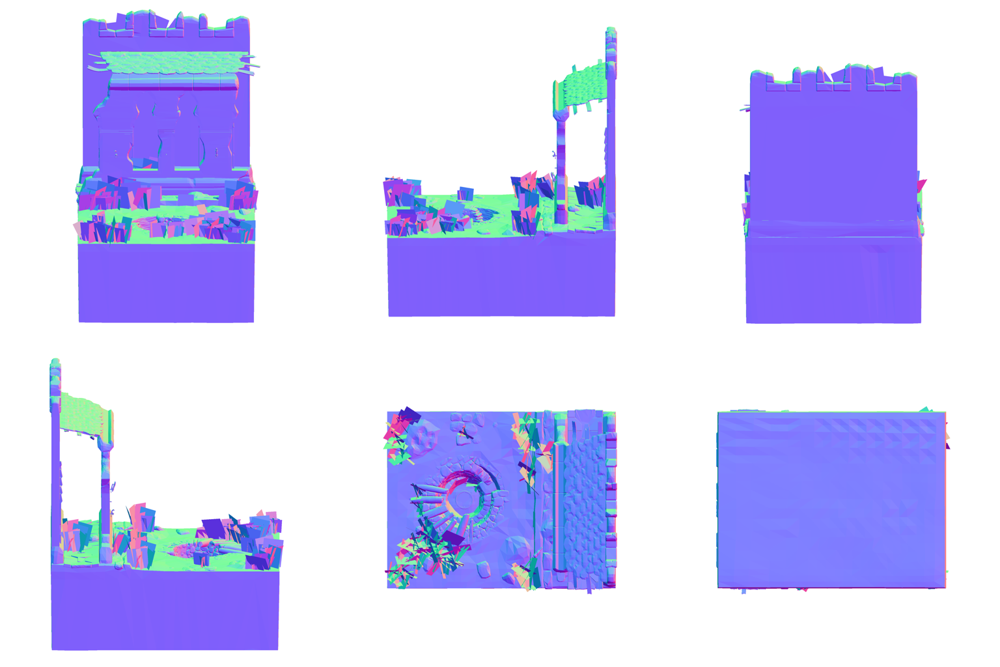

In [106]:
import plotly.graph_objects as go

display(
    fit_df.loc[
        fit_df["item_id"] == geometry_item_id,
        ["item_id"] + TARGET_COLUMNS,
    ]
)

with Image.open(
    TRAIN_DIR / f"{geometry_item_id}.png"
) as image:
    preview = image.convert("RGB")
    preview.thumbnail((1000, 700))
    display(preview)

points = surface_sample["points"]

figure = go.Figure(
    go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        customdata=surface_sample["face_ids"],
        marker={
            "size": 2,
            "color": points[:, 2],
            "colorscale": "Viridis",
            "opacity": 0.9,
        },
        hovertemplate=(
            "x: %{x:.3f}<br>"
            "y: %{y:.3f}<br>"
            "z: %{z:.3f}<br>"
            "Исходная грань: %{customdata}"
            "<extra></extra>"
        ),
    )
)

figure.update_layout(
    title=f"Точки поверхности | {geometry_item_id}",
    height=650,
    scene={
        "aspectmode": "cube",
        "xaxis": {"range": [-0.55, 0.55]},
        "yaxis": {"range": [-0.55, 0.55]},
        "zaxis": {"range": [-0.55, 0.55]},
    },
    margin={"l": 0, "r": 0, "b": 0, "t": 45},
)

figure.show()

### Тесты облак точек разной плотности

In [107]:
from time import perf_counter

DENSE_NUM_POINTS = 32768
POINT_COUNTS = [8192, 16384, 32768]

started_at = perf_counter()

dense_sample = sample_mesh_surface(
    npz_path=geometry_path,
    item_id=geometry_item_id,
    num_points=DENSE_NUM_POINTS,
    seed=SEED,
    face_chunk_size=FACE_CHUNK_SIZE,
)

print(f'''
Объект: {geometry_item_id}
Точек в плотном облаке: {DENSE_NUM_POINTS}
Время подготовки: {perf_counter() - started_at:.2f} с
''')


Объект: 0001be62-bf9c-4c15-8a09-dce209be9715
Точек в плотном облаке: 32768
Время подготовки: 0.02 с



In [108]:
subset_rng = np.random.default_rng(
    item_sampling_seed(
        geometry_item_id,
        SEED + 1000,
    )
)

point_order = subset_rng.permutation(DENSE_NUM_POINTS)

density_samples = {}
density_rows = []

for num_points in POINT_COUNTS:
    indices = point_order[:num_points]

    sample = {
        "points": dense_sample["points"][indices],
        "normals": dense_sample["normals"][indices],
        "face_ids": dense_sample["face_ids"][indices],
    }

    density_samples[num_points] = sample

    feature_bytes = (
        sample["points"].nbytes
        + sample["normals"].nbytes
    )

    density_rows.append({
        "num_points": num_points,
        "sampled_unique_faces": len(
            np.unique(sample["face_ids"])
        ),
        "features_MiB": feature_bytes / (1024 ** 2),
    })

density_report = pd.DataFrame(density_rows)

display(density_report.round(3))

assert np.array_equal(
    density_samples[8192]["points"],
    density_samples[16384]["points"][:8192],
)

assert np.array_equal(
    density_samples[16384]["points"],
    density_samples[32768]["points"][:16384],
)

,num_points,sampled_unique_faces,features_MiB
0,8192,4109,0.188
1,16384,6267,0.375
2,32768,9148,0.750


In [109]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

comparison_camera = {
    "eye": {
        "x": 1.5,
        "y": 1.5,
        "z": 1.0,
    },
    "up": {
        "x": 0,
        "y": 0,
        "z": 1,
    },
}

density_figure = make_subplots(
    rows=1,
    cols=3,
    specs=[[
        {"type": "scene"},
        {"type": "scene"},
        {"type": "scene"},
    ]],
    subplot_titles=[
        f"{count:,} точек"
        for count in POINT_COUNTS
    ],
)

for column, num_points in enumerate(POINT_COUNTS, start=1):
    points = density_samples[num_points]["points"]

    density_figure.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker={
                "size": 1.5,
                "color": points[:, 2],
                "colorscale": "Viridis",
                "cmin": -0.5,
                "cmax": 0.5,
                "opacity": 1.0,
            },
            showlegend=False,
            hovertemplate=(
                "x: %{x:.3f}<br>"
                "y: %{y:.3f}<br>"
                "z: %{z:.3f}"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=column,
    )

density_figure.update_scenes(
    camera=comparison_camera,
    aspectmode="cube",
    xaxis={"range": [-0.55, 0.55]},
    yaxis={"range": [-0.55, 0.55]},
    zaxis={"range": [-0.55, 0.55]},
)

density_figure.update_layout(
    title=f"Сравнение плотности | {geometry_item_id}",
    height=650,
    margin={"l": 0, "r": 0, "b": 0, "t": 70},
)

density_figure.show()

In [110]:
ROI_CENTER = np.array(
    [0.0, 0.0, -0.25],
    dtype=np.float32,
)

ROI_SIDE = 0.25
ROI_HALF_SIZE = ROI_SIDE / 2

roi_figure = make_subplots(
    rows=1,
    cols=3,
    specs=[[
        {"type": "scene"},
        {"type": "scene"},
        {"type": "scene"},
    ]],
    subplot_titles=[
        f"Исходное облако: {count:,}"
        for count in POINT_COUNTS
    ],
)

roi_counts = []

for column, num_points in enumerate(POINT_COUNTS, start=1):
    points = density_samples[num_points]["points"]

    roi_mask = (
        np.abs(points - ROI_CENTER) <= ROI_HALF_SIZE
    ).all(axis=1)

    roi_points = points[roi_mask]

    roi_counts.append({
        "total_points": num_points,
        "points_in_region": len(roi_points),
    })

    roi_figure.add_trace(
        go.Scatter3d(
            x=roi_points[:, 0],
            y=roi_points[:, 1],
            z=roi_points[:, 2],
            mode="markers",
            marker={
                "size": 2,
                "color": roi_points[:, 2],
                "colorscale": "Viridis",
                "cmin": -0.5,
                "cmax": 0.5,
            },
            showlegend=False,
        ),
        row=1,
        col=column,
    )

roi_figure.update_scenes(
    camera=comparison_camera,
    aspectmode="cube",
    xaxis={
        "range": [
            float(ROI_CENTER[0] - ROI_HALF_SIZE),
            float(ROI_CENTER[0] + ROI_HALF_SIZE),
        ]
    },
    yaxis={
        "range": [
            float(ROI_CENTER[1] - ROI_HALF_SIZE),
            float(ROI_CENTER[1] + ROI_HALF_SIZE),
        ]
    },
    zaxis={
        "range": [
            float(ROI_CENTER[2] - ROI_HALF_SIZE),
            float(ROI_CENTER[2] + ROI_HALF_SIZE),
        ]
    },
)

roi_figure.update_layout(
    title="Одна и та же локальная область",
    height=600,
    margin={"l": 0, "r": 0, "b": 0, "t": 70},
)

roi_figure.show()
display(pd.DataFrame(roi_counts))

,total_points,points_in_region
0,8192,259
1,16384,534
2,32768,1050


### Настройка кэша для хранения объектов

In [111]:
import json
import hashlib
import zipfile
from time import perf_counter

DENSE_NUM_POINTS = 32768

GEOMETRY_CONFIG = {
    "sampler_version": "surface_area_v1",
    "num_points": DENSE_NUM_POINTS,
    "seed": SEED,
    "face_chunk_size": FACE_CHUNK_SIZE,
    "dtype": "float32",
    "normalization": "referenced_vertices_bbox_max_extent",
    "normals": "face_normals_without_smoothing",
    "numpy_version": np.__version__,
}

geometry_config_text = json.dumps(
    GEOMETRY_CONFIG,
    sort_keys=True,
    ensure_ascii=False,
    indent=2,
)

GEOMETRY_CONFIG_HASH = hashlib.sha256(
    geometry_config_text.encode("utf-8")
).hexdigest()

GEOMETRY_CACHE_DIR = (
    OUTPUT_DIR
    / "geometry_cache"
    / f"surface_{DENSE_NUM_POINTS}_{GEOMETRY_CONFIG_HASH[:12]}"
)

for split_name in ["train", "test"]:
    (GEOMETRY_CACHE_DIR / split_name).mkdir(
        parents=True,
        exist_ok=True,
    )

(GEOMETRY_CACHE_DIR / "config.json").write_text(
    geometry_config_text,
    encoding="utf-8",
)

print(f'''
Точек на объект: {DENSE_NUM_POINTS}
Размер блока граней: {FACE_CHUNK_SIZE}

Папка кэша:
{GEOMETRY_CACHE_DIR}
''')


Точек на объект: 32768
Размер блока граней: 100000

Папка кэша:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/geometry_cache/surface_32768_03f72bbb541d



In [112]:
def file_sha256(path):
    with open(path, "rb") as file:
        return hashlib.file_digest(
            file,
            "sha256",
        ).hexdigest()


def validate_geometry_cache(path, item_id, source_hash):
    with np.load(path, allow_pickle=False) as data:
        if str(data["config_hash"].item()) != GEOMETRY_CONFIG_HASH:
            raise ValueError(
                "Изменились настройки подготовки."
            )

        if str(data["source_hash"].item()) != source_hash:
            raise ValueError(
                "Изменился исходный NPZ."
            )

        if str(data["item_id"].item()) != item_id:
            raise ValueError(
                "Не совпадает item_id."
            )

        points = data["points"]
        normals = data["normals"]
        face_ids = data["face_ids"]

        expected_shape = (
            GEOMETRY_CONFIG["num_points"],
            3,
        )

        if (
            points.shape != expected_shape
            or normals.shape != expected_shape
        ):
            raise ValueError(
                "Некорректная форма точек или нормалей."
            )

        if (
            points.dtype != np.float32
            or normals.dtype != np.float32
        ):
            raise ValueError(
                "Ожидается float32."
            )

        if (
            face_ids.shape != (expected_shape[0],)
            or not np.issubdtype(face_ids.dtype, np.integer)
        ):
            raise ValueError(
                "Некорректные индексы исходных граней."
            )

        num_faces = int(data["num_faces"].item())

        if (
            (face_ids < 0).any()
            or (face_ids >= num_faces).any()
        ):
            raise ValueError(
                "Индекс грани вне диапазона."
            )

        if (
            not np.isfinite(points).all()
            or not np.isfinite(normals).all()
        ):
            raise ValueError(
                "NaN/inf в признаках."
            )

        if np.abs(points).max() > 0.50001:
            raise ValueError(
                "Нарушена нормализация координат."
            )

        if not np.allclose(
            np.linalg.norm(normals, axis=1),
            1.0,
            atol=1e-5,
        ):
            raise ValueError(
                "Нормали не единичные."
            )

        center = data["center"]
        scale = float(data["scale"].item())

        if (
            center.shape != (3,)
            or not np.isfinite(center).all()
            or not np.isfinite(scale)
            or scale <= 0
        ):
            raise ValueError(
                "Некорректные параметры нормализации."
            )

        return {
            "num_vertices": int(data["num_vertices"].item()),
            "num_faces": num_faces,
            "zero_area_faces": int(
                data["zero_area_faces"].item()
            ),
            "scale": scale,
        }

In [113]:
def ensure_geometry_cache(
    item_id,
    source_path,
    cache_path,
):
    source_hash = file_sha256(source_path)
    rebuild_reason = ""

    if cache_path.exists():
        try:
            info = validate_geometry_cache(
                cache_path,
                item_id,
                source_hash,
            )

            return {
                "status": "cached",
                "source_hash": source_hash,
                **info,
            }

        except (
            ValueError,
            KeyError,
            OSError,
            EOFError,
            zipfile.BadZipFile,
        ) as error:
            rebuild_reason = (
                f"{type(error).__name__}: {error}"
            )

    sample = sample_mesh_surface(
        npz_path=source_path,
        item_id=item_id,
        num_points=GEOMETRY_CONFIG["num_points"],
        seed=GEOMETRY_CONFIG["seed"],
        face_chunk_size=GEOMETRY_CONFIG["face_chunk_size"],
    )

    temporary_path = cache_path.with_suffix(".npz.tmp")

    try:
        with open(temporary_path, "wb") as file:
            np.savez_compressed(
                file,
                **sample,
                source_hash=source_hash,
                config_hash=GEOMETRY_CONFIG_HASH,
            )

        info = validate_geometry_cache(
            temporary_path,
            item_id,
            source_hash,
        )

        temporary_path.replace(cache_path)

    finally:
        temporary_path.unlink(missing_ok=True)

    return {
        "status": "rebuilt" if rebuild_reason else "created",
        "source_hash": source_hash,
        "rebuild_reason": rebuild_reason,
        **info,
    }

### Обрабатываем все объекты

In [114]:
geometry_jobs = []

for split_name, dataframe, source_dir in [
    ("train", train_df, TRAIN_DIR),
    ("test", test_df, TEST_DIR),
]:
    for item_id in dataframe["item_id"]:
        geometry_jobs.append({
            "split": split_name,
            "item_id": item_id,
            "source_path": source_dir / f"{item_id}.npz",
            "cache_path": (
                GEOMETRY_CACHE_DIR
                / split_name
                / f"{item_id}.npz"
            ),
        })

GEOMETRY_REPORT_PATH = (
    GEOMETRY_CACHE_DIR / "processing_report.csv"
)

geometry_records = []
started_at = perf_counter()

try:
    for job in tqdm(
        geometry_jobs,
        desc="Подготовка геометрии",
    ):
        object_started_at = perf_counter()

        record = {
            "split": job["split"],
            "item_id": job["item_id"],
            "source_path": str(job["source_path"]),
            "cache_path": str(job["cache_path"]),
        }

        try:
            result = ensure_geometry_cache(
                item_id=job["item_id"],
                source_path=job["source_path"],
                cache_path=job["cache_path"],
            )

            record.update(result)

            record["cache_bytes"] = (
                job["cache_path"].stat().st_size
            )

        except (
            ValueError,
            IndexError,
            KeyError,
            EOFError,
            zipfile.BadZipFile,
            FileNotFoundError,
        ) as error:
            record.update({
                "status": "error",
                "error_type": type(error).__name__,
                "error": str(error),
            })

        record["seconds"] = (
            perf_counter() - object_started_at
        )

        geometry_records.append(record)

        if len(geometry_records) % 100 == 0:
            pd.DataFrame(geometry_records).to_csv(
                GEOMETRY_REPORT_PATH,
                index=False,
            )

finally:
    # Сохраняем накопленный отчёт также при прерывании.
    geometry_report = pd.DataFrame(geometry_records)

    geometry_report.to_csv(
        GEOMETRY_REPORT_PATH,
        index=False,
    )

print(f'''
Обработка завершена.
Время: {(perf_counter() - started_at) / 60:.2f} мин

Отчёт:
{GEOMETRY_REPORT_PATH}
''')

Подготовка геометрии:   0%|          | 0/9633 [00:00<?, ?it/s]


Обработка завершена.
Время: 0.73 мин

Отчёт:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/geometry_cache/surface_32768_03f72bbb541d/processing_report.csv



### Проверка покрытия

In [115]:
display(
    pd.crosstab(
        geometry_report["split"],
        geometry_report["status"],
    )
)

geometry_errors = geometry_report.loc[
    geometry_report["status"] == "error"
].copy()

successful_objects = geometry_report.loc[
    geometry_report["status"].isin(
        ["created", "cached", "rebuilt"]
    )
]

total_cache_bytes = (
    successful_objects["cache_bytes"].sum()
    if "cache_bytes" in successful_objects.columns
    else 0
)

print(f'''
Ожидалось объектов: {len(geometry_jobs)}
Обработано объектов: {len(geometry_report)}
Готовых объектов: {len(successful_objects)}
Ошибок подготовки: {len(geometry_errors)}

Размер готовых файлов:
{total_cache_bytes / (1024 ** 3):.2f} GiB
''')

if len(geometry_errors):
    display(
        geometry_errors[
            ["split", "item_id", "error_type", "error"]
        ].head(20)
    )

status,cached
split,
test,669
train,8964



Ожидалось объектов: 9633
Обработано объектов: 9633
Готовых объектов: 9633
Ошибок подготовки: 0

Размер готовых файлов:
5.60 GiB



## 13. Нейросетевая 3D-ветвь

Построим компактный encoder на основе PointNet++ для координат и нормалей. Разберём локальные соседства и иерархию признаков. Проверим переносимость операций на MPS и CUDA, а также зависимость результата от числа точек.

Добавляем Dataset для геометрии и загрузчики. Сейчас используем фиксированные 8192 точки: один объект получает одинаковое подмножество при каждом обращении.

In [116]:
class GeometryCacheDataset(Dataset):
    def __init__(
        self,
        dataframe,
        cache_dir,
        num_points=8192,
        subset_seed=42,
        target_columns=None,
    ):
        self.cache_dir = Path(cache_dir)
        self.num_points = num_points
        self.subset_seed = subset_seed

        self.item_ids = (
            dataframe["item_id"].astype(str).tolist()
        )

        if len(set(self.item_ids)) != len(self.item_ids):
            raise ValueError(
                "Повторяющиеся item_id."
            )

        config_path = self.cache_dir.parent / "config.json"

        cache_config = json.loads(
            config_path.read_text(encoding="utf-8")
        )

        self.dense_num_points = int(
            cache_config["num_points"]
        )

        config_text = json.dumps(
            cache_config,
            sort_keys=True,
            ensure_ascii=False,
            indent=2,
        )

        self.config_hash = hashlib.sha256(
            config_text.encode("utf-8")
        ).hexdigest()

        if not 0 < num_points <= self.dense_num_points:
            raise ValueError(
                "Запрошенное число точек вне диапазона кэша."
            )

        self.targets = (
            dataframe[list(target_columns)].to_numpy(
                dtype=np.float32,
                copy=True,
            )
            if target_columns is not None
            else None
        )

    def __len__(self):
        return len(self.item_ids)

    def __getitem__(self, index):
        item_id = self.item_ids[index]
        cache_path = self.cache_dir / f"{item_id}.npz"

        with np.load(
            cache_path,
            allow_pickle=False,
        ) as data:
            if (
                str(data["item_id"].item()) != item_id
                or str(data["config_hash"].item()) != self.config_hash
            ):
                raise ValueError(
                    f"Не совпадают метаданные кэша: {item_id}"
                )

            points = data["points"]
            normals = data["normals"]
            face_ids = data["face_ids"]

        if (
            points.shape != (self.dense_num_points, 3)
            or normals.shape != points.shape
            or face_ids.shape != (self.dense_num_points,)
        ):
            raise ValueError(
                f"Некорректная форма кэша: {item_id}"
            )

        if (
            points.dtype != np.float32
            or normals.dtype != np.float32
        ):
            raise ValueError(
                f"Ожидаются признаки float32: {item_id}"
            )

        # Число выбранных точек не входит в seed.
        # Поэтому меньшие подмножества вложены в большие.
        rng = np.random.default_rng(
            item_sampling_seed(
                item_id,
                self.subset_seed + 1000,
            )
        )

        indices = rng.permutation(
            self.dense_num_points
        )[:self.num_points]

        features = np.concatenate(
            [
                points[indices],
                normals[indices],
            ],
            axis=1,
        )

        sample = {
            "item_id": item_id,
            "features": torch.from_numpy(features),
            "point_indices": torch.from_numpy(
                indices.astype(np.int64, copy=False)
            ),
            "face_ids": torch.from_numpy(
                face_ids[indices].astype(np.int64, copy=False)
            ),
        }

        if self.targets is not None:
            sample["targets"] = torch.from_numpy(
                self.targets[index].copy()
            )

        return sample

In [117]:
GEOMETRY_NUM_POINTS = 8192
GEOMETRY_BATCH_SIZE = 4
GEOMETRY_NUM_WORKERS = 0

geometry_inner_train_df = (
    search_df
    .iloc[inner_train_indices]
    .reset_index()
)

geometry_inner_valid_df = (
    search_df
    .iloc[inner_valid_indices]
    .reset_index()
)

assert np.array_equal(
    geometry_inner_train_df[TARGET_COLUMNS].to_numpy(),
    train_cache["targets"].numpy()[inner_train_indices],
)

assert np.array_equal(
    geometry_inner_valid_df[TARGET_COLUMNS].to_numpy(),
    train_cache["targets"].numpy()[inner_valid_indices],
)

assert set(
    geometry_inner_train_df["group_id"]
).isdisjoint(
    set(geometry_inner_valid_df["group_id"])
)

dataset_specs = {
    "inner_train": (
        geometry_inner_train_df,
        "train",
        TARGET_COLUMNS,
    ),
    "inner_valid": (
        geometry_inner_valid_df,
        "train",
        TARGET_COLUMNS,
    ),
    "full_train": (
        fit_df,
        "train",
        TARGET_COLUMNS,
    ),
    "outer_valid": (
        valid_df,
        "train",
        TARGET_COLUMNS,
    ),
    "test": (
        test_df,
        "test",
        None,
    ),
}

geometry_datasets = {}

for name, (dataframe, folder, targets) in dataset_specs.items():
    geometry_datasets[name] = GeometryCacheDataset(
        dataframe=dataframe,
        cache_dir=GEOMETRY_CACHE_DIR / folder,
        num_points=GEOMETRY_NUM_POINTS,
        subset_seed=SEED,
        target_columns=targets,
    )

display(
    pd.DataFrame([
        {
            "dataset": name,
            "objects": len(dataset),
            "points_per_object": dataset.num_points,
        }
        for name, dataset in geometry_datasets.items()
    ])
)

,dataset,objects,points_per_object
0,inner_train,4775,8192
1,inner_valid,1195,8192
2,full_train,5970,8192
3,outer_valid,2994,8192
4,test,669,8192


### Тесты проверяемости

In [118]:
geometry_sample = geometry_datasets["inner_train"][0]
repeated_geometry_sample = geometry_datasets["inner_train"][0]

for field in [
    "features",
    "point_indices",
    "face_ids",
    "targets",
]:
    assert torch.equal(
        geometry_sample[field],
        repeated_geometry_sample[field],
    )

geometry_dataset_16k = GeometryCacheDataset(
    dataframe=geometry_inner_train_df,
    cache_dir=GEOMETRY_CACHE_DIR / "train",
    num_points=16384,
    subset_seed=SEED,
    target_columns=TARGET_COLUMNS,
)

geometry_sample_16k = geometry_dataset_16k[0]

for field in ["features", "point_indices", "face_ids"]:
    assert torch.equal(
        geometry_sample[field],
        geometry_sample_16k[field][:GEOMETRY_NUM_POINTS],
    )

assert (
    torch.unique(geometry_sample["point_indices"]).numel()
    == GEOMETRY_NUM_POINTS
)

assert geometry_sample["features"].shape == (
    GEOMETRY_NUM_POINTS,
    6,
)

assert geometry_sample["targets"].shape == (NUM_TARGETS,)

print(f'''
item_id: {geometry_sample["item_id"]}
Форма признаков: {tuple(geometry_sample["features"].shape)}

Повторное чтение даёт те же данные.
8192 точки входят в начало подмножества из 16384 точек.
Повторяющихся индексов выбранных точек нет.
''')


item_id: 0001be62-bf9c-4c15-8a09-dce209be9715
Форма признаков: (8192, 6)

Повторное чтение даёт те же данные.
8192 точки входят в начало подмножества из 16384 точек.
Повторяющихся индексов выбранных точек нет.



### Создвние загрузчиков

In [119]:
geometry_train_loader = DataLoader(
    geometry_datasets["inner_train"],
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=True,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED),
)

geometry_valid_loader = DataLoader(
    geometry_datasets["inner_valid"],
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=False,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED + 1),
)

# Отдельный loader для проверок — не меняем порядок обучения.
geometry_preview_loader = DataLoader(
    geometry_datasets["inner_train"],
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)

geometry_batch = next(iter(geometry_preview_loader))

actual_batch_size = len(geometry_batch["item_id"])

assert geometry_batch["features"].shape == (
    actual_batch_size,
    GEOMETRY_NUM_POINTS,
    6,
)

assert geometry_batch["targets"].shape == (
    actual_batch_size,
    NUM_TARGETS,
)

assert torch.isfinite(geometry_batch["features"]).all().item()

torch.testing.assert_close(
    geometry_batch["features"][:, :, 3:].norm(dim=-1),
    torch.ones(actual_batch_size, GEOMETRY_NUM_POINTS),
    rtol=1e-4,
    atol=1e-5,
)

print(f'''
Объектов в batch: {actual_batch_size}

Признаки: {tuple(geometry_batch["features"].shape)}
Метки: {tuple(geometry_batch["targets"].shape)}
Индексы граней: {tuple(geometry_batch["face_ids"].shape)}

Тип признаков: {geometry_batch["features"].dtype}
Устройство: {geometry_batch["features"].device}
''')


Объектов в batch: 4

Признаки: (4, 8192, 6)
Метки: (4, 11)
Индексы граней: (4, 8192)

Тип признаков: torch.float32
Устройство: cpu



In [120]:
from itertools import islice
from time import perf_counter

BENCHMARK_BATCHES = 30

loaded_objects = 0
loaded_batches = 0

started_at = perf_counter()

for batch in islice(
    geometry_preview_loader,
    BENCHMARK_BATCHES,
):
    loaded_objects += len(batch["item_id"])
    loaded_batches += 1

elapsed_seconds = perf_counter() - started_at

print(f'''
Прочитано объектов: {loaded_objects}
Прочитано batch: {loaded_batches}

Общее время: {elapsed_seconds:.3f} с
Среднее время batch: {elapsed_seconds / loaded_batches:.4f} с
Скорость: {loaded_objects / elapsed_seconds:.1f} объектов/с
''')


Прочитано объектов: 120
Прочитано batch: 30

Общее время: 0.341 с
Среднее время batch: 0.0114 с
Скорость: 352.1 объектов/с



```
8192 точки: координаты + нормали
    ↓ локальные группы вокруг 512 опорных точек
512 локальных признаков
    ↓ локальные группы вокруг 128 опорных точек
128 признаков более крупных областей
    ↓ объединение признаков объекта
10 logits дефектов
```

### Поиск соседей блоками

In [121]:
@torch.no_grad()
def chunked_knn(
    xyz,
    queries,
    k,
    chunk_size=64,
):
    if not 1 <= k <= xyz.shape[1] or chunk_size < 1:
        raise ValueError(
            "Некорректные k или chunk_size."
        )

    source_norm = (
        xyz.square()
        .sum(dim=-1)
        .unsqueeze(1)
    )

    source_transposed = xyz.transpose(1, 2)

    index_blocks = []

    for start in range(0, queries.shape[1], chunk_size):
        query_block = queries[
            :,
            start:start + chunk_size,
        ]

        # Квадраты евклидовых расстояний:
        # ||q - x||² = ||q||² + ||x||² - 2(q · x).
        distances = (
            query_block.square().sum(
                dim=-1,
                keepdim=True,
            )
            + source_norm
            - 2 * torch.bmm(
                query_block,
                source_transposed,
            )
        )

        distances.clamp_min_(0)

        indices = distances.topk(
            k,
            dim=-1,
            largest=False,
            sorted=False,
        ).indices

        index_blocks.append(indices)

    return torch.cat(index_blocks, dim=1)

### Блок обработки локальных групп

Внутри каждой группы используется:
- координаты соседей относительно центра
- признаки соседей
- общий MLP
- максимум по соседям для получения одного вектора группы

На первом уровне признаки соседей — нормали. На втором — выход первого уровня.

In [122]:
class LocalGroupingBlock(nn.Module):
    def __init__(
        self,
        input_dim,
        num_centers,
        neighbors,
        hidden_dim,
        output_dim,
        chunk_size=64,
    ):
        super().__init__()

        self.num_centers = num_centers
        self.neighbors = neighbors
        self.chunk_size = chunk_size

        self.local_mlp = nn.Sequential(
            nn.Linear(input_dim + 3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
        )

    def forward(self, xyz, features):
        if xyz.shape[1] < self.num_centers:
            raise ValueError(
                "Недостаточно точек для выбранного числа центров."
            )

        centers = xyz[:, :self.num_centers]

        indices = chunked_knn(
            xyz=xyz,
            queries=centers,
            k=self.neighbors,
            chunk_size=self.chunk_size,
        )

        batch_indices = torch.arange(
            xyz.shape[0],
            device=xyz.device,
        )[:, None, None]

        neighbor_xyz = xyz[
            batch_indices,
            indices,
        ]

        neighbor_features = features[
            batch_indices,
            indices,
        ]

        relative_xyz = (
            neighbor_xyz - centers.unsqueeze(2)
        )

        local_inputs = torch.cat(
            [
                relative_xyz,
                neighbor_features,
            ],
            dim=-1,
        )

        local_features = self.local_mlp(
            local_inputs
        ).amax(dim=2)

        return centers, local_features

### Полная модель

Координаты центров добавляем перед глобальным объединением, чтобы сохранить информацию о расположении локальных признаков внутри объекта.

In [123]:
class LocalGeometryClassifier(nn.Module):
    def __init__(
        self,
        num_defects,
        centers=(512, 128),
        neighbors=(32, 32),
        chunk_size=64,
        dropout=0.2,
    ):
        super().__init__()

        self.stage1 = LocalGroupingBlock(
            input_dim=3,
            num_centers=centers[0],
            neighbors=neighbors[0],
            hidden_dim=64,
            output_dim=96,
            chunk_size=chunk_size,
        )

        self.stage2 = LocalGroupingBlock(
            input_dim=96,
            num_centers=centers[1],
            neighbors=neighbors[1],
            hidden_dim=128,
            output_dim=192,
            chunk_size=chunk_size,
        )

        self.global_projection = nn.Sequential(
            nn.Linear(192 + 3, 256),
            nn.LayerNorm(256),
            nn.GELU(),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_defects),
        )

    def forward(self, inputs):
        if inputs.ndim != 3 or inputs.shape[-1] != 6:
            raise ValueError(
                "Ожидается [batch, points, 6]."
            )

        xyz = inputs[..., :3]
        normals = inputs[..., 3:]

        xyz1, features1 = self.stage1(xyz, normals)

        xyz2, features2 = self.stage2(xyz1, features1)

        object_tokens = self.global_projection(
            torch.cat(
                [xyz2, features2],
                dim=-1,
            )
        )

        pooled = torch.cat(
            [
                object_tokens.mean(dim=1),
                object_tokens.amax(dim=1),
            ],
            dim=-1,
        )

        return self.classifier(pooled)

### Проверка прямого прохода

In [124]:
torch.manual_seed(SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(SEED)

geometry_probe = LocalGeometryClassifier(num_defects=NUM_DEFECTS,).to(DEVICE)

probe_batch = next(iter(geometry_preview_loader))

probe_features = probe_batch["features"].to(DEVICE)
probe_targets = probe_batch["targets"].to(DEVICE)

geometry_probe.eval()

with torch.no_grad():
    probe_logits = geometry_probe(probe_features)
    probe_loss = compute_loss(
        probe_logits,
        probe_targets,
    )

assert probe_logits.shape == (
    probe_features.shape[0],
    NUM_DEFECTS,
)

assert torch.isfinite(probe_logits).all().item()
assert torch.isfinite(probe_loss).item()

print(f'''
Устройство: {DEVICE}

Вход: {tuple(probe_features.shape)}
Выход: {tuple(probe_logits.shape)}

Начальный loss: {probe_loss.item():.4f}
Параметров: {sum(p.numel() for p in geometry_probe.parameters()):,}
''')


Устройство: mps

Вход: (4, 8192, 6)
Выход: (4, 10)

Начальный loss: 0.6892
Параметров: 230,826



### Проверка обучения и измерение времени шага

Два первых шага используем для прогрева, следующие пять — для замера. Повторно обрабатываем один batch, поэтому этот тест проверяет вычисления и скорость, а не качество обучения.

In [125]:
def synchronize_geometry_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


probe_optimizer = torch.optim.AdamW(
    geometry_probe.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

WARMUP_STEPS = 2
MEASURE_STEPS = 5

step_times = []
probe_losses = []

geometry_probe.train()

for step in range(WARMUP_STEPS + MEASURE_STEPS):
    synchronize_geometry_device(DEVICE)
    started_at = perf_counter()

    probe_optimizer.zero_grad(set_to_none=True)

    logits = geometry_probe(probe_features)

    loss = compute_loss(
        logits,
        probe_targets,
    )

    if not torch.isfinite(loss).item():
        raise ValueError(
            "Loss стал NaN или бесконечностью."
        )

    loss.backward()

    nn.utils.clip_grad_norm_(
        geometry_probe.parameters(),
        max_norm=1.0,
        error_if_nonfinite=True,
    )

    probe_optimizer.step()

    synchronize_geometry_device(DEVICE)
    step_seconds = perf_counter() - started_at

    probe_losses.append(loss.item())

    if step >= WARMUP_STEPS:
        step_times.append(step_seconds)

for name, parameter in geometry_probe.named_parameters():
    assert parameter.grad is not None, name
    assert torch.isfinite(parameter.grad).all().item(), name

mean_step_seconds = float(np.mean(step_times))

print(f'''
Проверка градиентов пройдена.

Loss первого шага: {probe_losses[0]:.4f}
Loss последнего шага: {probe_losses[-1]:.4f}

Среднее время шага: {mean_step_seconds:.4f} с
Минимальное время шага: {min(step_times):.4f} с
Максимальное время шага: {max(step_times):.4f} с

Объектов в batch: {probe_features.shape[0]}
''')


Проверка градиентов пройдена.

Loss первого шага: 0.6829
Loss последнего шага: 0.1130

Среднее время шага: 0.0145 с
Минимальное время шага: 0.0141 с
Максимальное время шага: 0.0155 с

Объектов в batch: 4



In [126]:
from datetime import datetime
from time import perf_counter

GEOMETRY_SEED = 42
GEOMETRY_EPOCHS = 30
GEOMETRY_LR = 1e-3
GEOMETRY_WEIGHT_DECAY = 1e-2

geometry_thresholds = np.full(
    NUM_DEFECTS,
    0.5,
    dtype=np.float64,
)

geometry_model_config = {
    "num_defects": NUM_DEFECTS,
    "centers": (512, 128),
    "neighbors": (32, 32),
    "chunk_size": 64,
    "dropout": 0.2,
}

GEOMETRY_RUN_DIR = CHECKPOINT_DIR / datetime.now().strftime(
    "geometry_weighted_ap_%Y%m%d_%H%M%S_%f"
)
GEOMETRY_RUN_DIR.mkdir(parents=True, exist_ok=False)

random.seed(GEOMETRY_SEED)
np.random.seed(GEOMETRY_SEED)
torch.manual_seed(GEOMETRY_SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(GEOMETRY_SEED)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(GEOMETRY_SEED)

geometry_model = LocalGeometryClassifier(
    **geometry_model_config
).to(DEVICE)

geometry_optimizer = torch.optim.AdamW(
    geometry_model.parameters(),
    lr=GEOMETRY_LR,
    weight_decay=GEOMETRY_WEIGHT_DECAY,
)

# Создаём загрузчики заново для воспроизводимого порядка.
geometry_train_loader = DataLoader(
    geometry_datasets["inner_train"],
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=True,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(GEOMETRY_SEED),
)

geometry_valid_loader = DataLoader(
    geometry_datasets["inner_valid"],
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=False,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(GEOMETRY_SEED + 1),
)

print(f'''
Устройство: {DEVICE}
Точек на объект: {geometry_datasets["inner_train"].num_points}

Обучающих объектов: {len(geometry_datasets["inner_train"])}
Проверочных объектов: {len(geometry_datasets["inner_valid"])}

Эпох: {GEOMETRY_EPOCHS}
Batch size: {GEOMETRY_BATCH_SIZE}

Критерий выбора checkpoint: weighted AP
Конкурсная метрика в журнале: f1_final
Пороги: 0.5 для всех дефектов

Папка эксперимента: {GEOMETRY_RUN_DIR}
''')


Устройство: mps
Точек на объект: 8192

Обучающих объектов: 4775
Проверочных объектов: 1195

Эпох: 30
Batch size: 4

Критерий выбора checkpoint: weighted AP
Конкурсная метрика в журнале: f1_final
Пороги: 0.5 для всех дефектов

Папка эксперимента: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/geometry_weighted_ap_20260917_122342_660574



### Валидация: weighted AP для выбора checkpoint, F1 для отчёта


In [127]:
from sklearn.metrics import average_precision_score

@torch.no_grad()
def evaluate_geometry_contest(
    model,
    loader,
    device,
    thresholds=0.5,
):
    model.eval()

    loss_sum = 0.0
    object_count = 0

    target_batches = []
    probability_batches = []
    item_ids = []

    for batch in loader:
        features = batch["features"].to(device)
        targets = batch["targets"].to(device)

        logits = model(features)
        loss = compute_loss(logits, targets)

        if not torch.isfinite(loss).item():
            raise ValueError(
                "Validation loss стал NaN или бесконечностью."
            )

        batch_size = features.shape[0]

        loss_sum += loss.item() * batch_size
        object_count += batch_size

        target_batches.append(
            targets.cpu().numpy()
        )

        probability_batches.append(
            torch.sigmoid(logits).cpu().numpy()
        )

        item_ids.extend(batch["item_id"])

    if object_count == 0:
        raise ValueError(
            "Пустая валидационная выборка."
        )

    targets = np.concatenate(
        target_batches,
        axis=0,
    )

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    metrics = {
        "valid_loss": loss_sum / object_count,
        **calculate_metrics(
            targets,
            probabilities,
            thresholds=thresholds,
        ),
    }

    return metrics, targets, probabilities, item_ids

### Обучение модели

In [128]:
geometry_history = []

best_geometry_score = -float("inf")
best_geometry_epoch = None

geometry_training_config = {
    "seed": GEOMETRY_SEED,
    "max_epochs": GEOMETRY_EPOCHS,
    "learning_rate": GEOMETRY_LR,
    "weight_decay": GEOMETRY_WEIGHT_DECAY,
    "batch_size": GEOMETRY_BATCH_SIZE,
    "num_points": geometry_datasets["inner_train"].num_points,
    "subset_seed": geometry_datasets["inner_train"].subset_seed,
    "geometry_cache_hash": geometry_datasets["inner_train"].config_hash,
    "thresholds": geometry_thresholds.tolist(),
    "selection_metric": SELECTION_METRIC,
}

for epoch in range(1, GEOMETRY_EPOCHS + 1):
    started_at = perf_counter()

    train_loss = train_cached_epoch(
        geometry_model,
        geometry_train_loader,
        geometry_optimizer,
        DEVICE,
    )

    metrics, targets, probabilities, item_ids = (
        evaluate_geometry_contest(
            model=geometry_model,
            loader=geometry_valid_loader,
            device=DEVICE,
            thresholds=geometry_thresholds,
        )
    )

    epoch_seconds = perf_counter() - started_at

    geometry_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        **metrics,
        "seconds": epoch_seconds,
    })

    pd.DataFrame(geometry_history).to_csv(
        GEOMETRY_RUN_DIR / "history.csv",
        index=False,
    )

    current_score = metrics[SELECTION_METRIC]
    is_best = current_score > best_geometry_score

    if is_best:
        best_geometry_score = current_score
        best_geometry_epoch = epoch

        torch.save(
            {
                "architecture": "local_geometry_v1",
                "model_state_dict": {
                    name: tensor.detach().cpu()
                    for name, tensor in geometry_model.state_dict().items()
                },
                "model_config": geometry_model_config,
                "training_config": geometry_training_config,
                "epoch": epoch,
                "metrics": dict(metrics),
                "defect_columns": list(DEFECT_COLUMNS),
                "target_columns": list(TARGET_COLUMNS),
                "geometry_cache_config": GEOMETRY_CONFIG,
                "train_item_ids": (
                    geometry_datasets["inner_train"].item_ids
                ),
                "valid_item_ids": (
                    geometry_datasets["inner_valid"].item_ids
                ),
            },
            GEOMETRY_RUN_DIR / "best_model.pt",
        )

        np.savez_compressed(
            GEOMETRY_RUN_DIR / "best_validation_predictions.npz",
            item_ids=np.asarray(item_ids, dtype=str),
            targets=targets,
            probabilities=probabilities,
            thresholds=geometry_thresholds,
        )

    checkpoint_message = (
        "Сохранён новый лучший checkpoint."
        if is_best
        else "Лучший checkpoint не изменился."
    )

    print(f'''
Эпоха: {epoch}/{GEOMETRY_EPOCHS}

Train loss: {train_loss:.4f}
Validation loss: {metrics["valid_loss"]:.4f}

F1 качества: {metrics["f1_quality"]:.4f}
Взвешенный F1 дефектов: {metrics["f1_defects_weighted"]:.4f}
Конкурсная метрика: {metrics["f1_final"]:.4f}

Weighted AP: {metrics["weighted_ap"]:.4f}
Время обучения и валидации: {epoch_seconds:.2f} с

{checkpoint_message}
''')

geometry_history_df = pd.DataFrame(geometry_history)

print(f'''
Обучение завершено.

Лучшая эпоха по weighted AP: {best_geometry_epoch}
Лучший weighted AP: {best_geometry_score:.6f}

Checkpoint:
{GEOMETRY_RUN_DIR / "best_model.pt"}
''')


Эпоха: 1/30

Train loss: 0.2772
Validation loss: 0.2554

F1 качества: 0.3137
Взвешенный F1 дефектов: 0.2903
Конкурсная метрика: 6.0393

Weighted AP: 0.4429
Время обучения и валидации: 40.61 с

Сохранён новый лучший checkpoint.


Эпоха: 2/30

Train loss: 0.2540
Validation loss: 0.2409

F1 качества: 0.3456
Взвешенный F1 дефектов: 0.3218
Конкурсная метрика: 6.6734

Weighted AP: 0.4717
Время обучения и валидации: 40.00 с

Сохранён новый лучший checkpoint.


Эпоха: 3/30

Train loss: 0.2453
Validation loss: 0.2275

F1 качества: 0.3273
Взвешенный F1 дефектов: 0.3060
Конкурсная метрика: 6.3335

Weighted AP: 0.5039
Время обучения и валидации: 40.19 с

Сохранён новый лучший checkpoint.


Эпоха: 4/30

Train loss: 0.2373
Validation loss: 0.2413

F1 качества: 0.3320
Взвешенный F1 дефектов: 0.3308
Конкурсная метрика: 6.6273

Weighted AP: 0.4869
Время обучения и валидации: 40.42 с

Лучший checkpoint не изменился.


Эпоха: 5/30

Train loss: 0.2340
Validation loss: 0.2245

F1 качества: 0.3670
Взвешенн

### Кривые обучения

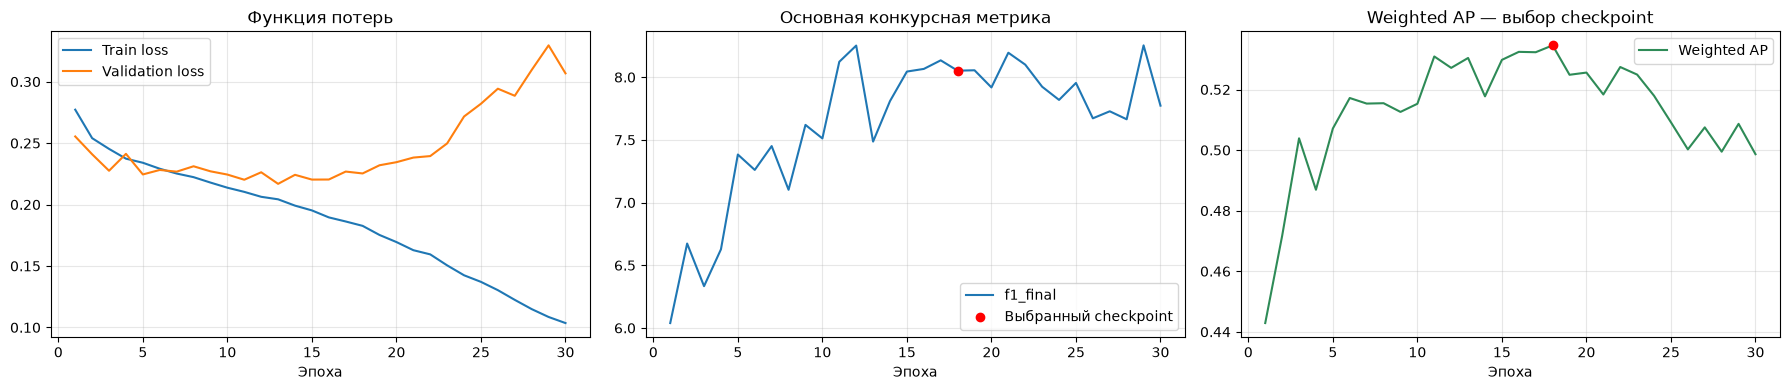

In [129]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 4),
)

epochs = geometry_history_df["epoch"]

axes[0].plot(
    epochs,
    geometry_history_df["train_loss"],
    label="Train loss",
)
axes[0].plot(
    epochs,
    geometry_history_df["valid_loss"],
    label="Validation loss",
)
axes[0].set_title("Функция потерь")

axes[1].plot(
    epochs,
    geometry_history_df["f1_final"],
    label="f1_final",
)
axes[1].scatter(
    best_geometry_epoch,
    geometry_history_df.set_index("epoch").loc[best_geometry_epoch, "f1_final"],
    color="red",
    label="Выбранный checkpoint",
    zorder=5,
)
axes[1].set_title("Основная конкурсная метрика")

axes[2].plot(
    epochs,
    geometry_history_df["weighted_ap"],
    label="Weighted AP",
    color="seagreen",
)
axes[2].set_title("Weighted AP — выбор checkpoint")
axes[2].scatter(best_geometry_epoch, best_geometry_score, color="red", zorder=5)

for ax in axes:
    ax.set_xlabel("Эпоха")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()

fig.savefig(
    GEOMETRY_RUN_DIR / "learning_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [130]:
best_geometry_checkpoint = torch.load(
    GEOMETRY_RUN_DIR / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

geometry_model.load_state_dict(
    best_geometry_checkpoint["model_state_dict"],
    strict=True,
)

geometry_model.eval()

display(
    pd.DataFrame([
        {
            "epoch": best_geometry_checkpoint["epoch"],
            **best_geometry_checkpoint["metrics"],
        }
    ]).round(6)
)

,epoch,valid_loss,f1_quality,f1_defects_weighted,f1_final,weighted_ap
0,18,0.225308,0.37047,0.434718,8.051882,0.534582


### Калибрация

In [131]:
geometry_checkpoint = torch.load(
    GEOMETRY_RUN_DIR / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

geometry_model.load_state_dict(
    geometry_checkpoint["model_state_dict"],
    strict=True,
)
geometry_model.to(DEVICE)
geometry_model.eval()

outer_geometry_dataset = geometry_datasets["outer_valid"]

assert (
    outer_geometry_dataset.num_points
    == geometry_checkpoint["training_config"]["num_points"]
)
assert (
    outer_geometry_dataset.subset_seed
    == geometry_checkpoint["training_config"]["subset_seed"]
)
assert (
    outer_geometry_dataset.config_hash
    == geometry_checkpoint["training_config"]["geometry_cache_hash"]
)

assert set(
    geometry_checkpoint["train_item_ids"]
).isdisjoint(
    set(outer_geometry_dataset.item_ids)
)

print(f'''
Загружена эпоха: {geometry_checkpoint["epoch"]}
Точек на объект: {outer_geometry_dataset.num_points}

Объектов внешней валидации: {len(outer_geometry_dataset)}
Пересечений с обучающими объектами нет.
''')


Загружена эпоха: 18
Точек на объект: 8192

Объектов внешней валидации: 2994
Пересечений с обучающими объектами нет.



### Вероятности

In [132]:
geometry_outer_loader = DataLoader(
    outer_geometry_dataset,
    batch_size=GEOMETRY_BATCH_SIZE,
    shuffle=False,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED + 2),
)

(
    _,
    geometry_outer_targets,
    geometry_outer_probabilities,
    geometry_outer_ids,
) = evaluate_geometry_contest(
    model=geometry_model,
    loader=geometry_outer_loader,
    device=DEVICE,
    thresholds=0.5,
)

In [133]:
geometry_outer_index = pd.Index(
    geometry_outer_ids,
    name="item_id",
)

assert geometry_outer_index.is_unique
assert set(geometry_outer_index) == set(threshold_df.index)

geometry_outer_table = threshold_df.loc[
    geometry_outer_index
]

assert np.array_equal(
    geometry_outer_table[TARGET_COLUMNS].to_numpy(),
    geometry_outer_targets,
)

geometry_calibration_mask = (
    geometry_outer_table["group_id"]
    .isin(calibration_groups)
    .to_numpy()
)

geometry_check_mask = (
    geometry_outer_table["group_id"]
    .isin(check_groups)
    .to_numpy()
)

assert not (
    geometry_calibration_mask & geometry_check_mask
).any()

assert (
    geometry_calibration_mask | geometry_check_mask
).all()

assert geometry_calibration_mask.any()
assert geometry_check_mask.any()

print(f'''
Объектов calibration: {geometry_calibration_mask.sum()}
Объектов check: {geometry_check_mask.sum()}
''')


Объектов calibration: 1496
Объектов check: 1498



### Подбор порогов

In [134]:
geometry_tuned_thresholds, geometry_threshold_history = (
    tune_class_thresholds(
        targets=geometry_outer_targets[
            geometry_calibration_mask
        ],
        probabilities=geometry_outer_probabilities[
            geometry_calibration_mask
        ],
        initial_thresholds=np.full(NUM_DEFECTS, 0.5),
        max_passes=5,
    )
)

geometry_threshold_table = pd.DataFrame(
    {
        "initial": np.full(NUM_DEFECTS, 0.5),
        "geometry_tuned": geometry_tuned_thresholds,
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

display(geometry_threshold_table.round(4))

Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 9.442038



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 9.537828



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 3
Метрика на calibration: 9.537841



Проход 4:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 4
Метрика на calibration: 9.537841



,initial,geometry_tuned
defect,,
abstract,0.5,0.2000
artifacts,0.5,0.0900
intersection,0.5,0.0300
lowpoly,0.5,0.4700
noisy,0.5,0.1700
open,0.5,0.0825
partial,0.5,0.3600
scale,0.5,0.0700
set,0.5,0.2600


### Сравниение с baseline

In [135]:
baseline_probability_table = pd.DataFrame(
    baseline_full_probabilities,
    index=pd.Index(valid_cache["item_ids"], name="item_id"),
    columns=DEFECT_COLUMNS,
)

assert baseline_probability_table.index.is_unique

aligned_baseline_probabilities = (
    baseline_probability_table
    .loc[geometry_outer_index]
    .to_numpy()
)

comparison_variants = [
    (
        "image_baseline_tuned",
        aligned_baseline_probabilities,
        baseline_thresholds,
    ),
    (
        "geometry_0.5",
        geometry_outer_probabilities,
        np.full(NUM_DEFECTS, 0.5),
    ),
    (
        "geometry_tuned",
        geometry_outer_probabilities,
        geometry_tuned_thresholds,
    ),
]

geometry_comparison_rows = []

for split_name, mask in [
    ("calibration", geometry_calibration_mask),
    ("check", geometry_check_mask),
]:
    for variant, probabilities, thresholds in comparison_variants:
        metrics = calculate_metrics(
            geometry_outer_targets[mask],
            probabilities[mask],
            thresholds=thresholds,
        )

        geometry_comparison_rows.append({
            "split": split_name,
            "variant": variant,
            **metrics,
        })

geometry_comparison = (
    pd.DataFrame(geometry_comparison_rows)
    .set_index(["split", "variant"])
)

display(geometry_comparison.round(6))

geometry_threshold_gain = (
    geometry_comparison.loc[
        ("check", "geometry_tuned"), "f1_final"
    ]
    - geometry_comparison.loc[
        ("check", "geometry_0.5"), "f1_final"
    ]
)

geometry_vs_image = (
    geometry_comparison.loc[
        ("check", "geometry_tuned"), "f1_final"
    ]
    - geometry_comparison.loc[
        ("check", "image_baseline_tuned"), "f1_final"
    ]
)

print(f'''
Прирост 3D-модели после настройки порогов на check:
{geometry_threshold_gain:+.6f}

Разница настроенной 3D-модели и визуального baseline на check:
{geometry_vs_image:+.6f}
''')

f1_quality  f1_defects_weighted   f1_final  \
split       variant                                                            
calibration image_baseline_tuned    0.635789             0.642650  12.784398   
            geometry_0.5            0.372340             0.427087   7.994271   
            geometry_tuned          0.448898             0.504886   9.537841   
check       image_baseline_tuned    0.566038             0.617459  11.834962   
            geometry_0.5            0.376682             0.416927   7.936085   
            geometry_tuned          0.408247             0.479361   8.876089   

                                  weighted_ap  
split       variant                            
calibration image_baseline_tuned     0.687883  
            geometry_0.5             0.524762  
            geometry_tuned           0.524762  
check       image_baseline_tuned     0.677597  
            geometry_0.5             0.517350  
            geometry_tuned           0.517350


Прирост 3D-модели после настройки порогов на check:
+0.940003

Разница настроенной 3D-модели и визуального baseline на check:
-2.958874



In [136]:
geometry_quality_rows = []

true_check_quality = geometry_outer_targets[
    geometry_check_mask,
    NUM_DEFECTS,
].astype(int)

for variant, probabilities, thresholds in comparison_variants:
    predicted_defects = (
        probabilities[geometry_check_mask] >= thresholds
    )

    predicted_quality = ~predicted_defects.any(axis=1)

    geometry_quality_rows.append({
        "variant": variant,
        "bad_as_bad": int((
            (true_check_quality == 0) & ~predicted_quality
        ).sum()),
        "bad_as_good": int((
            (true_check_quality == 0) & predicted_quality
        ).sum()),
        "good_as_bad": int((
            (true_check_quality == 1) & ~predicted_quality
        ).sum()),
        "good_as_good": int((
            (true_check_quality == 1) & predicted_quality
        ).sum()),
    })

geometry_quality_report = (
    pd.DataFrame(geometry_quality_rows)
    .set_index("variant")
)

display(geometry_quality_report)

,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
image_baseline_tuned,1156,113,94,135
geometry_0.5,774,495,61,168
geometry_tuned,1112,157,130,99


In [137]:
GEOMETRY_THRESHOLD_DIR = (
    GEOMETRY_RUN_DIR / "threshold_calibration"
)
GEOMETRY_THRESHOLD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

geometry_threshold_table.to_csv(
    GEOMETRY_THRESHOLD_DIR / "thresholds.csv",
)

geometry_threshold_history.to_csv(
    GEOMETRY_THRESHOLD_DIR / "search_history.csv",
    index=False,
)

geometry_comparison.to_csv(
    GEOMETRY_THRESHOLD_DIR / "comparison.csv",
)

geometry_quality_report.to_csv(
    GEOMETRY_THRESHOLD_DIR / "quality_errors.csv",
)

geometry_split_export = geometry_outer_table[
    ["group_id"]
].copy()

geometry_split_export["part"] = np.where(
    geometry_calibration_mask,
    "calibration",
    "check",
)

geometry_split_export.to_csv(
    GEOMETRY_THRESHOLD_DIR / "split.csv",
)

np.savez_compressed(
    GEOMETRY_THRESHOLD_DIR / "outer_predictions.npz",
    item_ids=np.asarray(geometry_outer_ids, dtype=str),
    targets=geometry_outer_targets,
    probabilities=geometry_outer_probabilities,
    thresholds=geometry_tuned_thresholds,
)

torch.save(
    {
        **geometry_checkpoint,
        "inference_config": {
            "thresholds": geometry_tuned_thresholds.tolist(),
            "defect_columns": list(DEFECT_COLUMNS),
            "quality_rule": "no_predicted_defects",
        },
        "threshold_fit_item_ids": (
            geometry_outer_index[
                geometry_calibration_mask
            ].tolist()
        ),
        "outer_check_metrics": geometry_comparison.loc[
            ("check", "geometry_tuned")
        ].to_dict(),
    },
    GEOMETRY_THRESHOLD_DIR / "model_tuned.pt",
)

print(f'''
Модель с настроенными порогами:
{GEOMETRY_THRESHOLD_DIR / "model_tuned.pt"}
''')


Модель с настроенными порогами:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/geometry_weighted_ap_20260917_122342_660574/threshold_calibration/model_tuned.pt



### Тест смеси моделей

In [138]:
blend_ids = pd.Index(
    geometry_outer_ids,
    name="item_id",
)

blend_targets = geometry_outer_targets
blend_geometry_probs = geometry_outer_probabilities

# Выравниваем изображения по порядку объектов геометрической модели.
blend_image_probs = (
    pd.DataFrame(
        baseline_full_probabilities,
        index=pd.Index(
            valid_cache["item_ids"],
            name="item_id",
        ),
        columns=DEFECT_COLUMNS,
    )
    .loc[blend_ids]
    .to_numpy()
)

assert blend_ids.is_unique

assert np.array_equal(
    threshold_df.loc[blend_ids, TARGET_COLUMNS].to_numpy(),
    blend_targets,
)

assert blend_image_probs.shape == blend_geometry_probs.shape
assert blend_image_probs.shape == (
    len(blend_ids),
    NUM_DEFECTS,
)

for probabilities in [
    blend_image_probs,
    blend_geometry_probs,
]:
    assert np.isfinite(probabilities).all()
    assert (
        (probabilities >= 0)
        & (probabilities <= 1)
    ).all()

blend_calibration_mask = geometry_calibration_mask.copy()
blend_check_mask = geometry_check_mask.copy()

assert not (
    blend_calibration_mask & blend_check_mask
).any()

assert (
    blend_calibration_mask | blend_check_mask
).all()

print(f'''
Объектов calibration: {blend_calibration_mask.sum()}
Объектов check: {blend_check_mask.sum()}

Порядок объектов и метки согласованы.
''')


Объектов calibration: 1496
Объектов check: 1498

Порядок объектов и метки согласованы.



#### Проверяем, какие ошибки исправляет геометрия

In [139]:
calibration_defects = blend_targets[
    blend_calibration_mask,
    :NUM_DEFECTS,
].astype(np.int64)

image_predictions = (
    blend_image_probs[blend_calibration_mask]
    >= baseline_thresholds
)

geometry_predictions = (
    blend_geometry_probs[blend_calibration_mask]
    >= geometry_tuned_thresholds
)

image_errors = image_predictions != calibration_defects
geometry_errors = geometry_predictions != calibration_defects

complementarity_report = pd.DataFrame(
    {
        "image_f1": f1_score(
            calibration_defects,
            image_predictions,
            average=None,
            zero_division=0,
        ),
        "geometry_f1": f1_score(
            calibration_defects,
            geometry_predictions,
            average=None,
            zero_division=0,
        ),
        "image_wrong_geometry_right": (
            image_errors & ~geometry_errors
        ).sum(axis=0),
        "image_right_geometry_wrong": (
            ~image_errors & geometry_errors
        ).sum(axis=0),
        "both_wrong": (
            image_errors & geometry_errors
        ).sum(axis=0),
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

display(complementarity_report.round(4))

,image_f1,geometry_f1,image_wrong_geometry_right,image_right_geometry_wrong,both_wrong
defect,,,,,
abstract,0.6878,0.4571,65,221,83
artifacts,0.2685,0.1855,133,117,85
intersection,0.1471,0.0690,44,40,14
lowpoly,0.5226,0.2576,46,94,102
noisy,0.8343,0.7711,53,120,86
open,0.3083,0.2326,75,221,109
partial,0.4713,0.4237,49,34,34
scale,0.1442,0.1231,158,37,20
set,0.6058,0.3373,40,152,68


#### Подбор веса смеси порога

In [140]:
BLEND_ALPHAS = np.round(np.linspace(0.0, 1.0, 21), decimals=2).tolist()
BLEND_DIR = GEOMETRY_RUN_DIR / datetime.now().strftime(
    "image_geometry_blend_weighted_ap_%Y%m%d_%H%M%S_%f"
)
BLEND_DIR.mkdir(parents=True, exist_ok=False)

blend_search_rows = []
for alpha in BLEND_ALPHAS:
    calibration_blend_probs = (
        (1 - alpha) * blend_image_probs[blend_calibration_mask]
        + alpha * blend_geometry_probs[blend_calibration_mask]
    )
    blend_search_rows.append({
        "alpha_geometry": alpha,
        "weighted_ap": calculate_weighted_ap(
            blend_targets[blend_calibration_mask], calibration_blend_probs,
        ),
    })

blend_search_table = pd.DataFrame(blend_search_rows).sort_values(
    ["weighted_ap", "alpha_geometry"], ascending=[False, True],
)
display(blend_search_table)
selected_alpha = float(blend_search_table.iloc[0]["alpha_geometry"])

blend_candidates = {}
for alpha in sorted({0.0, selected_alpha}):
    calibration_blend_probs = (
        (1 - alpha) * blend_image_probs[blend_calibration_mask]
        + alpha * blend_geometry_probs[blend_calibration_mask]
    )
    candidate_thresholds, candidate_history = tune_class_thresholds(
        targets=blend_targets[blend_calibration_mask],
        probabilities=calibration_blend_probs,
        initial_thresholds=np.full(NUM_DEFECTS, 0.5),
        max_passes=5,
    )
    blend_candidates[alpha] = {"thresholds": candidate_thresholds.copy()}
    candidate_history.to_csv(
        BLEND_DIR / f"threshold_search_alpha_{alpha:.2f}.csv", index=False,
    )
selected_blend_thresholds = blend_candidates[selected_alpha]["thresholds"].copy()
print(f'''Выбранный вес геометрии: {selected_alpha:.2f}
Критерий выбора веса: weighted AP на calibration.
Пороги выбранного веса и контроля настроены по f1_final.
''')


,alpha_geometry,weighted_ap
3,0.15,0.693386
4,0.20,0.692965
5,0.25,0.692512
2,0.10,0.692418
1,0.05,0.691046
6,0.30,0.690600
0,0.00,0.687883
7,0.35,0.687604
8,0.40,0.683646
9,0.45,0.678906


Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 12.783727



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 12.784398



...


Проход: 2
Метрика на calibration: 12.944023



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 3
Метрика на calibration: 12.947300



Проход 4:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 4
Метрика на calibration: 12.947300

Выбранный вес геометрии: 0.15
Критерий выбора веса: weighted AP на calibration.
Пороги выбранного веса и контроля настроены по f1_final.



#### Оценка бленда

In [141]:
image_control_thresholds = blend_candidates[0.0][
    "thresholds"
]

selected_blend_probs = (
    (1 - selected_alpha) * blend_image_probs
    + selected_alpha * blend_geometry_probs
)

check_variants = [
    (
        "image_control",
        blend_image_probs,
        image_control_thresholds,
    ),
    (
        "selected_blend",
        selected_blend_probs,
        selected_blend_thresholds,
    ),
]

blend_check_rows = []
blend_quality_rows = []

true_check_quality = blend_targets[
    blend_check_mask,
    NUM_DEFECTS,
].astype(int)

for name, probabilities, thresholds in check_variants:
    check_probs = probabilities[blend_check_mask]

    metrics = calculate_metrics(
        blend_targets[blend_check_mask],
        check_probs,
        thresholds=thresholds,
    )

    blend_check_rows.append({
        "variant": name,
        **metrics,
    })

    predicted_defects = check_probs >= thresholds
    predicted_quality = ~predicted_defects.any(axis=1)

    blend_quality_rows.append({
        "variant": name,
        "bad_as_bad": int((
            (true_check_quality == 0) & ~predicted_quality
        ).sum()),
        "bad_as_good": int((
            (true_check_quality == 0) & predicted_quality
        ).sum()),
        "good_as_bad": int((
            (true_check_quality == 1) & ~predicted_quality
        ).sum()),
        "good_as_good": int((
            (true_check_quality == 1) & predicted_quality
        ).sum()),
    })

blend_check_report = (
    pd.DataFrame(blend_check_rows)
    .set_index("variant")
)

blend_quality_report = (
    pd.DataFrame(blend_quality_rows)
    .set_index("variant")
)

display(blend_check_report.round(6))
display(blend_quality_report)

blend_check_gain = (
    blend_check_report.loc["selected_blend", "f1_final"]
    - blend_check_report.loc["image_control", "f1_final"]
)

print(f'''
Выбранный вес геометрии: {selected_alpha:.1f}
Изменение конкурсной метрики на check: {blend_check_gain:+.6f}
''')

,f1_quality,f1_defects_weighted,f1_final,weighted_ap
variant,,,,
image_control,0.566038,0.617459,11.834962,0.677597
selected_blend,0.566596,0.617393,11.839892,0.685230


,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
image_control,1156,113,94,135
selected_blend,1159,110,95,134



Выбранный вес геометрии: 0.1
Изменение конкурсной метрики на check: +0.004929



#### Сохранение результатов

In [142]:
complementarity_report.to_csv(
    BLEND_DIR / "calibration_complementarity.csv",
)

blend_search_table.to_csv(
    BLEND_DIR / "calibration_search.csv",
    index=False,
)

blend_check_report.to_csv(
    BLEND_DIR / "check_metrics.csv",
)

blend_quality_report.to_csv(
    BLEND_DIR / "check_quality_errors.csv",
)

blend_config = {
    "alpha_geometry": selected_alpha,
    "thresholds": selected_blend_thresholds.tolist(),
    "defect_columns": list(DEFECT_COLUMNS),
    "selection_metric": SELECTION_METRIC,
    "threshold_selection_metric": "f1_final",
    "selection_split": "calibration",
    "image_checkpoint": str(BEST_MODEL_PATH.resolve()),
    "geometry_checkpoint": str(
        (GEOMETRY_RUN_DIR / "best_model.pt").resolve()
    ),
    "candidate_alphas": BLEND_ALPHAS,
    "calibration_item_ids": (
        blend_ids[blend_calibration_mask].tolist()
    ),
    "check_item_ids": (
        blend_ids[blend_check_mask].tolist()
    ),
}

(BLEND_DIR / "blend_config.json").write_text(
    json.dumps(
        blend_config,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

np.savez_compressed(
    BLEND_DIR / "selected_predictions.npz",
    item_ids=np.asarray(blend_ids, dtype=str),
    targets=blend_targets,
    probabilities=selected_blend_probs,
    thresholds=selected_blend_thresholds,
)

print(f'''
Результаты сохранены: {BLEND_DIR}
''')


Результаты сохранены: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/geometry_weighted_ap_20260917_122342_660574/image_geometry_blend_weighted_ap_20260917_124427_585694



### Тест покрытия точек

Точка может попасть в первую ступень, но её локальная группа затем не попасть во вторую.
Это проверка структуры модели: она показывает, какие точки могут влиять на результат. Насколько сильно они действительно влияют, будем исследовать отдельно.

In [143]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def inspect_geometry_coverage(
    features,
    device,
    centers=(512, 128),
    neighbors=(32, 32),
    chunk_size=64,
):
    xyz = features[:, :3].unsqueeze(0).to(device)

    num_points = xyz.shape[1]
    centers_1, centers_2 = centers
    neighbors_1, neighbors_2 = neighbors

    assert centers_2 <= centers_1 <= num_points
    assert neighbors_1 <= num_points
    assert neighbors_2 <= centers_1

    # Первая ступень: исходные точки → локальные группы.
    xyz_1 = xyz[:, :centers_1]

    indices_1 = chunked_knn(
        xyz,
        xyz_1,
        k=neighbors_1,
        chunk_size=chunk_size,
    )[0].cpu().numpy()

    # Вторая ступень: группы первой ступени → новые группы.
    xyz_2 = xyz_1[:, :centers_2]

    indices_2 = chunked_knn(
        xyz_1,
        xyz_2,
        k=neighbors_2,
        chunk_size=chunk_size,
    )[0].cpu().numpy()

    # Сколько окрестностей первой ступени используют каждую точку.
    usage_1 = np.bincount(
        indices_1.ravel(),
        minlength=num_points,
    )
    covered_1 = usage_1 > 0

    # Какие группы первой ступени используются второй ступенью.
    used_groups_1 = np.unique(indices_2)

    # Исходные точки, имеющие путь через обе ступени.
    effective_indices = indices_1[used_groups_1]

    effective_usage = np.bincount(
        effective_indices.ravel(),
        minlength=num_points,
    )
    covered_final = effective_usage > 0

    assert np.all(~covered_final | covered_1)

    # Радиус каждой окрестности первой ступени.
    points = xyz[0].cpu().numpy()
    offsets = (
        points[indices_1]
        - points[:centers_1, None, :]
    )
    radii = np.linalg.norm(offsets, axis=-1).max(axis=1)

    metrics = {
        "num_points": num_points,
        "stage1_covered": int(covered_1.sum()),
        "stage1_coverage": float(covered_1.mean()),
        "stage1_groups_used": len(used_groups_1),
        "stage1_groups_used_share": len(used_groups_1) / centers_1,
        "final_covered": int(covered_final.sum()),
        "final_coverage": float(covered_final.mean()),
        "lost_after_stage2": int(
            (covered_1 & ~covered_final).sum()
        ),
        "unused_points": int((~covered_final).sum()),
        "radius_p10": float(np.quantile(radii, 0.10)),
        "radius_median": float(np.median(radii)),
        "radius_p90": float(np.quantile(radii, 0.90)),
    }

    return {
        "metrics": metrics,
        "points": points,
        "covered_stage1": covered_1,
        "covered_final": covered_final,
        "usage_stage1": usage_1,
    }

### Проверка на 30 обучающих объектах

In [144]:
coverage_dataset = geometry_datasets["inner_train"]

coverage_rng = np.random.default_rng(42)
coverage_indices = coverage_rng.choice(
    len(coverage_dataset),
    size=min(30, len(coverage_dataset)),
    replace=False,
)

coverage_rows = []

for dataset_index in coverage_indices:
    sample = coverage_dataset[int(dataset_index)]

    result = inspect_geometry_coverage(
        features=sample["features"],
        device=DEVICE,
    )

    coverage_rows.append({
        "item_id": sample["item_id"],
        "dataset_index": int(dataset_index),
        **result["metrics"],
    })

coverage_df = pd.DataFrame(coverage_rows)

display(
    coverage_df.sort_values("final_coverage").reset_index(drop=True)
)

display(
    coverage_df[
        [
            "stage1_coverage",
            "stage1_groups_used_share",
            "final_coverage",
            "unused_points",
            "radius_median",
        ]
    ].describe().round(4)
)

print(f'''Проверено объектов: {len(coverage_df)}

Среднее покрытие первой ступени: {coverage_df["stage1_coverage"].mean():.1%}
Среднее покрытие после обеих ступеней: {coverage_df["final_coverage"].mean():.1%}

Минимальное итоговое покрытие: {coverage_df["final_coverage"].min():.1%}
Максимальное итоговое покрытие: {coverage_df["final_coverage"].max():.1%}
''')

,item_id,dataset_index,num_points,stage1_covered,stage1_coverage,stage1_groups_used,stage1_groups_used_share,final_covered,final_coverage,lost_after_stage2,unused_points,radius_p10,radius_median,radius_p90
0,33000ccc-fb92-42e7-b780-c2b748d0ad11,957,8192,6850,0.836182,512,1.000000,6850,0.836182,0,1342,0.043038,0.054461,0.065548
1,a519b681-b558-4789-956e-511de3d36783,3071,8192,6903,0.842651,511,0.998047,6871,0.838745,32,1321,0.034944,0.040625,0.047767
2,72dc2d0f-34a6-4f07-88d7-db85c644ec68,2146,8192,6908,0.843262,512,1.000000,6908,0.843262,0,1284,0.024818,0.027849,0.033329
3,d7d69f78-151e-4271-8230-03297c203059,4000,8192,6909,0.843384,512,1.000000,6909,0.843384,0,1283,0.025736,0.030929,0.039176
4,b0f583e4-d11b-47d2-aae2-c78af0bd64a3,3314,8192,6972,0.851074,510,0.996094,6938,0.846924,34,1254,0.032440,0.036806,0.042738
5,8d704789-015e-4ccb-ac01-97c4e3762421,2603,8192,6985,0.852661,511,0.998047,6973,0.851196,12,1219,0.024102,0.038763,0.046414
6,ed7a86fa-9a84-4426-a1ff-3e9839fcea71,4419,8192,6981,0.852173,512,1.000000,6981,0.852173,0,1211,0.047307,0.056409,0.065633
7,213ac732-9b26-4a67-9167-a2007695a948,610,8192,6982,0.852295,512,1.000000,6982,0.852295,0,1210,0.024821,0.033557,0.041639
8,8722e033-9cef-43d0-ba7f-89871730a62d,2503,8192,7030,0.858154,510,0.996094,6990,0.853271,40,1202,0.022398,0.027004,0.035371
9,ca5fefe4-d266-4689-89bf-0cfa4cb1e7c5,3742,8192,7021,0.857056,512,1.000000,7021,0.857056,0,1171,0.037936,0.051300,0.062429


,stage1_coverage,stage1_groups_used_share,final_coverage,unused_points,radius_median
count,30.0000,30.0000,30.0000,30.0000,30.0000
mean,0.8627,0.9991,0.8620,1130.8000,0.0369
std,0.0128,0.0021,0.0132,108.2384,0.0138
min,0.8362,0.9902,0.8362,938.0000,0.0158
25%,0.8538,1.0000,0.8525,1046.7500,0.0278
50%,0.8618,1.0000,0.8618,1132.0000,0.0330
75%,0.8722,1.0000,0.8722,1208.0000,0.0484
max,0.8855,1.0000,0.8855,1342.0000,0.0663


Проверено объектов: 30

Среднее покрытие первой ступени: 86.3%
Среднее покрытие после обеих ступеней: 86.2%

Минимальное итоговое покрытие: 83.6%
Максимальное итоговое покрытие: 88.5%



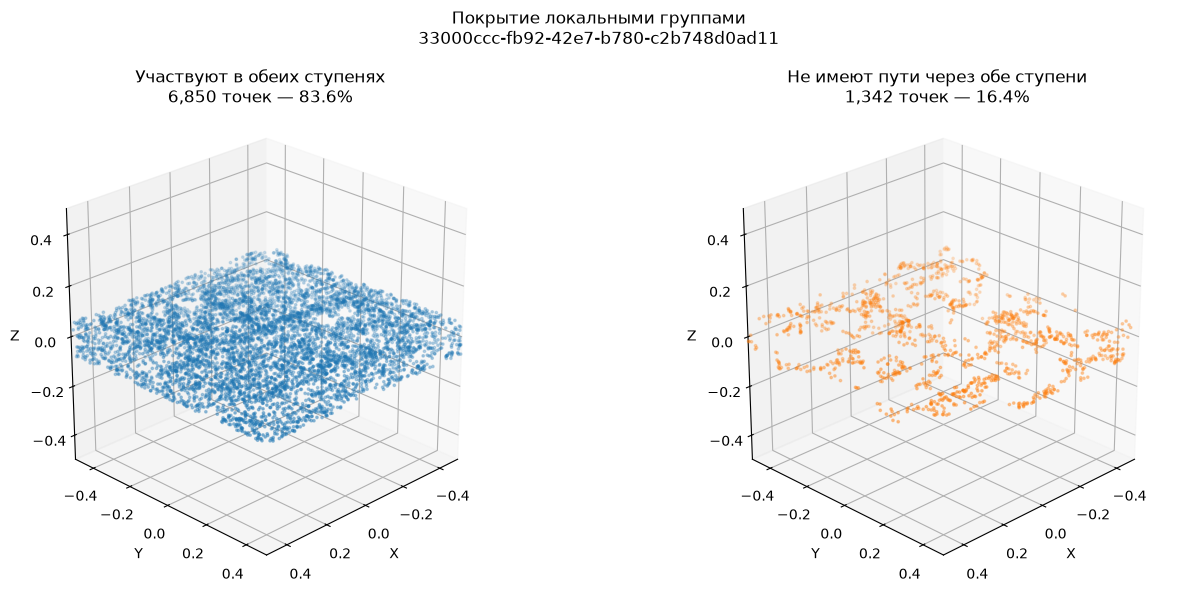

In [145]:
lowest_coverage_row = coverage_df.loc[
    coverage_df["final_coverage"].idxmin()
]

coverage_sample = coverage_dataset[
    int(lowest_coverage_row["dataset_index"])
]

coverage_result = inspect_geometry_coverage(
    features=coverage_sample["features"],
    device=DEVICE,
)

points = coverage_result["points"]
covered = coverage_result["covered_final"]

lower = points.min(axis=0)
upper = points.max(axis=0)
center = (lower + upper) / 2
half_extent = max(float((upper - lower).max()) / 2, 1e-6)

fig = plt.figure(figsize=(14, 6))

panels = [
    (covered, "Участвуют в обеих ступенях", "tab:blue"),
    (~covered, "Не имеют пути через обе ступени", "tab:orange"),
]

for panel_number, (mask, title, color) in enumerate(panels, start=1):
    ax = fig.add_subplot(1, 2, panel_number, projection="3d")

    selected_points = points[mask]

    ax.scatter(
        selected_points[:, 0],
        selected_points[:, 1],
        selected_points[:, 2],
        s=3,
        alpha=0.65,
        color=color,
    )

    ax.set_xlim(center[0] - half_extent, center[0] + half_extent)
    ax.set_ylim(center[1] - half_extent, center[1] + half_extent)
    ax.set_zlim(center[2] - half_extent, center[2] + half_extent)

    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=45)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_title(
        f"{title}\n"
        f"{mask.sum():,} точек — {mask.mean():.1%}"
    )

fig.suptitle(
    f'Покрытие локальными группами\n{coverage_sample["item_id"]}'
)

plt.tight_layout()
plt.show()

### Тестирование изменений в параметрах покрытия

In [146]:
coverage_64_rows = []

for dataset_index in coverage_indices:
    sample = coverage_dataset[int(dataset_index)]

    result = inspect_geometry_coverage(
        features=sample["features"],
        device=DEVICE,
        centers=(512, 128),
        neighbors=(64, 32),
    )

    coverage_64_rows.append({
        "item_id": sample["item_id"],
        "dataset_index": int(dataset_index),
        **result["metrics"],
    })

coverage_64_df = pd.DataFrame(coverage_64_rows)

# Сопоставляем результаты строго по объектам.
coverage_comparison = coverage_df.merge(
    coverage_64_df,
    on=["item_id", "dataset_index"],
    suffixes=("_32", "_64"),
    validate="one_to_one",
)

assert len(coverage_comparison) == len(coverage_df)
assert (
    coverage_comparison["num_points_32"]
    == coverage_comparison["num_points_64"]
).all()

coverage_comparison["coverage_gain_pp"] = 100 * (
    coverage_comparison["final_coverage_64"]
    - coverage_comparison["final_coverage_32"]
)

coverage_comparison["radius_ratio"] = (
    coverage_comparison["radius_median_64"]
    / coverage_comparison["radius_median_32"].replace(0, np.nan)
)

coverage_summary = pd.DataFrame(
    {
        "32 соседа": {
            "Среднее покрытие, %": (
                100 * coverage_comparison["final_coverage_32"].mean()
            ),
            "Минимальное покрытие, %": (
                100 * coverage_comparison["final_coverage_32"].min()
            ),
            "Среднее число пропущенных точек": (
                coverage_comparison["unused_points_32"].mean()
            ),
            "Средний медианный радиус": (
                coverage_comparison["radius_median_32"].mean()
            ),
        },
        "64 соседа": {
            "Среднее покрытие, %": (
                100 * coverage_comparison["final_coverage_64"].mean()
            ),
            "Минимальное покрытие, %": (
                100 * coverage_comparison["final_coverage_64"].min()
            ),
            "Среднее число пропущенных точек": (
                coverage_comparison["unused_points_64"].mean()
            ),
            "Средний медианный радиус": (
                coverage_comparison["radius_median_64"].mean()
            ),
        },
    }
)

display(coverage_summary.round(4))

display(
    coverage_comparison[
        [
            "item_id",
            "final_coverage_32",
            "final_coverage_64",
            "coverage_gain_pp",
            "radius_ratio",
        ]
    ].sort_values("final_coverage_64").reset_index(drop=True)
)

print(f'''Проверено одинаковых объектов: {len(coverage_comparison)}

Средний прирост покрытия: {coverage_comparison["coverage_gain_pp"].mean():.2f} п.п.
Среднее отношение радиусов 64 / 32: {coverage_comparison["radius_ratio"].mean():.2f}
''')

,32 соседа,64 соседа
"Среднее покрытие, %",86.1963,97.8206
"Минимальное покрытие, %",83.6182,96.4722
Среднее число пропущенных точек,1130.8000,178.5333
Средний медианный радиус,0.0369,0.0505


,item_id,final_coverage_32,final_coverage_64,coverage_gain_pp,radius_ratio
0,a519b681-b558-4789-956e-511de3d36783,0.838745,0.964722,12.597656,1.383252
1,b0f583e4-d11b-47d2-aae2-c78af0bd64a3,0.846924,0.967163,12.023926,1.361011
2,8722e033-9cef-43d0-ba7f-89871730a62d,0.853271,0.968140,11.486816,1.300483
3,72dc2d0f-34a6-4f07-88d7-db85c644ec68,0.843262,0.968262,12.500000,1.413814
4,16f21aa9-dd18-4f89-9187-c4357c23752d,0.859131,0.970337,11.120605,1.347119
5,d7d69f78-151e-4271-8230-03297c203059,0.843384,0.970947,12.756348,1.446076
6,bcfc9ab8-d709-4ef7-b68b-d4da4b08976a,0.865234,0.972412,10.717773,1.421810
7,ed7a86fa-9a84-4426-a1ff-3e9839fcea71,0.852173,0.972412,12.023926,1.363975
8,213ac732-9b26-4a67-9167-a2007695a948,0.852295,0.973877,12.158203,1.365737
9,33000ccc-fb92-42e7-b780-c2b748d0ad11,0.836182,0.974609,13.842773,1.381289


Проверено одинаковых объектов: 30

Средний прирост покрытия: 11.62 п.п.
Среднее отношение радиусов 64 / 32: 1.38



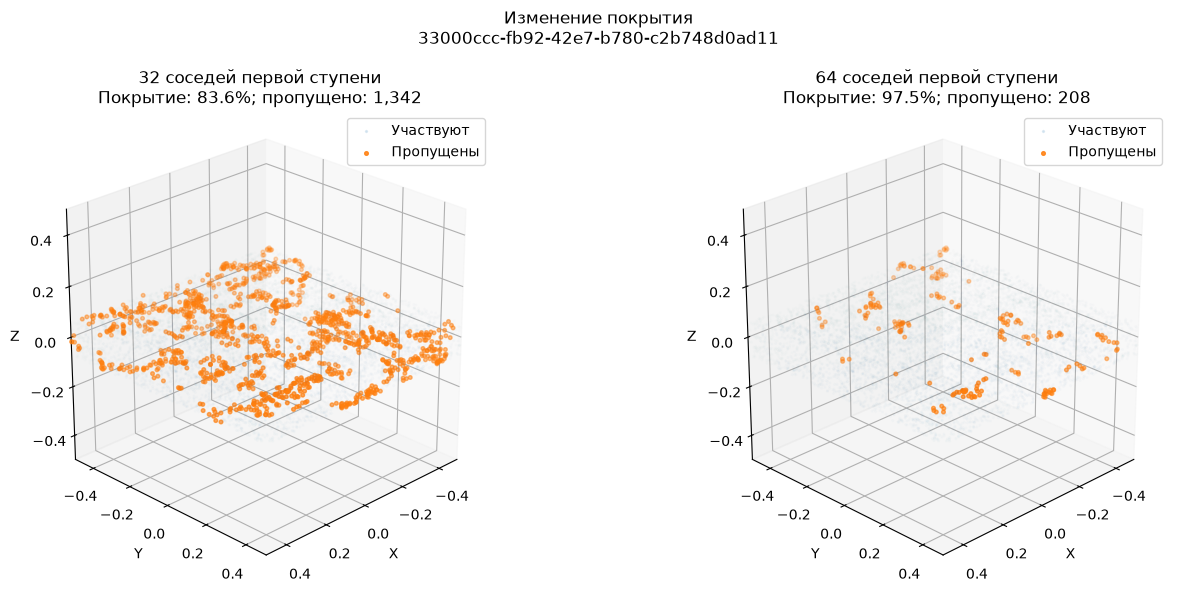

In [147]:
comparison_sample = coverage_dataset[
    int(lowest_coverage_row["dataset_index"])
]

coverage_visual_results = {}

for first_stage_neighbors in (32, 64):
    coverage_visual_results[first_stage_neighbors] = (
        inspect_geometry_coverage(
            features=comparison_sample["features"],
            device=DEVICE,
            centers=(512, 128),
            neighbors=(first_stage_neighbors, 32),
        )
    )

points = coverage_visual_results[32]["points"]

lower = points.min(axis=0)
upper = points.max(axis=0)
center = (lower + upper) / 2
half_extent = max(float((upper - lower).max()) / 2, 1e-6)

fig = plt.figure(figsize=(14, 6))

for panel_number, neighbor_count in enumerate((32, 64), start=1):
    result = coverage_visual_results[neighbor_count]
    covered = result["covered_final"]

    ax = fig.add_subplot(1, 2, panel_number, projection="3d")

    # Участвующие точки оставляем фоном для понимания формы.
    ax.scatter(
        points[covered, 0],
        points[covered, 1],
        points[covered, 2],
        s=2,
        alpha=0.12,
        color="tab:blue",
        label="Участвуют",
    )

    ax.scatter(
        points[~covered, 0],
        points[~covered, 1],
        points[~covered, 2],
        s=7,
        alpha=0.85,
        color="tab:orange",
        label="Пропущены",
    )

    ax.set_xlim(center[0] - half_extent, center[0] + half_extent)
    ax.set_ylim(center[1] - half_extent, center[1] + half_extent)
    ax.set_zlim(center[2] - half_extent, center[2] + half_extent)

    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=45)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_title(
        f"{neighbor_count} соседей первой ступени\n"
        f"Покрытие: {covered.mean():.1%}; "
        f"пропущено: {(~covered).sum():,}"
    )
    ax.legend()

fig.suptitle(
    f'Изменение покрытия\n{comparison_sample["item_id"]}'
)

plt.tight_layout()
plt.show()

64 соседа заметно улучшили покрытие — этот вариант имеет смысл проверить обучением

- Покрытие выросло с 86.2% до 97.8%
- Пропущенных точек стало примерно в 6.3 раза меньше: 179 вместо 1131
- Радиусы окрестностей увеличились в среднем в 1.38 раза
- На показанном объекте пропущенные участки существенно сократились

Теперь проверяем гипотезу: помогает ли расширенный охват поверхности распознавать дефекты. Более высокое покрытие само по себе ещё не гарантирует улучшения `f1_final`.

### Обучение нового конфига 3-D классификатора

In [148]:
import copy
import random

from datetime import datetime
from time import perf_counter
from torch.utils.data import DataLoader


geometry32_path = GEOMETRY_RUN_DIR / "best_model.pt"

geometry32_checkpoint = torch.load(
    geometry32_path,
    map_location="cpu",
    weights_only=True,
)

assert tuple(
    geometry32_checkpoint["model_config"]["neighbors"]
) == (32, 32)

assert geometry32_checkpoint["defect_columns"] == list(DEFECT_COLUMNS)
assert geometry32_checkpoint["target_columns"] == list(TARGET_COLUMNS)

# Проверяем не только состав, но и порядок объектов.
assert list(geometry_datasets["inner_train"].item_ids) == list(
    geometry32_checkpoint["train_item_ids"]
)
assert list(geometry_datasets["inner_valid"].item_ids) == list(
    geometry32_checkpoint["valid_item_ids"]
)

geometry64_model_config = copy.deepcopy(
    geometry32_checkpoint["model_config"]
)
geometry64_model_config["neighbors"] = (64, 32)

geometry64_training_config = copy.deepcopy(
    geometry32_checkpoint["training_config"]
)
assert geometry64_training_config.get("selection_metric") == SELECTION_METRIC, (
    "Сначала обучите вариант с 32 соседями по weighted AP."
)
geometry64_training_config["selection_metric"] = SELECTION_METRIC

for split in ("inner_train", "inner_valid"):
    dataset = geometry_datasets[split]

    assert dataset.num_points == geometry64_training_config["num_points"]
    assert dataset.subset_seed == geometry64_training_config["subset_seed"]
    assert dataset.config_hash == geometry64_training_config["geometry_cache_hash"]

geometry64_seed = geometry64_training_config["seed"]
geometry64_epochs = geometry64_training_config["max_epochs"]

geometry64_thresholds = np.asarray(
    geometry64_training_config["thresholds"],
    dtype=np.float64,
)

GEOMETRY64_RUN_DIR = CHECKPOINT_DIR / datetime.now().strftime(
    "geometry_neighbors64_weighted_ap_%Y%m%d_%H%M%S_%f"
)
GEOMETRY64_RUN_DIR.mkdir(parents=True, exist_ok=False)

random.seed(geometry64_seed)
np.random.seed(geometry64_seed)
torch.manual_seed(geometry64_seed)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(geometry64_seed)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(geometry64_seed)

# Создаём свежую модель, не загружаем обученные веса.
geometry64_model = LocalGeometryClassifier(
    **geometry64_model_config
).to(DEVICE)

geometry64_optimizer = torch.optim.AdamW(
    geometry64_model.parameters(),
    lr=geometry64_training_config["learning_rate"],
    weight_decay=geometry64_training_config["weight_decay"],
)

geometry64_train_loader = DataLoader(
    geometry_datasets["inner_train"],
    batch_size=geometry64_training_config["batch_size"],
    shuffle=True,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(geometry64_seed),
)

geometry64_valid_loader = DataLoader(
    geometry_datasets["inner_valid"],
    batch_size=geometry64_training_config["batch_size"],
    shuffle=False,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(geometry64_seed + 1),
)

print(f'''Новый эксперимент: 64 соседа первой ступени

Точек: {geometry64_training_config["num_points"]}
Центры: {geometry64_model_config["centers"]}
Соседи: {geometry64_model_config["neighbors"]}

Seed: {geometry64_seed}
Эпох: {geometry64_epochs}
Batch size: {geometry64_training_config["batch_size"]}

Папка результатов:
{GEOMETRY64_RUN_DIR}
''')

Новый эксперимент: 64 соседа первой ступени

Точек: 8192
Центры: (512, 128)
Соседи: (64, 32)

Seed: 42
Эпох: 30
Batch size: 4

Папка результатов:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/geometry_neighbors64_weighted_ap_20260917_124441_967536



In [149]:
geometry64_history = []
geometry64_best_score = -float("inf")
geometry64_best_epoch = None


def synchronize_geometry_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


for epoch in range(1, geometry64_epochs + 1):
    synchronize_geometry_device(DEVICE)
    started_at = perf_counter()

    train_loss = train_cached_epoch(
        geometry64_model,
        geometry64_train_loader,
        geometry64_optimizer,
        DEVICE,
    )

    metrics, targets, probabilities, item_ids = (
        evaluate_geometry_contest(
            model=geometry64_model,
            loader=geometry64_valid_loader,
            device=DEVICE,
            thresholds=geometry64_thresholds,
        )
    )

    synchronize_geometry_device(DEVICE)
    epoch_seconds = perf_counter() - started_at

    geometry64_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        **metrics,
        "seconds": epoch_seconds,
    })

    pd.DataFrame(geometry64_history).to_csv(
        GEOMETRY64_RUN_DIR / "history.csv",
        index=False,
    )

    current_score = metrics[SELECTION_METRIC]
    is_best = current_score > geometry64_best_score

    if is_best:
        geometry64_best_score = current_score
        geometry64_best_epoch = epoch

        torch.save(
            {
                "architecture": "local_geometry_v1",
                "model_state_dict": {
                    name: tensor.detach().cpu()
                    for name, tensor in geometry64_model.state_dict().items()
                },
                "model_config": geometry64_model_config,
                "training_config": geometry64_training_config,
                "epoch": epoch,
                "metrics": dict(metrics),
                "defect_columns": list(DEFECT_COLUMNS),
                "target_columns": list(TARGET_COLUMNS),
                "geometry_cache_config": copy.deepcopy(
                    geometry32_checkpoint["geometry_cache_config"]
                ),
                "train_item_ids": list(
                    geometry_datasets["inner_train"].item_ids
                ),
                "valid_item_ids": list(
                    geometry_datasets["inner_valid"].item_ids
                ),
                "comparison_checkpoint": str(geometry32_path),
            },
            GEOMETRY64_RUN_DIR / "best_model.pt",
        )

        np.savez_compressed(
            GEOMETRY64_RUN_DIR / "best_validation_predictions.npz",
            item_ids=np.asarray(item_ids, dtype=str),
            targets=targets,
            probabilities=probabilities,
            thresholds=geometry64_thresholds,
        )

    if epoch == 1 or epoch % 5 == 0 or is_best:
        checkpoint_message = (
            "Сохранён лучший checkpoint."
            if is_best
            else ""
        )

        print(f'''Эпоха: {epoch}/{geometry64_epochs}

Train loss: {train_loss:.4f}
Validation loss: {metrics["valid_loss"]:.4f}

F1 качества: {metrics["f1_quality"]:.6f}
F1 дефектов: {metrics["f1_defects_weighted"]:.6f}
F1 final: {metrics["f1_final"]:.6f}
Weighted AP: {metrics["weighted_ap"]:.6f}

Обучение и валидация: {epoch_seconds:.2f} с
{checkpoint_message}
''')

geometry64_history_df = pd.DataFrame(geometry64_history)

# Возвращаем модель к лучшей эпохе, а не оставляем последнюю.
geometry64_checkpoint = torch.load(
    GEOMETRY64_RUN_DIR / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

geometry64_model.load_state_dict(
    geometry64_checkpoint["model_state_dict"]
)
geometry64_model.eval()

print(f'''Обучение завершено.

Лучшая эпоха: {geometry64_best_epoch}
Лучший weighted AP: {geometry64_best_score:.6f}

Checkpoint:
{GEOMETRY64_RUN_DIR / "best_model.pt"}
''')

Эпоха: 1/30

Train loss: 0.2761
Validation loss: 0.2556

F1 качества: 0.298343
F1 дефектов: 0.280821
F1 final: 5.791638
Weighted AP: 0.437301

Обучение и валидация: 44.04 с
Сохранён лучший checkpoint.

Эпоха: 2/30

Train loss: 0.2584
Validation loss: 0.2426

F1 качества: 0.352801
F1 дефектов: 0.317655
F1 final: 6.704561
Weighted AP: 0.452462

Обучение и валидация: 43.82 с
Сохранён лучший checkpoint.

Эпоха: 3/30

Train loss: 0.2518
Validation loss: 0.2382

F1 качества: 0.320320
F1 дефектов: 0.272116
F1 final: 5.924364
Weighted AP: 0.480289

Обучение и валидация: 43.70 с
Сохранён лучший checkpoint.

Эпоха: 5/30

Train loss: 0.2399
Validation loss: 0.2287

F1 качества: 0.361727
F1 дефектов: 0.345364
F1 final: 7.070912
Weighted AP: 0.499022

Обучение и валидация: 41.59 с
Сохранён лучший checkpoint.

Эпоха: 7/30

Train loss: 0.2311
Validation loss: 0.2281

F1 качества: 0.355401
F1 дефектов: 0.362650
F1 final: 7.180505
Weighted AP: 0.504409

Обучение и валидация: 41.88 с
Сохранён лучший che

### Сравнение по валидации

In [150]:
geometry_neighbor_comparison = pd.DataFrame(
    [
        {
            "variant": "neighbors_32",
            "epoch": geometry32_checkpoint["epoch"],
            **geometry32_checkpoint["metrics"],
        },
        {
            "variant": "neighbors_64",
            "epoch": geometry64_checkpoint["epoch"],
            **geometry64_checkpoint["metrics"],
        },
    ]
).set_index("variant")

display(
    geometry_neighbor_comparison[
        [
            "epoch",
            "valid_loss",
            "f1_quality",
            "f1_defects_weighted",
            "f1_final",
            "weighted_ap",
        ]
    ]
)

geometry32_history_df = pd.read_csv(
    geometry32_path.parent / "history.csv"
)

# Исключаем первую эпоху из сравнения времени из-за прогрева.
seconds32 = geometry32_history_df["seconds"].iloc[1:].mean()
seconds64 = geometry64_history_df["seconds"].iloc[1:].mean()

score_delta = (
    geometry64_checkpoint["metrics"]["weighted_ap"]
    - geometry32_checkpoint["metrics"]["weighted_ap"]
)

print(f'''Изменение weighted AP на внутренней валидации: {score_delta:+.6f}

Среднее время эпохи без первой:
32 соседа: {seconds32:.2f} с
64 соседа: {seconds64:.2f} с
Отношение времени: {seconds64 / seconds32:.2f}
''')

,epoch,valid_loss,f1_quality,f1_defects_weighted,f1_final,weighted_ap
variant,,,,,,
neighbors_32,18,0.225308,0.370470,0.434718,8.051882,0.534582
neighbors_64,17,0.217048,0.387009,0.428173,8.151824,0.545821


Изменение weighted AP на внутренней валидации: +0.011239

Среднее время эпохи без первой:
32 соседа: 40.69 с
64 соседа: 42.49 с
Отношение времени: 1.04



### Подбор порогов для новой модели

In [151]:
geometry64_checkpoint = torch.load(
    GEOMETRY64_RUN_DIR / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

geometry64_model.load_state_dict(
    geometry64_checkpoint["model_state_dict"]
)
geometry64_model.eval()

geometry64_outer_loader = DataLoader(
    geometry_datasets["outer_valid"],
    batch_size=geometry64_training_config["batch_size"],
    shuffle=False,
    num_workers=GEOMETRY_NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

(
    _,
    geometry64_outer_targets,
    geometry64_outer_probabilities,
    geometry64_outer_ids,
) = evaluate_geometry_contest(
    model=geometry64_model,
    loader=geometry64_outer_loader,
    device=DEVICE,
    thresholds=0.5,
)

# Используем порядок объектов предыдущей 3D-модели.
geometry_comparison_ids = pd.Index(
    geometry_outer_ids,
    name="item_id",
)
geometry64_index = pd.Index(
    geometry64_outer_ids,
    name="item_id",
)

assert geometry_comparison_ids.is_unique
assert geometry64_index.is_unique
assert set(geometry_comparison_ids) == set(geometry64_index)

geometry64_order = geometry64_index.get_indexer(
    geometry_comparison_ids
)
assert (geometry64_order >= 0).all()

geometry64_aligned_probs = geometry64_outer_probabilities[
    geometry64_order
]
geometry64_aligned_targets = geometry64_outer_targets[
    geometry64_order
]

np.testing.assert_array_equal(
    geometry64_aligned_targets,
    geometry_outer_targets,
)

# Восстанавливаем прежнее разбиение по группам.
geometry_comparison_table = threshold_df.loc[
    geometry_comparison_ids
]

geometry64_calibration_mask = (
    geometry_comparison_table["group_id"]
    .isin(calibration_groups)
    .to_numpy()
)
geometry64_check_mask = (
    geometry_comparison_table["group_id"]
    .isin(check_groups)
    .to_numpy()
)

assert not (
    geometry64_calibration_mask & geometry64_check_mask
).any()
assert (
    geometry64_calibration_mask | geometry64_check_mask
).all()

np.testing.assert_array_equal(
    geometry64_calibration_mask,
    geometry_calibration_mask,
)
np.testing.assert_array_equal(
    geometry64_check_mask,
    geometry_check_mask,
)

print(f'''Объектов: {len(geometry_comparison_ids)}
Calibration: {geometry64_calibration_mask.sum()}
Check: {geometry64_check_mask.sum()}

Порядок объектов и разбиение проверены.
''')

Объектов: 2994
Calibration: 1496
Check: 1498

Порядок объектов и разбиение проверены.



In [152]:
(
    geometry64_tuned_thresholds,
    geometry64_threshold_history,
) = tune_class_thresholds(
    targets=geometry64_aligned_targets[
        geometry64_calibration_mask
    ],
    probabilities=geometry64_aligned_probs[
        geometry64_calibration_mask
    ],
    initial_thresholds=np.full(
        NUM_DEFECTS,
        0.5,
        dtype=np.float64,
    ),
    max_passes=5,
)

geometry_neighbor_thresholds = pd.DataFrame(
    {
        "neighbors32_tuned": geometry_tuned_thresholds,
        "neighbors64_tuned": geometry64_tuned_thresholds,
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

display(geometry_neighbor_thresholds.round(4))

Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 9.846716



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 9.860187



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 3
Метрика на calibration: 9.860187



,neighbors32_tuned,neighbors64_tuned
defect,,
abstract,0.2000,0.18
artifacts,0.0900,0.13
intersection,0.0300,0.50
lowpoly,0.4700,0.41
noisy,0.1700,0.36
open,0.0825,0.12
partial,0.3600,0.70
scale,0.0700,0.05
set,0.2600,0.41


In [153]:
geometry_neighbor_variants = {
    "neighbors32_tuned": (
        geometry_outer_probabilities,
        geometry_tuned_thresholds,
    ),
    "neighbors64_0.5": (
        geometry64_aligned_probs,
        np.full(NUM_DEFECTS, 0.5),
    ),
    "neighbors64_tuned": (
        geometry64_aligned_probs,
        geometry64_tuned_thresholds,
    ),
}

geometry_neighbor_rows = []

for split_name, mask in {
    "calibration": geometry64_calibration_mask,
    "check": geometry64_check_mask,
}.items():
    for variant, (probabilities, thresholds) in (
        geometry_neighbor_variants.items()
    ):
        metrics = calculate_metrics(
            geometry64_aligned_targets[mask],
            probabilities[mask],
            thresholds=thresholds,
        )

        geometry_neighbor_rows.append({
            "split": split_name,
            "variant": variant,
            **metrics,
        })

geometry_neighbor_metrics = pd.DataFrame(
    geometry_neighbor_rows
).set_index(["split", "variant"])

display(geometry_neighbor_metrics)

geometry_neighbor_quality_rows = []

quality_column = list(TARGET_COLUMNS).index("quality")
check_quality_true = geometry64_aligned_targets[
    geometry64_check_mask, quality_column
].astype(int)

for variant, (probabilities, thresholds) in (
    geometry_neighbor_variants.items()
):
    predicted_defects = (
        probabilities[geometry64_check_mask] >= thresholds
    )
    predicted_quality = (
        ~predicted_defects.any(axis=1)
    ).astype(int)

    geometry_neighbor_quality_rows.append({
        "variant": variant,
        "bad_as_bad": int(
            ((check_quality_true == 0) & (predicted_quality == 0)).sum()
        ),
        "bad_as_good": int(
            ((check_quality_true == 0) & (predicted_quality == 1)).sum()
        ),
        "good_as_bad": int(
            ((check_quality_true == 1) & (predicted_quality == 0)).sum()
        ),
        "good_as_good": int(
            ((check_quality_true == 1) & (predicted_quality == 1)).sum()
        ),
    })

geometry_neighbor_quality = pd.DataFrame(
    geometry_neighbor_quality_rows
).set_index("variant")

display(geometry_neighbor_quality)

geometry64_calibration_gain = (
    geometry_neighbor_metrics.loc[
        ("check", "neighbors64_tuned"), "f1_final"
    ]
    - geometry_neighbor_metrics.loc[
        ("check", "neighbors64_0.5"), "f1_final"
    ]
)

geometry64_vs32_gain = (
    geometry_neighbor_metrics.loc[
        ("check", "neighbors64_tuned"), "f1_final"
    ]
    - geometry_neighbor_metrics.loc[
        ("check", "neighbors32_tuned"), "f1_final"
    ]
)

print(f'''Результаты на check:

Прирост от настройки порогов модели с 64 соседями:
{geometry64_calibration_gain:+.6f}

Разница между настроенными моделями: 64 минус 32 соседа:
{geometry64_vs32_gain:+.6f}
''')

f1_quality  f1_defects_weighted  f1_final  \
split       variant                                                        
calibration neighbors32_tuned    0.448898             0.504886  9.537841   
            neighbors64_0.5      0.385819             0.411350  7.971682   
            neighbors64_tuned    0.467662             0.518357  9.860187   
check       neighbors32_tuned    0.408247             0.479361  8.876089   
            neighbors64_0.5      0.379272             0.414618  7.938906   
            neighbors64_tuned    0.388889             0.490265  8.791534   

                               weighted_ap  
split       variant                         
calibration neighbors32_tuned     0.524762  
            neighbors64_0.5       0.542034  
            neighbors64_tuned     0.542034  
check       neighbors32_tuned     0.517350  
            neighbors64_0.5       0.536613  
            neighbors64_tuned     0.536613

,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
neighbors32_tuned,1112,157,130,99
neighbors64_0.5,763,506,57,172
neighbors64_tuned,1034,235,117,112


Результаты на check:

Прирост от настройки порогов модели с 64 соседями:
+0.852629

Разница между настроенными моделями: 64 минус 32 соседа:
-0.084554



In [154]:
GEOMETRY64_THRESHOLD_DIR = (
    GEOMETRY64_RUN_DIR / "threshold_calibration"
)
GEOMETRY64_THRESHOLD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

geometry_neighbor_thresholds.to_csv(
    GEOMETRY64_THRESHOLD_DIR / "thresholds.csv"
)
geometry64_threshold_history.to_csv(
    GEOMETRY64_THRESHOLD_DIR / "threshold_search.csv",
    index=False,
)
geometry_neighbor_metrics.to_csv(
    GEOMETRY64_THRESHOLD_DIR / "comparison.csv"
)
geometry_neighbor_quality.to_csv(
    GEOMETRY64_THRESHOLD_DIR / "quality_errors.csv"
)

np.savez_compressed(
    GEOMETRY64_THRESHOLD_DIR / "outer_predictions.npz",
    item_ids=geometry_comparison_ids.to_numpy(dtype=str),
    targets=geometry64_aligned_targets,
    probabilities=geometry64_aligned_probs,
    thresholds=geometry64_tuned_thresholds,
    calibration_mask=geometry64_calibration_mask,
    check_mask=geometry64_check_mask,
)

torch.save(
    {
        **geometry64_checkpoint,
        "inference_config": {
            "thresholds": geometry64_tuned_thresholds.tolist(),
            "defect_columns": list(DEFECT_COLUMNS),
            "quality_rule": "no_predicted_defects",
        },
        "threshold_fit_item_ids": geometry_comparison_ids[
            geometry64_calibration_mask
        ].tolist(),
        "outer_check_item_ids": geometry_comparison_ids[
            geometry64_check_mask
        ].tolist(),
        "outer_check_metrics": geometry_neighbor_metrics.loc[
            ("check", "neighbors64_tuned")
        ].to_dict(),
    },
    GEOMETRY64_THRESHOLD_DIR / "model_tuned.pt",
)

print(f'''Результаты и модель с настроенными порогами сохранены:
{GEOMETRY64_THRESHOLD_DIR}
''')

Результаты и модель с настроенными порогами сохранены:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/geometry_neighbors64_weighted_ap_20260917_124441_967536/threshold_calibration



| Вариант | Weighted AP | F1 final |
|---|---:|---:|
| **85% визуальный baseline + 15% геометрия с 32 соседями** | **0.685230** | 11.839892 |
| **DINOv2 + новая голова, конфигурация trial 11** | 0.679660 | **11.932692** |
| Исходный визуальный baseline | 0.677597 | 11.834962 |
| Геометрия, 64 соседа | 0.536613 | 8.791534 |
| Геометрия, 32 соседа | 0.517350 | 8.876089 |

Сделаем два новых варианта:
1. Baseline-голова + 3D.
2. Голова trial 11 + та же 3D-модель.

Обе визуальные головы обучаем с нуля на 5970 объектах. Число эпох берём из уже рассчитанных средних кривых: 5 для baseline и 12 для trial 11. Поэтому новый baseline будет отличаться от прежнего трёхэпохового запуска.

### Подготовка даннных и конфига

In [155]:
import copy
import json
import random

from datetime import datetime
from time import perf_counter


PAIR_DIR = CHECKPOINT_DIR / datetime.now().strftime(
    "two_heads_class_blend_%Y%m%d_%H%M%S_%f"
)
PAIR_DIR.mkdir(parents=True, exist_ok=False)

PAIR_SEED = 42
PAIR_BATCH_SIZE = 16

# Находим конфигурацию именно trial 11 по сохранённому соответствию.
trial11_names = [
    name
    for name, trial_number in stability_source_trials.items()
    if trial_number == 11
]
assert len(trial11_names) == 1, (
    "В текущих stability_configs не найдена конфигурация trial 11."
)

pair_sources = {
    "baseline": "baseline",
    "trial11": trial11_names[0],
}

pair_configs = {
    name: {
        "params": copy.deepcopy(stability_configs[source]),
        "epochs": int(
            best_mean_epochs.loc[
                source, "best_epoch_of_mean_curve"
            ]
        ),
    }
    for name, source in pair_sources.items()
}

pair_ids = pd.Index(valid_cache["item_ids"], name="item_id")
pair_targets = valid_cache["targets"].cpu().numpy()

assert pair_ids.is_unique
assert train_cache["metadata"] == valid_cache["metadata"]

pair_table = threshold_df.loc[pair_ids]

np.testing.assert_array_equal(
    pair_table[TARGET_COLUMNS].to_numpy(),
    pair_targets,
)

pair_calibration_mask = (
    pair_table["group_id"].isin(calibration_groups).to_numpy()
)
pair_check_mask = (
    pair_table["group_id"].isin(check_groups).to_numpy()
)

assert not (pair_calibration_mask & pair_check_mask).any()
assert (pair_calibration_mask | pair_check_mask).all()
assert set(train_cache["item_ids"]).isdisjoint(set(pair_ids))

# Загружаем сохранённые предсказания 3D-модели с 32 соседями.
pair_geometry_path = (
    GEOMETRY_RUN_DIR
    / "threshold_calibration"
    / "outer_predictions.npz"
)

with np.load(pair_geometry_path, allow_pickle=False) as saved:
    geometry_ids = pd.Index(saved["item_ids"].astype(str))
    assert geometry_ids.is_unique
    assert set(geometry_ids) == set(pair_ids)

    geometry_order = geometry_ids.get_indexer(pair_ids)
    pair_geometry_probs = saved["probabilities"][geometry_order].copy()

    np.testing.assert_array_equal(
        saved["targets"][geometry_order],
        pair_targets,
    )

pair_geometry_checkpoint = torch.load(
    GEOMETRY_RUN_DIR / "best_model.pt",
    map_location="cpu",
    weights_only=True,
)

assert tuple(
    pair_geometry_checkpoint["model_config"]["neighbors"]
) == (32, 32)
assert pair_geometry_checkpoint["defect_columns"] == list(DEFECT_COLUMNS)
assert set(
    pair_geometry_checkpoint["train_item_ids"]
).isdisjoint(set(pair_ids))

pair_train_dataset = CachedFeatureDataset(
    train_cache,
    np.arange(len(train_cache["item_ids"])),
)

display(pd.DataFrame({
    name: {
        **config["params"],
        "epochs": config["epochs"],
    }
    for name, config in pair_configs.items()
}).T)

print(f'''Обучающих объектов: {len(pair_train_dataset)}
Calibration: {pair_calibration_mask.sum()}
Check: {pair_check_mask.sum()}

Папка эксперимента:
{PAIR_DIR}
''')

,learning_rate,weight_decay,hidden_dim,dropout,epochs
baseline,0.001000,0.010000,256.0,0.200000,5.0
trial11,0.000492,0.000702,256.0,0.434835,12.0


Обучающих объектов: 5970
Calibration: 1496
Check: 1498

Папка эксперимента:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/two_heads_class_blend_20260917_132101_468006



### Обучение новых голов

In [156]:
pair_image_probabilities = {}

for name, config in pair_configs.items():
    random.seed(PAIR_SEED)
    np.random.seed(PAIR_SEED)
    torch.manual_seed(PAIR_SEED)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(PAIR_SEED)
    elif DEVICE.type == "mps":
        torch.mps.manual_seed(PAIR_SEED)

    params = config["params"]
    head_dir = PAIR_DIR / name
    head_dir.mkdir()

    head = CachedMultiViewHead(
        feature_dim=train_cache["features"].shape[-1],
        num_defects=NUM_DEFECTS,
        num_views=NUM_VIEWS,
        hidden_dim=params["hidden_dim"],
        dropout=params["dropout"],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )

    loader = DataLoader(
        pair_train_dataset,
        batch_size=PAIR_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(PAIR_SEED),
    )

    history = []

    for epoch in range(1, config["epochs"] + 1):
        synchronize_device(DEVICE)
        started_at = perf_counter()

        loss = train_cached_epoch(
            head, loader, optimizer, DEVICE,
        )

        synchronize_device(DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": loss,
            "seconds": perf_counter() - started_at,
        })

        print(f'''Модель: {name}
Эпоха: {epoch}/{config["epochs"]}
Train loss: {loss:.6f}
''')

    pd.DataFrame(history).to_csv(
        head_dir / "history.csv",
        index=False,
    )

    torch.save(
        {
            "head_state_dict": {
                key: value.detach().cpu()
                for key, value in head.state_dict().items()
            },
            "params": params,
            "epoch": config["epochs"],
            "seed": PAIR_SEED,
            "batch_size": PAIR_BATCH_SIZE,
            "feature_dim": train_cache["features"].shape[-1],
            "num_views": NUM_VIEWS,
            "defect_columns": list(DEFECT_COLUMNS),
            "selection_metric": "weighted_ap",
            "epoch_selection": "previous_inner_mean_curve",
            "train_item_ids": list(train_cache["item_ids"]),
            "cache_metadata": train_cache["metadata"],
        },
        head_dir / "head.pt",
    )

    head.eval()
    probability_batches = []

    with torch.no_grad():
        for start in range(0, len(pair_ids), PAIR_BATCH_SIZE):
            features = valid_cache["features"][
                start:start + PAIR_BATCH_SIZE
            ].to(DEVICE)

            probability_batches.append(
                torch.sigmoid(head(features)).cpu().numpy()
            )

    pair_image_probabilities[name] = np.concatenate(
        probability_batches,
        axis=0,
    )

    del optimizer, head, loader

Модель: baseline
Эпоха: 1/5
Train loss: 0.210499

Модель: baseline
Эпоха: 2/5
Train loss: 0.178428

Модель: baseline
Эпоха: 3/5
Train loss: 0.168160

Модель: baseline
Эпоха: 4/5
Train loss: 0.157117

Модель: baseline
Эпоха: 5/5
Train loss: 0.148191

Модель: trial11
Эпоха: 1/12
Train loss: 0.225509

Модель: trial11
Эпоха: 2/12
Train loss: 0.187882

Модель: trial11
Эпоха: 3/12
Train loss: 0.178839

Модель: trial11
Эпоха: 4/12
Train loss: 0.170267

Модель: trial11
Эпоха: 5/12
Train loss: 0.164358

Модель: trial11
Эпоха: 6/12
Train loss: 0.158873

Модель: trial11
Эпоха: 7/12
Train loss: 0.154600

Модель: trial11
Эпоха: 8/12
Train loss: 0.148421

Модель: trial11
Эпоха: 9/12
Train loss: 0.142112

Модель: trial11
Эпоха: 10/12
Train loss: 0.137191

Модель: trial11
Эпоха: 11/12
Train loss: 0.131811

Модель: trial11
Эпоха: 12/12
Train loss: 0.126483



### Подбор отдельного веса для каждого дефекта

In [157]:
from sklearn.metrics import average_precision_score


def fit_class_blend_weights(
    targets,
    image_probs,
    geometry_probs,
):
    labels = np.asarray(targets)[:, :NUM_DEFECTS]

    assert labels.shape == image_probs.shape == geometry_probs.shape
    assert np.isfinite(image_probs).all()
    assert np.isfinite(geometry_probs).all()

    support = labels.sum(axis=0)

    if ((support == 0) | (support == len(labels))).any():
        raise ValueError(
            "Для каждого дефекта нужны оба значения метки."
        )

    grid = np.round(np.linspace(0.0, 1.0, 21), 2)
    weights = np.zeros(NUM_DEFECTS, dtype=np.float64)
    search_rows = []

    for class_index, defect in enumerate(DEFECT_COLUMNS):
        best_ap = -float("inf")

        for alpha in grid:
            scores = (
                (1 - alpha) * image_probs[:, class_index]
                + alpha * geometry_probs[:, class_index]
            )

            ap = float(
                average_precision_score(
                    labels[:, class_index],
                    scores,
                )
            )

            search_rows.append({
                "defect": defect,
                "alpha_geometry": float(alpha),
                "ap": ap,
            })

            if ap > best_ap + 1e-12:
                best_ap = ap
                weights[class_index] = alpha

    return weights, pd.DataFrame(search_rows)

### Настройка весов и порогов на calibration

In [158]:
pair_variants = {}
pair_settings = {}
pair_calibration_rows = []

for name, image_probs in pair_image_probabilities.items():
    head_dir = PAIR_DIR / name

    weights, weight_history = fit_class_blend_weights(
        pair_targets[pair_calibration_mask],
        image_probs[pair_calibration_mask],
        pair_geometry_probs[pair_calibration_mask],
    )

    blended_probs = (
        (1 - weights) * image_probs
        + weights * pair_geometry_probs
    )

    for suffix, probabilities in {
        "image": image_probs,
        "blend": blended_probs,
    }.items():
        variant = f"{name}_{suffix}"

        thresholds, threshold_history = tune_class_thresholds(
            targets=pair_targets[pair_calibration_mask],
            probabilities=probabilities[pair_calibration_mask],
            initial_thresholds=np.full(NUM_DEFECTS, 0.5),
            max_passes=5,
        )

        pair_variants[variant] = {
            "probabilities": probabilities,
            "thresholds": thresholds,
        }

        metrics = calculate_metrics(
            pair_targets[pair_calibration_mask],
            probabilities[pair_calibration_mask],
            thresholds=thresholds,
        )

        pair_calibration_rows.append({
            "variant": variant,
            **metrics,
        })

        threshold_history.to_csv(
            head_dir / f"{suffix}_threshold_search.csv",
            index=False,
        )

    settings = pd.DataFrame(
        {
            "alpha_geometry": weights,
            "alpha_image": 1 - weights,
            "image_threshold": pair_variants[
                f"{name}_image"
            ]["thresholds"],
            "blend_threshold": pair_variants[
                f"{name}_blend"
            ]["thresholds"],
        },
        index=pd.Index(DEFECT_COLUMNS, name="defect"),
    )

    pair_settings[name] = settings

    settings.to_csv(head_dir / "class_settings.csv")
    weight_history.to_csv(
        head_dir / "weight_search.csv",
        index=False,
    )

    print(f'''Модель: {name}
Индивидуальные веса и пороги:
''')
    display(settings.round(4))

pair_calibration_report = (
    pd.DataFrame(pair_calibration_rows)
    .set_index("variant")
    .sort_values("weighted_ap", ascending=False, kind="stable")
)

# Фиксируем выбор до просмотра check.
# При равенстве сохраняется порядок: image перед blend.
pair_selected_variant = pair_calibration_report.index[0]

display(pair_calibration_report)

print(f'''Выбранный вариант: {pair_selected_variant}
Критерий: weighted AP на calibration.
''')

Проход 1:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 1
Метрика на calibration: 12.580408



Проход 2:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 2
Метрика на calibration: 12.909234



Проход 3:   0%|          | 0/10 [00:00<?, ?it/s]

...

Проход 4:   0%|          | 0/10 [00:00<?, ?it/s]


Проход: 4
Метрика на calibration: 13.031591

Модель: trial11
Индивидуальные веса и пороги:



,alpha_geometry,alpha_image,image_threshold,blend_threshold
defect,,,,
abstract,0.05,0.95,0.1000,0.11
artifacts,0.00,1.00,0.1500,0.15
intersection,0.05,0.95,0.0681,0.06
lowpoly,0.00,1.00,0.2900,0.29
noisy,0.10,0.90,0.5400,0.51
open,0.40,0.60,0.1400,0.09
partial,0.50,0.50,0.4700,0.42
scale,0.00,1.00,0.1200,0.07
set,0.10,0.90,0.1800,0.14


,f1_quality,f1_defects_weighted,f1_final,weighted_ap
variant,,,,
trial11_blend,0.652174,0.650985,13.031591,0.699763
trial11_image,0.653846,0.650382,13.042277,0.693662
baseline_blend,0.657778,0.643462,13.012401,0.689436
baseline_image,0.650964,0.639960,12.909234,0.683484


Выбранный вариант: trial11_blend
Критерий: weighted AP на calibration.



In [159]:
pair_check_rows = []
pair_quality_rows = []

check_targets = pair_targets[pair_check_mask]
quality_index = list(TARGET_COLUMNS).index("quality")
true_good = check_targets[:, quality_index].astype(bool)

for variant, result in pair_variants.items():
    probabilities = result["probabilities"][pair_check_mask]
    thresholds = result["thresholds"]

    metrics = calculate_metrics(
        check_targets,
        probabilities,
        thresholds=thresholds,
    )

    pair_check_rows.append({
        "variant": variant,
        "selected_on_calibration": variant == pair_selected_variant,
        **metrics,
    })

    predicted_good = ~(
        probabilities >= thresholds
    ).any(axis=1)

    pair_quality_rows.append({
        "variant": variant,
        "bad_as_bad": int((~true_good & ~predicted_good).sum()),
        "bad_as_good": int((~true_good & predicted_good).sum()),
        "good_as_bad": int((true_good & ~predicted_good).sum()),
        "good_as_good": int((true_good & predicted_good).sum()),
    })

    np.savez_compressed(
        PAIR_DIR / f"{variant}_predictions.npz",
        item_ids=pair_ids.to_numpy(dtype=str),
        targets=pair_targets,
        probabilities=result["probabilities"],
        thresholds=thresholds,
        calibration_mask=pair_calibration_mask,
        check_mask=pair_check_mask,
    )

pair_check_report = pd.DataFrame(
    pair_check_rows
).set_index("variant")

pair_quality_report = pd.DataFrame(
    pair_quality_rows
).set_index("variant")

display(pair_check_report.round(6))
display(pair_quality_report)

pair_calibration_report.to_csv(
    PAIR_DIR / "calibration_metrics.csv"
)
pair_check_report.to_csv(PAIR_DIR / "check_metrics.csv")
pair_quality_report.to_csv(PAIR_DIR / "check_quality_errors.csv")

pair_manifest = {
    "seed": PAIR_SEED,
    "configs": pair_configs,
    "selection_metric": "weighted_ap",
    "threshold_selection_metric": "f1_final",
    "selected_variant": pair_selected_variant,
    "defect_columns": list(DEFECT_COLUMNS),
    "image_backbone_checkpoint": str(BEST_MODEL_PATH.resolve()),
    "geometry_checkpoint": str(
        (GEOMETRY_RUN_DIR / "best_model.pt").resolve()
    ),
    "calibration_item_ids": pair_ids[pair_calibration_mask].tolist(),
    "check_item_ids": pair_ids[pair_check_mask].tolist(),
    "class_settings": {
        name: settings.reset_index().to_dict(orient="records")
        for name, settings in pair_settings.items()
    },
}

(PAIR_DIR / "experiment.json").write_text(
    json.dumps(pair_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f'''Эксперимент завершён.

Вариант, выбранный на calibration:
{pair_selected_variant}

Weighted AP на check:
{pair_check_report.loc[pair_selected_variant, "weighted_ap"]:.6f}

F1 final на check:
{pair_check_report.loc[pair_selected_variant, "f1_final"]:.6f}

Результаты:
{PAIR_DIR}
''')

,selected_on_calibration,f1_quality,f1_defects_weighted,f1_final,weighted_ap
variant,,,,,
baseline_image,False,0.559499,0.612400,11.718987,0.669304
baseline_blend,False,0.550538,0.609735,11.602731,0.678521
trial11_image,False,0.572034,0.621235,11.932692,0.679660
trial11_blend,True,0.567568,0.622522,11.900894,0.686038


,bad_as_bad,bad_as_good,good_as_bad,good_as_good
variant,,,,
baseline_image,1153,116,95,134
baseline_blend,1161,108,101,128
trial11_image,1161,108,94,135
trial11_blend,1180,89,103,126


Эксперимент завершён.

Вариант, выбранный на calibration:
trial11_blend

Weighted AP на check:
0.686038

F1 final на check:
11.900894

Результаты:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/two_heads_class_blend_20260917_132101_468006



### Сравнение `trial11_image` и `trial11_blend` с уже зафиксированными весами и порогами

Посмотрим:
1. Для каких дефектов выросли AP и F1.
2. Какие дефекты вызывают ложные срабатывания на хороших объектах.
3. Какие объекты смесь исправила, а какие стала классифицировать хуже.

In [160]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    precision_recall_fscore_support,
)


diagnostic_mask = pair_check_mask
diagnostic_targets = pair_targets[diagnostic_mask]

diagnostic_labels = diagnostic_targets[
    :, :NUM_DEFECTS
].astype(int)

diagnostic_ids = pair_ids[diagnostic_mask]

diagnostic_probs = {}
diagnostic_preds = {}
diagnostic_thresholds = {}

for name in ("trial11_image", "trial11_blend"):
    result = pair_variants[name]

    diagnostic_probs[name] = result["probabilities"][
        diagnostic_mask
    ]
    diagnostic_thresholds[name] = np.asarray(
        result["thresholds"]
    )
    diagnostic_preds[name] = (
        diagnostic_probs[name] >= diagnostic_thresholds[name]
    )

support = diagnostic_labels.sum(axis=0)
assert ((support > 0) & (support < len(diagnostic_labels))).all()

class_stats = {}

for name in ("trial11_image", "trial11_blend"):
    predictions = diagnostic_preds[name]

    precision, recall, f1, _ = precision_recall_fscore_support(
        diagnostic_labels,
        predictions,
        average=None,
        zero_division=0,
    )

    class_stats[name] = {
        "ap": average_precision_score(
            diagnostic_labels,
            diagnostic_probs[name],
            average=None,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": (
            (diagnostic_labels == 1) & predictions
        ).sum(axis=0),
        "fp": (
            (diagnostic_labels == 0) & predictions
        ).sum(axis=0),
        "fn": (
            (diagnostic_labels == 1) & ~predictions
        ).sum(axis=0),
    }

image_stats = class_stats["trial11_image"]
blend_stats = class_stats["trial11_blend"]

class_diagnostics = pd.DataFrame(
    {
        "support": support,
        "alpha_geometry": pair_settings["trial11"].loc[
            DEFECT_COLUMNS, "alpha_geometry"
        ].to_numpy(),
        "AP_image": image_stats["ap"],
        "AP_blend": blend_stats["ap"],
        "delta_AP": blend_stats["ap"] - image_stats["ap"],
        "precision_image": image_stats["precision"],
        "precision_blend": blend_stats["precision"],
        "recall_image": image_stats["recall"],
        "recall_blend": blend_stats["recall"],
        "F1_image": image_stats["f1"],
        "F1_blend": blend_stats["f1"],
        "delta_F1": blend_stats["f1"] - image_stats["f1"],
        "delta_TP": blend_stats["tp"] - image_stats["tp"],
        "delta_FP": blend_stats["fp"] - image_stats["fp"],
        "delta_FN": blend_stats["fn"] - image_stats["fn"],
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

# Вклад класса в изменение общей метрики с учётом его веса.
class_weights = support / support.sum()

class_diagnostics["weighted_AP_gain"] = (
    class_weights * class_diagnostics["delta_AP"]
)

class_diagnostics["contest_defect_gain"] = (
    10 * class_weights * class_diagnostics["delta_F1"]
)

display(
    class_diagnostics.sort_values(
        "weighted_AP_gain",
        ascending=False,
    ).round(5)
)

print(f'''Суммарный прирост weighted AP:
{class_diagnostics["weighted_AP_gain"].sum():+.6f}

Вклад дефектной части в изменение конкурсного балла:
{class_diagnostics["contest_defect_gain"].sum():+.6f}
''')

,support,alpha_geometry,AP_image,AP_blend,delta_AP,precision_image,precision_blend,recall_image,recall_blend,F1_image,F1_blend,delta_F1,delta_TP,delta_FP,delta_FN,weighted_AP_gain,contest_defect_gain
defect,,,,,,,,,,,,,,,,,
simple,322,0.20,0.75405,0.76971,0.01567,0.63452,0.62408,0.77640,0.78882,0.69832,0.69684,-0.00148,4,9,-4,0.00326,-0.00308
open,91,0.40,0.23530,0.28325,0.04796,0.20253,0.17082,0.35165,0.52747,0.25703,0.25806,0.00104,16,107,-16,0.00282,0.00061
noisy,424,0.10,0.87915,0.88456,0.00541,0.85333,0.84896,0.75472,0.76887,0.80100,0.80693,0.00593,6,3,-6,0.00148,0.01626
set,156,0.10,0.60386,0.60777,0.00392,0.41975,0.39560,0.65385,0.69231,0.51128,0.50350,-0.00778,6,24,-6,0.00040,-0.00785
intersection,18,0.05,0.12135,0.12213,0.00078,0.09091,0.12000,0.11111,0.16667,0.10000,0.13953,0.03953,1,2,-1,0.00001,0.00460
artifacts,72,0.00,0.24009,0.24009,0.00000,0.28571,0.28571,0.36111,0.36111,0.31902,0.31902,0.00000,0,0,0,0.00000,0.00000
lowpoly,185,0.00,0.57322,0.57322,0.00000,0.51309,0.51309,0.52973,0.52973,0.52128,0.52128,0.00000,0,0,0,0.00000,0.00000
scale,17,0.00,0.20333,0.20333,0.00000,0.36364,0.16667,0.23529,0.23529,0.28571,0.19512,-0.09059,0,13,0,0.00000,-0.00996
abstract,199,0.05,0.78117,0.77698,-0.00419,0.57616,0.57426,0.87437,0.87437,0.69461,0.69323,-0.00138,0,1,0,-0.00054,-0.00178


Суммарный прирост weighted AP:
+0.006378

Вклад дефектной части в изменение конкурсного балла:
+0.012866



In [161]:
quality_index = list(TARGET_COLUMNS).index("quality")

true_good = diagnostic_targets[
    :, quality_index
].astype(bool)

image_pred = diagnostic_preds["trial11_image"]
blend_pred = diagnostic_preds["trial11_blend"]

image_good = ~image_pred.any(axis=1)
blend_good = ~blend_pred.any(axis=1)

# Хорошие объекты, которые изображение принимало,
# а смесь начала отклонять.
newly_rejected_good = true_good & image_good & ~blend_good

# Хорошие объекты, которые смесь, наоборот, вернула.
recovered_good = true_good & ~image_good & blend_good

# Среди новых отклонений ищем случаи ровно с одним дефектом.
single_defect_new_rejection = (
    newly_rejected_good
    & (blend_pred.sum(axis=1) == 1)
)

good_object_diagnostics = pd.DataFrame(
    {
        "FP_on_good_image": image_pred[true_good].sum(axis=0),
        "FP_on_good_blend": blend_pred[true_good].sum(axis=0),
        "newly_rejected_good_with_defect": (
            blend_pred[newly_rejected_good].sum(axis=0)
        ),
        "sole_defect_on_new_rejection": (
            blend_pred[single_defect_new_rejection].sum(axis=0)
        ),
    },
    index=pd.Index(DEFECT_COLUMNS, name="defect"),
)

good_object_diagnostics["delta_FP_on_good"] = (
    good_object_diagnostics["FP_on_good_blend"]
    - good_object_diagnostics["FP_on_good_image"]
)

display(
    good_object_diagnostics.sort_values(
        ["newly_rejected_good_with_defect", "delta_FP_on_good"],
        ascending=False,
    )
)

print(f'''Хороших объектов на check: {true_good.sum()}

Смесь начала ошибочно отклонять: {newly_rejected_good.sum()}
Смесь вернула к правильному принятию: {recovered_good.sum()}

Чистое увеличение числа отклонённых хороших объектов:
{newly_rejected_good.sum() - recovered_good.sum():+d}
''')

,FP_on_good_image,FP_on_good_blend,newly_rejected_good_with_defect,sole_defect_on_new_rejection,delta_FP_on_good
defect,,,,,
open,6,20,4,4,14
set,19,25,4,4,6
noisy,12,13,1,1,1
scale,1,2,1,1,1
simple,26,27,1,1,1
partial,0,1,0,0,1
abstract,10,10,0,0,0
artifacts,1,1,0,0,0
intersection,3,3,0,0,0


Хороших объектов на check: 229

Смесь начала ошибочно отклонять: 11
Смесь вернула к правильному принятию: 2

Чистое увеличение числа отклонённых хороших объектов:
+9



In [162]:
quality_transitions = pd.Series(
    {
        "Плохой: пропуск исправлен": int(
            (~true_good & image_good & ~blend_good).sum()
        ),
        "Плохой: появился новый пропуск": int(
            (~true_good & ~image_good & blend_good).sum()
        ),
        "Хороший: ложное отклонение исправлено": int(
            recovered_good.sum()
        ),
        "Хороший: появился новый отказ": int(
            newly_rejected_good.sum()
        ),
    },
    name="objects",
).to_frame()

display(quality_transitions)

# Список объектов для последующего просмотра рендеров.
changed_quality = image_good != blend_good

case_rows = []

for row_index in np.flatnonzero(changed_quality):
    case_rows.append({
        "item_id": str(diagnostic_ids[row_index]),
        "true_quality": int(true_good[row_index]),
        "image_quality": int(image_good[row_index]),
        "blend_quality": int(blend_good[row_index]),
        "change": (
            "исправлено"
            if blend_good[row_index] == true_good[row_index]
            else "ухудшено"
        ),
        "true_defects": ", ".join(
            np.asarray(DEFECT_COLUMNS)[
                diagnostic_labels[row_index].astype(bool)
            ]
        ),
        "image_defects": ", ".join(
            np.asarray(DEFECT_COLUMNS)[image_pred[row_index]]
        ),
        "blend_defects": ", ".join(
            np.asarray(DEFECT_COLUMNS)[blend_pred[row_index]]
        ),
    })

changed_quality_cases = pd.DataFrame(
    case_rows,
    columns=[
        "item_id",
        "true_quality",
        "image_quality",
        "blend_quality",
        "change",
        "true_defects",
        "image_defects",
        "blend_defects",
    ],
)

DIAGNOSTICS_DIR = PAIR_DIR / "trial11_diagnostics"
DIAGNOSTICS_DIR.mkdir(exist_ok=True)

class_diagnostics.to_csv(
    DIAGNOSTICS_DIR / "per_class_metrics.csv"
)
good_object_diagnostics.to_csv(
    DIAGNOSTICS_DIR / "false_defects_on_good_objects.csv"
)
quality_transitions.to_csv(
    DIAGNOSTICS_DIR / "quality_transitions.csv"
)
changed_quality_cases.to_csv(
    DIAGNOSTICS_DIR / "changed_quality_cases.csv",
    index=False,
)

display(
    changed_quality_cases[
        (changed_quality_cases["true_quality"] == 1)
        & (changed_quality_cases["change"] == "ухудшено")
    ].head(10)
)

print(f'''Диагностика сохранена:
{DIAGNOSTICS_DIR}

Объектов с изменившимся решением о качестве:
{len(changed_quality_cases)}
''')

,objects
Плохой: пропуск исправлен,21
Плохой: появился новый пропуск,2
Хороший: ложное отклонение исправлено,2
Хороший: появился новый отказ,11


,item_id,true_quality,image_quality,blend_quality,change,true_defects,image_defects,blend_defects
0,08689b73-17bd-4ccd-bf36-6a9a905d3a94,1,1,0,ухудшено,,,open
6,272c2678-fa2c-41fa-b801-1d0965323014,1,1,0,ухудшено,,,set
8,285af642-8bbd-46ed-a01d-7de47efb5c75,1,1,0,ухудшено,,,noisy
9,2b9697e3-5203-4af4-a1fb-ee381c721c96,1,1,0,ухудшено,,,open
10,350f3a98-0d68-4421-bf57-1d706250e9ae,1,1,0,ухудшено,,,scale
18,793512ee-56a6-481e-bca5-d6bf4153dfed,1,1,0,ухудшено,,,set
25,afb17e97-13ec-4901-829a-8db47a51674b,1,1,0,ухудшено,,,set
26,b42d2598-ecf6-43a1-8263-a5548191511a,1,1,0,ухудшено,,,simple
33,e208a30f-f61e-45a5-a866-f47d4a5e673f,1,1,0,ухудшено,,,open
34,f803c073-69b8-47b3-a602-2aa4abcd2763,1,1,0,ухудшено,,,open


Диагностика сохранена:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/checkpoints/two_heads_class_blend_20260917_132101_468006/trial11_diagnostics

Объектов с изменившимся решением о качестве:
36



Геометрия улучшает ранжирование главным образом для `simple`, `open` и `noisy`. Новые отказы хорошим объектам чаще всего связаны с `open` и `set`.

| Дефект | Изменение AP | Изменение F1 | Дополнительные TP / FP |
|---|---:|---:|---:|
| `simple` | +0.01567 | −0.00148 | +4 / +9 |
| `open` | **+0.04796** | +0.00104 | **+16 / +107** |
| `noisy` | +0.00541 | +0.00593 | +6 / +3 |
| `set` | +0.00392 | −0.00778 | +6 / +24 |
| `partial` | −0.02635 | +0.03508 | +4 / +6 |
| `scale` | 0 | −0.09059 | 0 / +13 |

### Тестовый инференс на контесте

In [163]:
import hashlib
import json
import random

from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import timm
import torch

from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm


SUBMIT_EXPERIMENT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "two_heads_class_blend_20260917_132101_468006"
)

SUBMIT_DIR = OUTPUT_DIR / "submissions" / datetime.now().strftime(
    "trial11_%Y%m%d_%H%M%S_%f"
)
SUBMIT_DIR.mkdir(parents=True, exist_ok=False)

submit_manifest = json.loads(
    (SUBMIT_EXPERIMENT_DIR / "experiment.json").read_text(
        encoding="utf-8"
    )
)


def resolve_submit_checkpoint(saved_path):
    # Позволяет перенести проект в другую директорию.
    parts = Path(saved_path).parts
    position = parts.index("checkpoints")
    return PROJECT_ROOT.joinpath(*parts[position:])


submit_backbone_path = resolve_submit_checkpoint(
    submit_manifest["image_backbone_checkpoint"]
)
submit_geometry_path = resolve_submit_checkpoint(
    submit_manifest["geometry_checkpoint"]
)
submit_head_path = SUBMIT_EXPERIMENT_DIR / "trial11" / "head.pt"

submit_backbone_checkpoint = torch.load(
    submit_backbone_path,
    map_location="cpu",
    weights_only=True,
)
submit_head_checkpoint = torch.load(
    submit_head_path,
    map_location="cpu",
    weights_only=True,
)
submit_geometry_checkpoint = torch.load(
    submit_geometry_path,
    map_location="cpu",
    weights_only=True,
)

submit_image_config = submit_backbone_checkpoint["config"]
submit_geometry_config = submit_geometry_checkpoint["training_config"]
submit_defects = list(submit_manifest["defect_columns"])

assert submit_defects == list(DEFECT_COLUMNS)
assert submit_head_checkpoint["defect_columns"] == submit_defects
assert submit_geometry_checkpoint["defect_columns"] == submit_defects

with open(submit_backbone_path, "rb") as file:
    submit_backbone_hash = hashlib.file_digest(
        file, "sha256"
    ).hexdigest()

assert submit_backbone_hash == (
    submit_head_checkpoint["cache_metadata"]["checkpoint_sha256"]
)

submit_settings = (
    pd.DataFrame(submit_manifest["class_settings"]["trial11"])
    .set_index("defect")
    .loc[submit_defects]
)

submit_alpha = submit_settings["alpha_geometry"].to_numpy(
    dtype=np.float64
)
submit_image_thresholds = submit_settings["image_threshold"].to_numpy(
    dtype=np.float64
)
submit_blend_thresholds = submit_settings["blend_threshold"].to_numpy(
    dtype=np.float64
)

submit_seed = int(submit_manifest["seed"])

random.seed(submit_seed)
np.random.seed(submit_seed)
torch.manual_seed(submit_seed)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(submit_seed)
elif DEVICE.type == "mps":
    torch.mps.manual_seed(submit_seed)

# pretrained=False: все веса загрузим из своего checkpoint.
submit_backbone = timm.create_model(
    submit_image_config["model_name"],
    pretrained=False,
    num_classes=0,
    img_size=submit_image_config["image_size"],
)

submit_backbone.load_state_dict(
    {
        key.removeprefix("backbone."): value
        for key, value in submit_backbone_checkpoint[
            "model_state_dict"
        ].items()
        if key.startswith("backbone.")
    },
    strict=True,
)
submit_backbone.to(DEVICE).eval()

submit_head = CachedMultiViewHead(
    feature_dim=submit_head_checkpoint["feature_dim"],
    num_defects=len(submit_defects),
    num_views=submit_head_checkpoint["num_views"],
    hidden_dim=submit_head_checkpoint["params"]["hidden_dim"],
    dropout=submit_head_checkpoint["params"]["dropout"],
)
submit_head.load_state_dict(
    submit_head_checkpoint["head_state_dict"],
    strict=True,
)
submit_head.to(DEVICE).eval()

submit_geometry_model = LocalGeometryClassifier(
    **submit_geometry_checkpoint["model_config"]
)
submit_geometry_model.load_state_dict(
    submit_geometry_checkpoint["model_state_dict"],
    strict=True,
)
submit_geometry_model.to(DEVICE).eval()

display(submit_settings)

print(f'''Устройство: {DEVICE}
Голова trial 11: эпоха {submit_head_checkpoint["epoch"]}
Геометрическая модель: эпоха {submit_geometry_checkpoint["epoch"]}

Папка результатов:
{SUBMIT_DIR}
''')

,alpha_geometry,alpha_image,image_threshold,blend_threshold
defect,,,,
abstract,0.05,0.95,0.100000,0.11
artifacts,0.00,1.00,0.150000,0.15
intersection,0.05,0.95,0.068129,0.06
lowpoly,0.00,1.00,0.290000,0.29
noisy,0.10,0.90,0.540000,0.51
open,0.40,0.60,0.140000,0.09
partial,0.50,0.50,0.470000,0.42
scale,0.00,1.00,0.120000,0.07
set,0.10,0.90,0.180000,0.14


Устройство: mps
Голова trial 11: эпоха 12
Геометрическая модель: эпоха 18

Папка результатов:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/submissions/trial11_20260917_134422_481527



In [164]:
submit_test_df = pd.read_csv(
    PROJECT_ROOT / "test.csv",
    dtype={"item_id": str},
)

submit_columns = pd.read_csv(
    PROJECT_ROOT / "train.csv",
    nrows=0,
).columns.tolist()

assert submit_columns == ["item_id", *submit_defects, "quality"]
assert submit_test_df["item_id"].is_unique
assert submit_test_df["item_id"].notna().all()
assert len(submit_test_df) > 0

submit_test_ids = set(submit_test_df["item_id"])

for used_ids in [
    submit_head_checkpoint["train_item_ids"],
    submit_geometry_checkpoint["train_item_ids"],
    submit_manifest["calibration_item_ids"],
    submit_manifest["check_item_ids"],
]:
    assert submit_test_ids.isdisjoint(used_ids)

submit_transform = transforms.Compose([
    transforms.Resize(
        (
            submit_image_config["image_size"],
            submit_image_config["image_size"],
        ),
        interpolation=transforms.InterpolationMode.BICUBIC,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=submit_image_config["image_mean"],
        std=submit_image_config["image_std"],
    ),
])

submit_image_dataset = MeshRenderDataset(
    dataframe=submit_test_df,
    image_dir=PROJECT_ROOT / "test",
    transform=submit_transform,
    target_columns=None,
)

submit_geometry_dataset = GeometryCacheDataset(
    dataframe=submit_test_df,
    cache_dir=GEOMETRY_CACHE_DIR / "test",
    num_points=submit_geometry_config["num_points"],
    subset_seed=submit_geometry_config["subset_seed"],
    target_columns=None,
)

assert submit_geometry_dataset.config_hash == (
    submit_geometry_config["geometry_cache_hash"]
)

for item_id in submit_test_df["item_id"]:
    assert (PROJECT_ROOT / "test" / f"{item_id}.png").is_file()
    assert (
        GEOMETRY_CACHE_DIR / "test" / f"{item_id}.npz"
    ).is_file()

SUBMIT_BATCH_SIZE = 4

submit_image_loader = DataLoader(
    submit_image_dataset,
    batch_size=SUBMIT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

submit_geometry_loader = DataLoader(
    submit_geometry_dataset,
    batch_size=SUBMIT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

assert len(submit_image_loader) == len(submit_geometry_loader)

print(f'''Тестовых объектов: {len(submit_test_df)}
Batch size: {SUBMIT_BATCH_SIZE}
Число batch: {len(submit_image_loader)}

Порядок колонок:
{submit_columns}
''')

Тестовых объектов: 669
Batch size: 4
Число batch: 168

Порядок колонок:
['item_id', 'abstract', 'artifacts', 'intersection', 'lowpoly', 'noisy', 'open', 'partial', 'scale', 'set', 'simple', 'quality']



In [165]:
submit_image_batches = []
submit_geometry_batches = []
submit_processed_ids = []

with torch.inference_mode():
    for image_batch, geometry_batch in tqdm(
        zip(submit_image_loader, submit_geometry_loader),
        total=len(submit_image_loader),
        desc="Инференс тестовой выборки",
    ):
        assert image_batch["item_id"] == geometry_batch["item_id"]

        images = image_batch["images"].to(DEVICE)
        batch_size, num_views, channels, height, width = images.shape

        image_features = submit_backbone(
            images.reshape(
                batch_size * num_views,
                channels,
                height,
                width,
            )
        ).reshape(
            batch_size,
            num_views,
            -1,
        )

        image_logits = submit_head(image_features)

        geometry_logits = submit_geometry_model(
            geometry_batch["features"].to(DEVICE)
        )

        submit_image_batches.append(
            torch.sigmoid(image_logits).cpu().numpy()
        )
        submit_geometry_batches.append(
            torch.sigmoid(geometry_logits).cpu().numpy()
        )
        submit_processed_ids.extend(image_batch["item_id"])

submit_image_probs = np.concatenate(
    submit_image_batches,
    axis=0,
)
submit_geometry_probs = np.concatenate(
    submit_geometry_batches,
    axis=0,
)

assert submit_processed_ids == submit_test_df["item_id"].tolist()

submit_blend_probs = (
    (1 - submit_alpha) * submit_image_probs
    + submit_alpha * submit_geometry_probs
)

for probabilities in [
    submit_image_probs,
    submit_geometry_probs,
    submit_blend_probs,
]:
    assert probabilities.shape == (
        len(submit_test_df),
        len(submit_defects),
    )
    assert np.isfinite(probabilities).all()
    assert ((probabilities >= 0) & (probabilities <= 1)).all()

print(f'''Инференс завершён.
Обработано объектов: {len(submit_processed_ids)}
Форма вероятностей: {submit_image_probs.shape}
''')

Инференс тестовой выборки:   0%|          | 0/168 [00:00<?, ?it/s]

Инференс завершён.
Обработано объектов: 669
Форма вероятностей: (669, 10)



In [166]:
submit_variants = {
    "trial11_image": (
        submit_image_probs,
        submit_image_thresholds,
    ),
    "trial11_blend": (
        submit_blend_probs,
        submit_blend_thresholds,
    ),
}

submit_frames = {}
submit_summary_rows = []
submit_file_hashes = {}

for name, (probabilities, thresholds) in submit_variants.items():
    assert thresholds.shape == (len(submit_defects),)
    assert np.isfinite(thresholds).all()

    defect_predictions = (
        probabilities >= thresholds
    ).astype(np.int64)

    frame = pd.DataFrame(
        defect_predictions,
        columns=submit_defects,
    )
    frame.insert(
        0,
        "item_id",
        submit_test_df["item_id"].to_numpy(),
    )
    frame["quality"] = (
        ~defect_predictions.any(axis=1)
    ).astype(np.int64)

    frame = frame[submit_columns]

    path = SUBMIT_DIR / f"submission_{name}.csv"
    frame.to_csv(path, index=False)

    # Проверяем именно записанный файл.
    restored = pd.read_csv(
        path,
        dtype={"item_id": str},
    )

    pd.testing.assert_frame_equal(frame, restored)

    assert restored.columns.tolist() == submit_columns
    assert restored["item_id"].tolist() == (
        submit_test_df["item_id"].tolist()
    )
    assert np.isin(
        restored[submit_columns[1:]].to_numpy(),
        [0, 1],
    ).all()

    np.testing.assert_array_equal(
        restored["quality"].to_numpy(),
        (~restored[submit_defects].to_numpy().any(axis=1)).astype(int),
    )

    submit_frames[name] = restored

    with open(path, "rb") as file:
        submit_file_hashes[name] = hashlib.file_digest(
            file, "sha256"
        ).hexdigest()

    submit_summary_rows.append({
        "variant": name,
        "objects": len(restored),
        "good": int(restored["quality"].sum()),
        "low": int((restored["quality"] == 0).sum()),
        "file": path.name,
    })

submit_summary = pd.DataFrame(
    submit_summary_rows
).set_index("variant")

display(submit_summary)

display(pd.DataFrame({
    name: frame[submit_defects].sum()
    for name, frame in submit_frames.items()
}).rename_axis("defect"))

submit_defect_difference = (
    submit_frames["trial11_image"][submit_defects].to_numpy()
    != submit_frames["trial11_blend"][submit_defects].to_numpy()
)

submit_quality_difference = (
    submit_frames["trial11_image"]["quality"].to_numpy()
    != submit_frames["trial11_blend"]["quality"].to_numpy()
)

print(f'''Различий в отдельных метках дефектов:
{submit_defect_difference.sum()}

Объектов с различиями в дефектах:
{submit_defect_difference.any(axis=1).sum()}

Объектов с различиями в качестве:
{submit_quality_difference.sum()}

Файл визуальной модели:
{SUBMIT_DIR / "submission_trial11_image.csv"}

Файл смеси:
{SUBMIT_DIR / "submission_trial11_blend.csv"}
''')

,objects,good,low,file
variant,,,,
trial11_image,669,113,556,submission_trial11_image.csv
trial11_blend,669,103,566,submission_trial11_blend.csv


,trial11_image,trial11_blend
defect,,
abstract,133,132
artifacts,40,40
intersection,14,16
lowpoly,82,82
noisy,170,174
open,78,121
partial,12,12
scale,7,17
set,103,122


Различий в отдельных метках дефектов:
93

Объектов с различиями в дефектах:
83

Объектов с различиями в качестве:
14

Файл визуальной модели:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/submissions/trial11_20260917_134422_481527/submission_trial11_image.csv

Файл смеси:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/submissions/trial11_20260917_134422_481527/submission_trial11_blend.csv



In [167]:
np.savez_compressed(
    SUBMIT_DIR / "test_predictions.npz",
    item_ids=np.asarray(submit_processed_ids, dtype=str),
    image_probabilities=submit_image_probs,
    geometry_probabilities=submit_geometry_probs,
    blend_probabilities=submit_blend_probs,
    alpha_geometry=submit_alpha,
    image_thresholds=submit_image_thresholds,
    blend_thresholds=submit_blend_thresholds,
)

submit_checkpoint_hashes = {}

for path in [
    submit_backbone_path,
    submit_head_path,
    submit_geometry_path,
]:
    with open(path, "rb") as file:
        submit_checkpoint_hashes[str(path)] = hashlib.file_digest(
            file, "sha256"
        ).hexdigest()

submit_report = {
    "experiment": str(SUBMIT_EXPERIMENT_DIR),
    "seed": submit_seed,
    "device": str(DEVICE),
    "batch_size": SUBMIT_BATCH_SIZE,
    "torch_version": str(torch.__version__),
    "timm_version": timm.__version__,
    "defect_columns": submit_defects,
    "class_settings": submit_settings.reset_index().to_dict(
        orient="records"
    ),
    "checkpoint_hashes": submit_checkpoint_hashes,
    "submission_hashes": submit_file_hashes,
    "summary": submit_summary.reset_index().to_dict(orient="records"),
}

(SUBMIT_DIR / "inference_report.json").write_text(
    json.dumps(submit_report, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f'''Вероятности и настройки сохранены:
{SUBMIT_DIR}
''')

Вероятности и настройки сохранены:
/Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/submissions/trial11_20260917_134422_481527



## 14. Объединение изображений и 3D

Приведём признаки обеих ветвей к общей размерности и объединим их с помощью запросов классов. Без параметров камер не предполагаем точного соответствия пикселей и точек. Измерим вклад 3D-ветви сравнением с моделью только по изображениям.

## 15. Сравнение экспериментов и настройка порогов

Соберём итоговый F1 и показатели отдельных классов, время и расход памяти. На отложенных предсказаниях подберём пороги и проверим согласование качества с дефектами. Отделим настройку решений от независимой оценки; тестовые ответы для настройки недоступны.

## 16. Интерпретация и анализ ошибок

Сравним карты атрибуции, внимание и изменение предсказания при закрытии областей входа. Покажем важные области ракурсов и поверхности, удачные и ошибочные примеры валидации. На тесте показываем предсказания и экспертный разбор без утверждений о неизвестных истинных метках.

## 17. Инференс и формирование submission

Загрузим выбранные веса, конфигурацию и пороги. Получим предсказания десяти дефектов для всех объектов `test.csv`, вычислим `quality` как отсутствие предсказанных дефектов и сохраним их в `outputs/submission.csv`, сохранив исходный шаблон. Проверим порядок колонок, уникальность идентификаторов и бинарность ответов.

## 18. Проверка в Colab и материалы решения

Проверим установку зависимостей, загрузку данных и весов, обучение и финальный инференс в чистом Colab. Для сдачи используем CSV, полученный там из сохранённых весов. Подготовим журнал экспериментов, визуализации и материалы для презентации; одинаковый seed сам по себе не гарантирует совпадение повторного обучения на MPS и CUDA.